# 0608 — Bridge to Markov: Network Graph Analysis

Builds two graphs over Pienza's 72 operating zones: a physical street-topology graph (from hand-drawn routes) and a functional economic graph (from the cGAN-synthesized mobility tensor, weighted by earnings-per-hour). Compares their structure, then uses the economic graph as the state space for a Markov Decision Process (transition/reward matrices, Bellman value iteration, optimal policy extraction) and a simple fleet-deployment simulator, finishing with an export for a Kepler/PyDeck visualization.

<div align="center">
<img alt="flowchart" src="../assets/0608_Bridge_to_Markov_Network_Graph_A.png" width="1400">
</div>


## Phase 1 — Setup and node geometry

Connects to BigQuery, loads the master polygon geometry, resolves a duplicate-polygon ambiguity, and computes an expanded ("bubble") layout used later for the schematic (non-geographic) graph drawings.

In [1]:
import os
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from google.cloud import bigquery
from google.oauth2 import service_account
from shapely.affinity import translate
from matplotlib.patches import FancyArrowPatch

warnings.filterwarnings("ignore")

# --- Credentials ---
SA_PATH = "/workspaces/pienza/secrets/service-account.json"
credentials = service_account.Credentials.from_service_account_file(SA_PATH)

# --- Identities ---
PROJECT_ID   = '645009831643'
DATASET_CORE = 'pienza_mini'
DATASET_BIG  = 'pienza_big'

client = bigquery.Client(credentials=credentials, project=PROJECT_ID)

# --- Paths ---
ASSETS_DIR = "/workspaces/pienza/assets"
GEOJSON_PATH = os.path.join(ASSETS_DIR, "poly.geojson")
DUMP_DIR = "/workspaces/pienza/data/dumped_files"

print("Environment configured (Codespaces).")

Environment configured (Codespaces).


In [2]:
if not os.path.exists(GEOJSON_PATH):
    raise FileNotFoundError(f"poly.geojson not found at: {GEOJSON_PATH}")

print("Loading master polygons...")
gdf_nodes = gpd.read_file(GEOJSON_PATH)
gdf_nodes = gdf_nodes.to_crs('EPSG:4326')  # WGS84 standard

# High-precision centroids (projected to local UTM before computing, then back to WGS84)
projected_crs = gdf_nodes.estimate_utm_crs()
gdf_nodes['centroid'] = gdf_nodes.to_crs(projected_crs).geometry.centroid.to_crs(gdf_nodes.crs)

print(f"{len(gdf_nodes)} polygons ready.")

Loading master polygons...
72 polygons ready.


#### 1.1 — Node sanitization and semantic mapping

Resolves the duplicate "tecamachalco" polygon (splits it into `tecamachalco`/`reforma_social` by longitude), then injects a macro-zone id and a human-readable zone name onto every polygon.

In [3]:
print("Starting node sanitization...")

# --- 1. Topological disambiguation (the "tecamachalco" case) ---
tecas = gdf_nodes[gdf_nodes['name'] == 'tecamachalco']

if len(tecas) > 1:
    # Topologically: the one with greater longitude (X) is to the east (Reforma Social)
    idx_norte = tecas.centroid.x.idxmax()
    idx_sur = tecas.centroid.x.idxmin()

    gdf_nodes.at[idx_norte, 'name'] = 'reforma_social'
    gdf_nodes.at[idx_sur, 'name'] = 'tecamachalco'
    print("Correction applied: 'tecamachalco' polygons split into 'reforma_social' and 'tecamachalco'.")
else:
    print("Disambiguation already applied or unnecessary.")

# --- 2. Core dictionaries (network structure) ---
# Raw mapping of polygon index to macro-zone ID
id_map = {
    -1:-1, 41:0, 42:0, 46:0, 43:1, 65:2, 62:2, 44:2, 36:2, 49:3, 52:3, 35:3, 50:4, 58:4,
    25:5, 31:5, 63:6, 39:6, 51:7, 33:7, 37:8, 53:8, 48:8, 60:9, 57:10, 12:10, 32:10,
    24:11, 40:12, 45:13, 59:13, 61:14, 38:14, 34:15, 30:16, 66:16, 17:17, 14:17, 22:17,
    16:18, 13:18, 11:19, 15:20, 21:21, 20:21, 19:21, 18:22, 47:23, 55:23, 56:23, 54:24,
    64:24, 71:25, 9:26, 70:27, 69:28, 8:29, 6:30, 7:30, 23:30, 3:31, 2:32, 4:33, 29:33,
    68:34, 5:35, 27:36, 28:36, 1:37, 10:38, 0:39, 26:40, 67:41
}

# Human-readable semantic name per macro-zone
zone_semantic_names = {
    "P_0": "santa_fe_lejos", "P_1": "santa_fe_cc", "P_2": "vistahermosa_ext", "P_3": "chamizal",
    "P_4": "entrada_santa_fe", "P_5": "ahuehuetes_norte_bosques", "P_6": "haciendas_j_del_monte",
    "P_7": "anahuac_u", "P_8": "interlomas", "P_9": "santa_fe_ibero", "P_10": "nodo_const_reforma_palmas",
    "P_11": "ahuehuetes_sur", "P_12": "tamarindos", "P_13": "santa_fe_patio_quintana",
    "P_14": "bosque_real_lomas_country", "P_15": "herradura_conscripto", "P_16": "de_las_fuentes_tecamachalco",
    "P_17": "lomas_barrilaco_olimpo_libano", "P_18": "lomas_prado_norte_trastevere", "P_19": "lomas_virreyes",
    "P_20": "lomas_fc_cuernavaca", "P_21": "fuentes_casino_sedena_reforma", "P_22": "palmas_jp_morgan",
    "P_23": "bondojito_asf_bosque2_3", "P_24": "bosque_1_campo_marte", "P_25": "roma_condesa_2",
    "P_26": "rios", "P_27": "roma_condesa_1", "P_28": "juarez_soho_house", "P_29": "anzures",
    "P_30": "anahuac1_bahias_frontera", "P_31": "sotelo", "P_32": "carso_antara_miyana",
    "P_33": "irrigacion_uber_hq", "P_34": "juarez_rosa", "P_35": "lagos",
    "P_36": "polanco_grupo_mexico_palacio", "P_37": "polanco_gandhi", "P_38": "polanco_5",
    "P_39": "polanco_parque_lincoln", "P_40": "polanco_parroquia", "P_41": "santa_fe_colegios"
}

# --- 3. Inject metadata into the GeoDataFrame ---
gdf_nodes['macro_id'] = gdf_nodes.index.map(id_map).fillna(-1).astype(int)
gdf_nodes['p_id'] = "P_" + gdf_nodes['macro_id'].astype(str)
gdf_nodes['macro_name'] = gdf_nodes['p_id'].map(zone_semantic_names).fillna('Unknown')
gdf_nodes['name'] = gdf_nodes['name'].str.strip().str.lower()

print("-" * 50)
print(f"Sanitization complete. Valid zones: {len(gdf_nodes[gdf_nodes['macro_id'] >= 0])}")
display(gdf_nodes[['name', 'p_id', 'macro_name']].head(5))

Starting node sanitization...
Correction applied: 'tecamachalco' polygons split into 'reforma_social' and 'tecamachalco'.
--------------------------------------------------
Sanitization complete. Valid zones: 72


,name,p_id,macro_name
0,polanco_parque_lincoln,P_39,polanco_parque_lincoln
1,polanco_gandhi,P_37,polanco_gandhi
2,carso_antara_miyana,P_32,carso_antara_miyana
3,sotelo,P_31,sotelo
4,irrigacion,P_33,irrigacion_uber_hq


#### 1.2 — Schematic expansion ("bubble effect")

Pushes each polygon outward from the map's center of gravity so the schematic (non-geographic) graph drawings later in the notebook don't have overlapping polygons.

In [4]:
print("Applying bubble effect for schematic visualization...")

# --- 1. Compute the map's center of gravity ---
total_bounds = gdf_nodes.total_bounds
mean_x = (total_bounds[0] + total_bounds[2]) / 2
mean_y = (total_bounds[1] + total_bounds[3]) / 2

# Expansion factor (>0 pushes polygons away from the center)
EXPANSION_FACTOR = 1.2

new_geoms = []

# --- 2. Push each polygon away from the center ---
for idx, row in gdf_nodes.iterrows():
    geom = row.geometry
    dx = (geom.centroid.x - mean_x) * EXPANSION_FACTOR
    dy = (geom.centroid.y - mean_y) * EXPANSION_FACTOR
    moved_poly = translate(geom, xoff=dx, yoff=dy)
    new_geoms.append(moved_poly)

# --- 3. Inject the schematic geometry into the GeoDataFrame ---
gdf_nodes['schematic_geometry'] = new_geoms
gdf_nodes['schematic_centroid'] = gdf_nodes['schematic_geometry'].apply(lambda geom: geom.centroid)

print("-" * 50)
print(f"Bubble effect applied with expansion factor {EXPANSION_FACTOR}x.")
print("Columns 'schematic_geometry' and 'schematic_centroid' are ready for NetworkX.")

Applying bubble effect for schematic visualization...
--------------------------------------------------
Bubble effect applied with expansion factor 1.2x.
Columns 'schematic_geometry' and 'schematic_centroid' are ready for NetworkX.


## Phase 2 — Physical graph (street topology)

Builds an undirected graph from 36 hand-drawn routes over the 72 zones, then runs a full structural analysis: Small-World test, centrality (degree/betweenness/closeness/eigenvector), vulnerability (cut-vertices/bridges), a failure simulator, macro morphology (diameter/radius/eccentricity), and community detection.

#### 2.1 — Graph instantiation from manual routes

Defines 36 hand-drawn routes connecting named zones, builds the graph from them, then attaches geographic/semantic metadata from `gdf_nodes` to each active node.

In [5]:
print("Building the base physical topology graph...")

# --- 1. Manual route definitions (hand-drawn operational skeleton) ---
route_1 = ['anzures', 'polanco_gandhi', 'polanco_parque_lincoln', 'lomas_virreyes', 'lomas_trastevere', 'nodo_reforma_palmas', 'reforma_regina', 'lomas_altas']
route_2 = ['anzures', 'rios', 'juarez_rosa', 'bosque_1', 'bosque_2', 'bosque_3', 'lomas_altas', 'reforma_bnp', 'sante_fe_patio', 'santa_fe_quintana']
route_3 = ['anzures', 'polanco_5', 'polanco_parroquia', 'polanco_palacio', 'polanco_uber_hq', 'palmas_jp_morgan', 'fuentes_casino', 'nodo_monte_libano', 'nodo_reforma_palmas']
route_4 = ['lomas_barrilaco','lomas_olimpo', 'lomas_prado_norte']
route_5 = ['lomas_virreyes', 'campo_marte', 'polanco_parque_lincoln']
route_6 = ['carso_antara_miyana', 'polanco_palacio', 'polanco_grupo_mexico', 'polanco_parque_lincoln', 'lomas_virreyes', 'lomas_fc_cuernavaca', 'lomas_prado_norte', 'lomas_barrilaco', 'nodo_reforma_palmas' ]
route_7 = ['juarez_soho_house', 'juarez_rosa', 'rios', 'bahias', 'anahuac_1', 'lagos', 'carso_antara_miyana', 'irrigacion', 'sotelo', 'herradura_conscripto', 'interlomas_magnocentro', 'bosque_real']
route_8 = ['roma_condesa_2', 'roma_condesa_1', 'juarez_rosa', 'anzures', 'polanco_5', 'polanco_parroquia', 'polanco_palacio', 'polanco_uber_hq', 'sedena', 'reforma_social', 'fuentes_casino', 'de_las_fuentes', 'de_los_bosques', 'universidad_anahuac', 'interlomas_magnocentro', 'vialidad_de_la_barranca', 'ave_club_de_golf_lomas', 'lomas_country_club']
route_9 = ['herradura_conscripto', 'de_las_fuentes']
route_10 = ['herradura_conscripto', 'universidad_anahuac']
route_11 = ['jesus_del_monte', 'interlomas_haciendas', 'vialidad_de_la_barranca', 'carretera_al_olivo', 'cruce_echanove', 'santa_fe_centro_comercial', 'santa_fe_colegios', 'santa_fe_cumbres_de']
route_12 = ['santa_fe_bosques_de', 'santa_fe_centro_comercial']
route_13 = ['nodo_reforma_palmas', 'ahuehuetes_norte', 'ahuehuetes_sur', 'tamarindos', 'santa_fe_ibero', 'santa_fe_centro_comercial', 'cruce_echanove', 'carretera_libre','agwa_bezares', 'reforma_bnp']
route_14 = ['santa_fe_tec', 'santa_fe_ibero', 'santa_fe_colegios', 'santa_fe_tec']
route_15 = ['carretera_libre', 'vistahermosa', 'cruce_echanove', 'carretera_al_olivo', 'loma_de_la_palma', 'bosques_pabellon', 'de_los_bosques', 'universidad_anahuac', 'blvrd_anahuac', 'el_olivo', 'vialidad_de_la_barranca']
route_16 = ['jesus_del_monte', 'herradura_conscripto']
route_17 = ['interlomas_magnocentro', 'jesus_del_monte']
route_18 = ['vistahermosa', 'bosques_pabellon', 'loma_de_la_palma', 'el_olivo']
route_19 = ['blvrd_anahuac', 'interlomas_magnocentro']
route_20 = ['santa_fe_ibero', 'sante_fe_patio']
route_21 = ['tamarindos', 'ahuehuetes_sur', 'bosques_pabellon', 'ahuehuetes_norte', 'de_los_bosques']
route_22 = ['ahuehuetes_norte', 'de_las_fuentes', 'tecamachalco', 'fuentes_casino', 'lomas_barrilaco']
route_23 = ['lomas_prado_norte', 'fuentes_casino', 'palmas_jp_morgan', 'lomas_fc_cuernavaca']
route_24 = ['bosques_pabellon', 'tamarindos', 'agwa_bezares']
route_25 = ['reforma_social','herradura_conscripto']
route_26 = ['irrigacion', 'sedena', 'sotelo']
route_27 = ['bondojito_asf', 'bosque_3']
route_28 = ['irrigacion', 'polanco_uber_hq', 'polanco_grupo_mexico', 'palmas_jp_morgan']
route_29 = ['carso_antara_miyana','frontera_polanco', 'lagos', 'polanco_parroquia', 'polanco_parque_lincoln']
route_30 = ['frontera_polanco', 'anahuac_1']
route_31 = ['lomas_virreyes', 'bosque_2', 'campo_marte', 'bosque_1', 'polanco_gandhi', 'polanco_5', 'lagos']
route_32 = ['bahias', 'anzures', 'anahuac_1']
route_33 = ['bosque_2','roma_condesa_2', 'bosque_1']
route_34 = ['rios', 'juarez_soho_house', 'roma_condesa_2']
route_35 = ['lomas_altas', 'nodo_reforma_palmas', 'bosque_3', 'lomas_trastevere']
route_36 = ['fuentes_casino', 'palmas_jp_morgan', 'lomas_prado_norte', 'lomas_trastevere', 'lomas_barrilaco', 'nodo_monte_libano', 'de_las_fuentes']

manual_routes = [route_1, route_2, route_3, route_4, route_5, route_6, route_7, route_8, route_9, route_10, route_11, route_12, route_13, route_14, route_15, route_16, route_17, route_18, route_19, route_20, route_21, route_22, route_23, route_24, route_25, route_26, route_27, route_28, route_29, route_30, route_31, route_32, route_33, route_34, route_35, route_36]

# --- 2. Graph instantiation ---
G_manual = nx.Graph()

# --- 3. Populate nodes and edges ---
for route in manual_routes:
    if len(route) >= 2:
        edges = [(route[i], route[i+1]) for i in range(len(route)-1)]
        G_manual.add_edges_from(edges)
    elif len(route) == 1:
        G_manual.add_node(route[0])

mentioned_nodes = set(G_manual.nodes())

# --- 4. Filter the master GeoDataFrame down to nodes used by the routes ---
gdf_f = gdf_nodes[gdf_nodes['name'].isin(mentioned_nodes)].copy()

# --- 5. Attach geographic/semantic metadata to the NetworkX nodes ---
node_dict = gdf_f.set_index('name').to_dict('index')

for node in G_manual.nodes():
    if node in node_dict:
        nx.set_node_attributes(G_manual, {node: {
            'p_id': node_dict[node].get('p_id'),
            'macro_name': node_dict[node].get('macro_name'),
            'real_centroid': (node_dict[node]['centroid'].x, node_dict[node]['centroid'].y),
            'schematic_centroid': (node_dict[node]['schematic_centroid'].x, node_dict[node]['schematic_centroid'].y)
        }})
    else:
        print(f"Warning: node '{node}' not found in the base GeoJSON.")

print("-" * 50)
print("Topological graph instantiated.")
print(f"Active nodes: {G_manual.number_of_nodes()}")
print(f"Edges (streets): {G_manual.number_of_edges()}")

Building the base physical topology graph...
--------------------------------------------------
Topological graph instantiated.
Active nodes: 72
Edges (streets): 136


#### 2.2 — Base schematic visualization

Renders the physical graph using the expanded ("bubble") layout, as a sanity check that the topology looks right before running metrics on it.

Rendering the base topological graph...


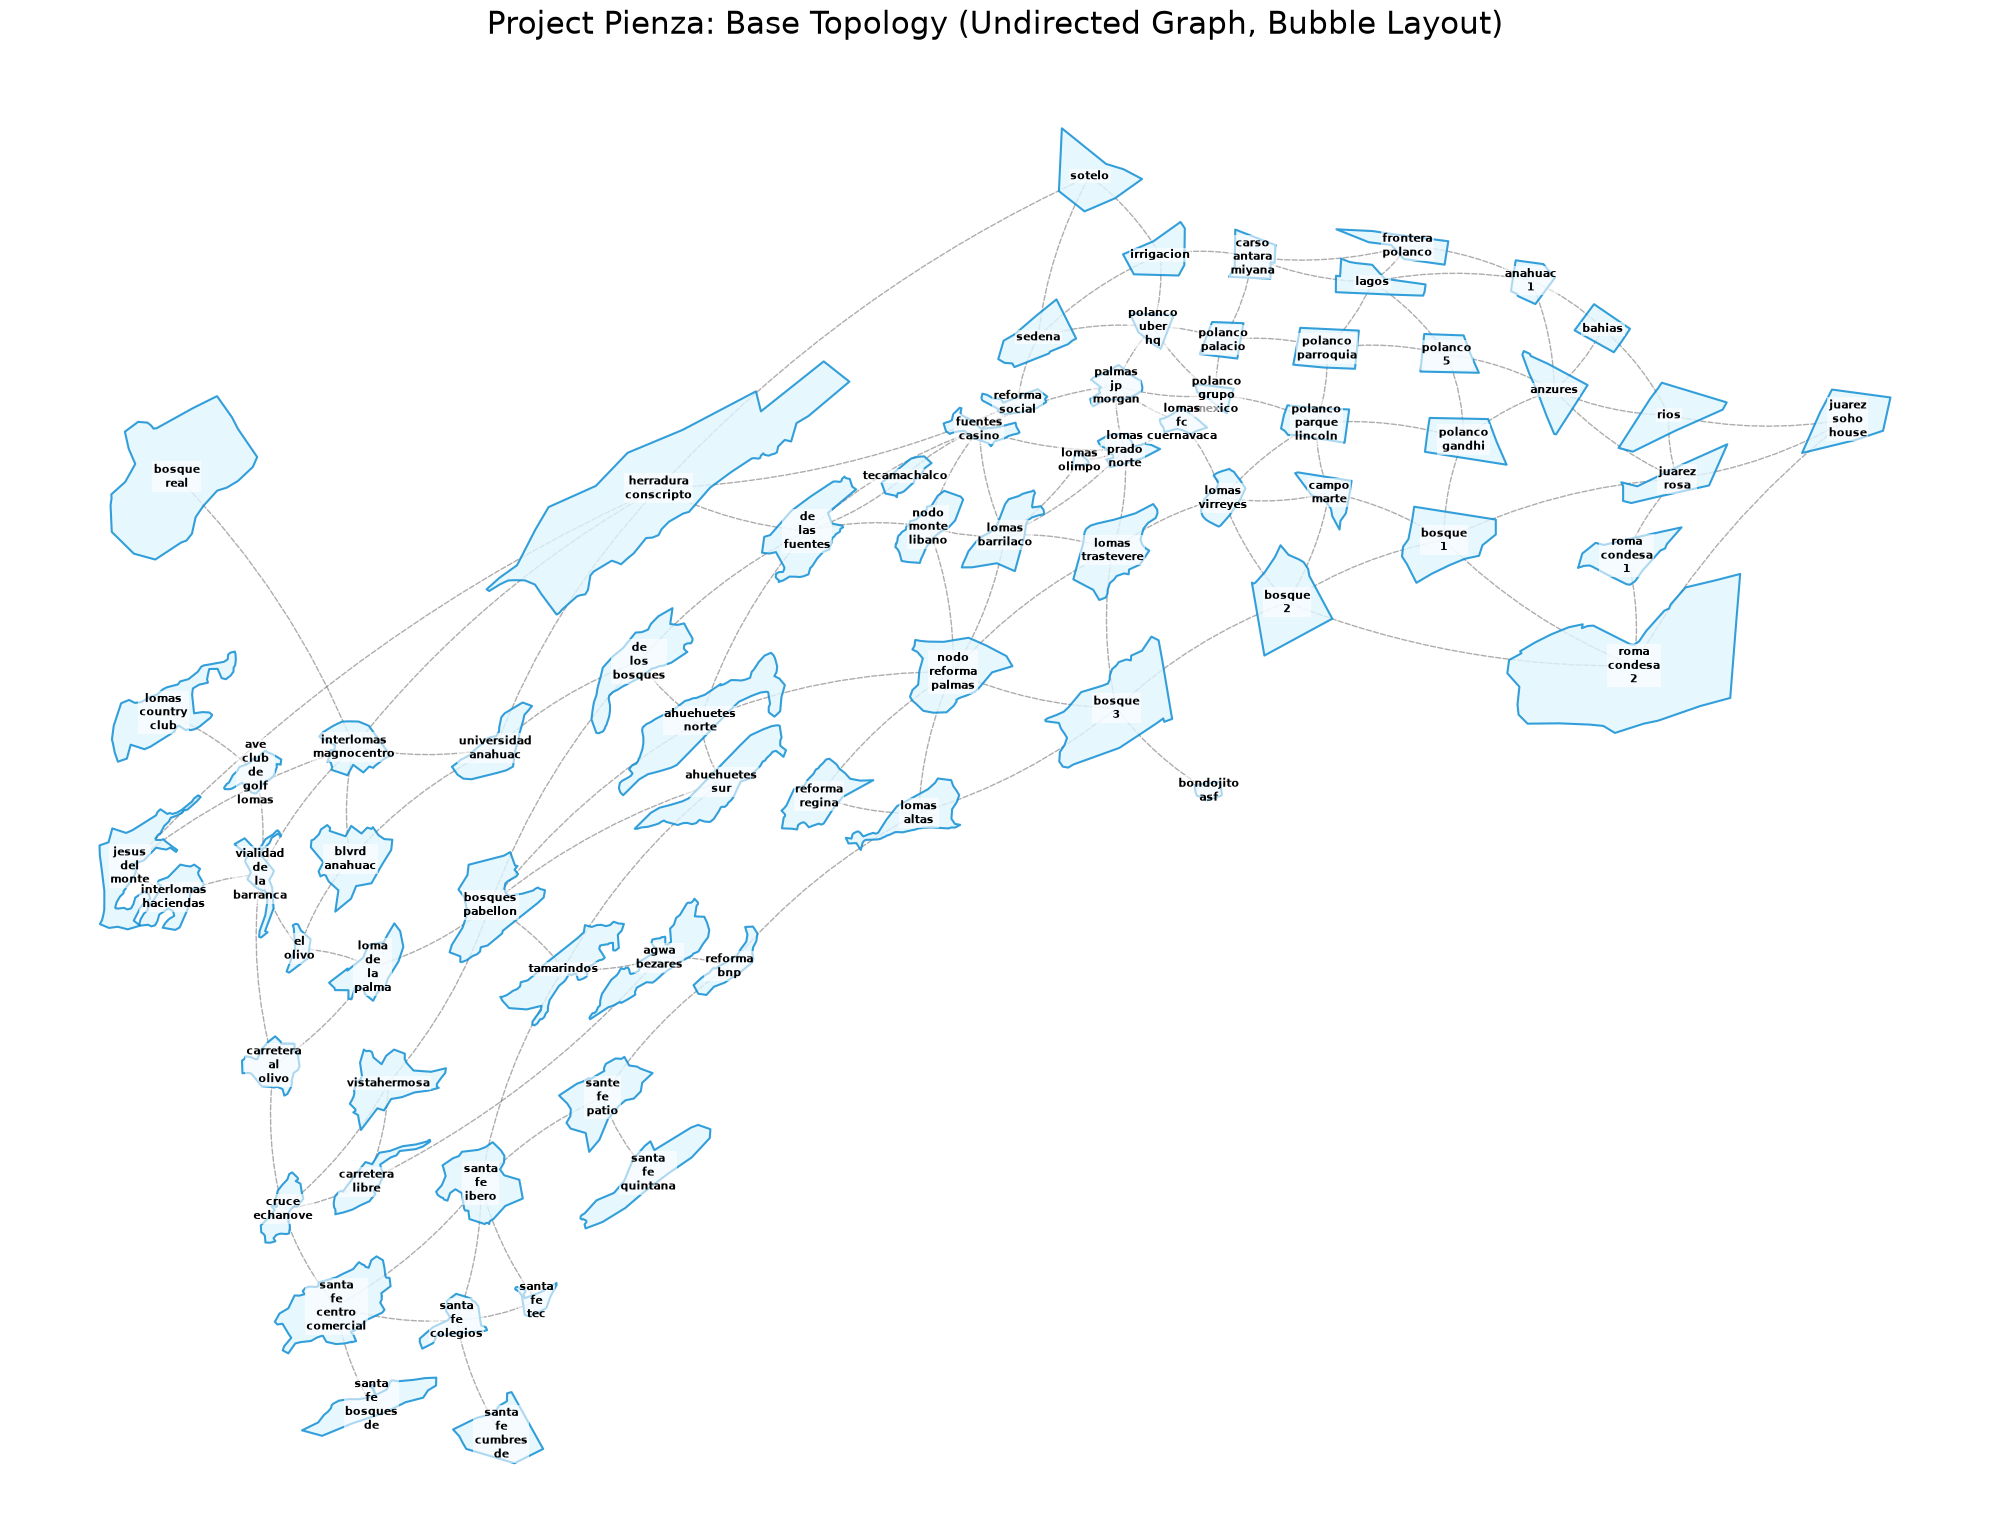

Base render complete.


In [6]:
print("Rendering the base topological graph...")

fig, ax = plt.subplots(figsize=(20, 25))
ax.set_facecolor('white')

# --- 1. Draw the bubbles (nodes) ---
gdf_f.set_geometry('schematic_geometry').plot(
    ax=ax, facecolor='#E1F5FE', edgecolor='#0288D1', linewidth=1.5, alpha=0.8, zorder=2
)

# --- 2. Pull schematic positions from the graph attributes ---
schematic_pos = nx.get_node_attributes(G_manual, 'schematic_centroid')

# --- 3. Draw curved edges ---
for u, v in G_manual.edges():
    if u in schematic_pos and v in schematic_pos:
        start = schematic_pos[u]
        end = schematic_pos[v]
        edge = FancyArrowPatch(
            start, end, connectionstyle="arc3,rad=0.1",
            color='#333333', linewidth=1.0, linestyle='--', alpha=0.4,
            arrowstyle='-', zorder=1
        )
        ax.add_patch(edge)

# --- 4. Labels ---
for node, (x, y) in schematic_pos.items():
    label = str(node).replace('_', '\n')
    ax.text(x, y, label, fontsize=8, fontweight='bold', ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1), zorder=3)

plt.title("Project Pienza: Base Topology (Undirected Graph, Bubble Layout)", fontsize=22, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

print("Base render complete.")

#### 2.3 — Small-World topology test

Compares the physical graph's clustering coefficient and average path length against random-graph benchmarks (Watts-Strogatz sigma/omega) to test whether the street network has small-world structure.

In [7]:
print("Evaluating the Small-World topology hypothesis...")

# --- 1. Extract the giant component ---
# Distance metrics require the graph to have no disconnected islands.
if not nx.is_connected(G_manual):
    giant_nodes = max(nx.connected_components(G_manual), key=len)
    G_giant = G_manual.subgraph(giant_nodes).copy()
    print(f"Disconnected graph detected. Isolated the giant component: {G_giant.number_of_nodes()} active nodes.")
else:
    G_giant = G_manual.copy()
    print("Graph is 100% connected. Using the full graph.")

# --- 2. Real metrics ---
# C = clustering coefficient (do my neighbors know each other?)
C_real = nx.average_clustering(G_giant)
# L = average shortest path length (how many hops to cross the city?)
L_real = nx.average_shortest_path_length(G_giant)

# --- 3. Random-graph benchmark (Erdos-Renyi) ---
print("Generating random-graph control simulations...")
sigma = nx.sigma(G_giant, niter=10, nrand=10)
omega = nx.omega(G_giant, niter=10, nrand=10)

# --- 4. Report ---
print("\n" + "="*70)
print("SMALL-WORLD TEST RESULTS (Watts-Strogatz)")
print("="*70)
print(f"Local clustering (C): {C_real:.4f} (mesh level within neighborhoods)")
print(f"Path length (L):      {L_real:.4f} hops (average travel friction)")

print("\nNetwork coefficients:")
print(f"Sigma (sigma): {sigma:.4f}")
print("   (sigma > 1 indicates a strong Small-World network. Higher is better.)")
print(f"\nOmega (omega): {omega:.4f}")
print("   (Values near 0 indicate a perfect Small-World balance.")
print("   Values near 1 indicate a lattice/grid network (very rigid). Values near -1: random.)")

print("-" * 70)
if sigma > 1 and (-0.5 <= omega <= 0.5):
    print("VERDICT: Pienza's infrastructure IS a Small-World network.")
    print("The network has high local redundancy (neighborhoods) but still crosses the city efficiently via strategic avenues.")
else:
    print("VERDICT: The infrastructure does not have optimal Small-World properties.")
    print("It could be too linear (like a train line) or too rigid (like a perfect grid).")

Evaluating the Small-World topology hypothesis...
Graph is 100% connected. Using the full graph.
Generating random-graph control simulations...



SMALL-WORLD TEST RESULTS (Watts-Strogatz)
Local clustering (C): 0.2677 (mesh level within neighborhoods)
Path length (L):      4.8052 hops (average travel friction)

Network coefficients:
Sigma (sigma): 3.3937
   (sigma > 1 indicates a strong Small-World network. Higher is better.)

Omega (omega): -0.3046
   (Values near 0 indicate a perfect Small-World balance.
   Values near 1 indicate a lattice/grid network (very rigid). Values near -1: random.)
----------------------------------------------------------------------
VERDICT: Pienza's infrastructure IS a Small-World network.
The network has high local redundancy (neighborhoods) but still crosses the city efficiently via strategic avenues.


#### 2.4 — Centrality analysis (degree, betweenness, closeness, eigenvector)

Computes the four standard centrality metrics on the physical graph to identify hub zones, bridge zones, geometrically central zones, and zones of high-influence neighbors.

In [49]:
print("Computing the 4 centrality metrics...")

# --- 1. Compute metrics ---
deg_cent = nx.degree_centrality(G_manual)
bet_cent = nx.betweenness_centrality(G_manual)
clo_cent = nx.closeness_centrality(G_manual)
eig_cent = nx.eigenvector_centrality(G_manual, max_iter=1000)

nx.set_node_attributes(G_manual, deg_cent, 'degree')
nx.set_node_attributes(G_manual, bet_cent, 'betweenness')
nx.set_node_attributes(G_manual, clo_cent, 'closeness')
nx.set_node_attributes(G_manual, eig_cent, 'eigenvector')

# --- 2. Consolidate into a DataFrame ---
df_centrality = pd.DataFrame({
    'zone': list(G_manual.nodes()),
    'Degree (Hubs)': [deg_cent[n] for n in G_manual.nodes()],
    'Betweenness (Bridges)': [bet_cent[n] for n in G_manual.nodes()],
    'Closeness (Centers)': [clo_cent[n] for n in G_manual.nodes()],
    'Eigenvector (Influence)': [eig_cent[n] for n in G_manual.nodes()]
})

gdf_f['score_degree'] = gdf_f['name'].map(deg_cent)
gdf_f['score_betweenness'] = gdf_f['name'].map(bet_cent)
gdf_f['score_closeness'] = gdf_f['name'].map(clo_cent)
gdf_f['score_eigenvector'] = gdf_f['name'].map(eig_cent)

# --- 3. Top 5 tables per metric ---
print("\n" + "="*60)
print("TOP 5 ZONES BY CENTRALITY METRIC")
print("="*60)

metrics = [
    ('Degree (Hubs)', 'Greens'),
    ('Betweenness (Bridges)', 'Oranges'),
    ('Closeness (Centers)', 'Blues'),
    ('Eigenvector (Influence)', 'Purples')
]

for col, cmap in metrics:
    print(f"\n{col}:")
    display(df_centrality[['zone', col]].sort_values(by=col, ascending=False).head(5).style.background_gradient(cmap=cmap))

print("Centrality analysis complete.")

# --- 4. Export: zone centrality metrics (physical graph) ---
OUTPUT_CENTRALITY = os.path.join(DUMP_DIR, "0608_260718_zone_centrality.csv")

df_zone_centrality = gdf_f[[
    'name', 'score_degree', 'score_betweenness', 'score_closeness', 'score_eigenvector'
]].rename(columns={'name': 'zone_name'})

# Tooltips are bounded to 2 decimal places project-wide (see CLAUDE.md); Kepler.gl
# has no per-field format string like Altair's format=".2f", so round at export time.
score_cols = ['score_degree', 'score_betweenness', 'score_closeness', 'score_eigenvector']
df_zone_centrality[score_cols] = df_zone_centrality[score_cols].round(2)

df_zone_centrality.to_csv(OUTPUT_CENTRALITY, index=False)
print(f"Zone centrality metrics exported to: {OUTPUT_CENTRALITY}")
display(df_zone_centrality.head())

Computing the 4 centrality metrics...

TOP 5 ZONES BY CENTRALITY METRIC

Degree (Hubs):


,zone,Degree (Hubs)
21,fuentes_casino,0.098592
5,nodo_reforma_palmas,0.098592
0,anzures,0.084507
66,bosques_pabellon,0.084507
43,de_las_fuentes,0.084507



Betweenness (Bridges):


,zone,Betweenness (Bridges)
5,nodo_reforma_palmas,0.205476
12,bosque_3,0.195831
36,herradura_conscripto,0.195620
57,ahuehuetes_norte,0.182364
11,bosque_2,0.170067



Closeness (Centers):


,zone,Closeness (Centers)
57,ahuehuetes_norte,0.279528
5,nodo_reforma_palmas,0.278431
43,de_las_fuentes,0.269962
12,bosque_3,0.261993
44,de_los_bosques,0.261029



Eigenvector (Influence):


,zone,Eigenvector (Influence)
23,lomas_barrilaco,0.342497
21,fuentes_casino,0.336771
5,nodo_reforma_palmas,0.309192
25,lomas_prado_norte,0.303814
4,lomas_trastevere,0.272821


Centrality analysis complete.
Zone centrality metrics exported to: /workspaces/pienza/data/dumped_files/0608_260718_zone_centrality.csv


,zone_name,score_degree,score_betweenness,score_closeness,score_eigenvector
0,polanco_parque_lincoln,0.07,0.08,0.22,0.09
1,polanco_gandhi,0.06,0.05,0.20,0.05
2,carso_antara_miyana,0.06,0.08,0.20,0.04
3,sotelo,0.04,0.10,0.23,0.05
4,irrigacion,0.06,0.09,0.22,0.06


<div style="border-left: 4px solid #21918c; padding: 4px 20px; background: rgba(33,145,140,0.05); border-radius: 0 6px 6px 0;">

#### _Centrality results: the physical network's hierarchy_

_Crossing the four centrality metrics reveals the network's true hierarchy, natural flows, and critical vulnerability points._

##### _The clear super-node_

_One conclusion dominates the analysis: **`nodo_reforma_palmas` is the physical network's clear leader.** It is the only zone that appears in the Top 5 of *every* category — highest degree, connects to other high-eigenvector zones, sits at the system's geometric center (closeness), and is an obligatory crossing point (betweenness)._

---

##### _1. Degree centrality (local hubs)_
_Zones with the most direct street connections — short-range routing distributors._

| Rank | Zone | Score | Read |
| :--- | :--- | :--- | :--- |
| 1 | **nodo_reforma_palmas** | 0.0985 | Maximum physical permeability. |
| 2 | **fuentes_casino** | 0.0985 | Technical tie for #1; very high local routing optionality. |
| 3 | **de_las_fuentes** | 0.0845 | Strong secondary distributor in the north-west. |
| 4 | **anzures** | 0.0845 | Main distribution hub for the east/central side. |
| 5 | **lomas_prado_norte** | 0.0845 | Key hub within the Lomas cluster. |

##### _2. Betweenness centrality (strategic bridges)_
_The "gatekeepers" — zones that appear most often on shortest paths between any two points. **This is where operational vulnerability lives.**_

| Rank | Zone | Score | Read |
| :--- | :--- | :--- | :--- |
| 1 | **nodo_reforma_palmas** | 0.2054 | Controls 20.5% of all optimal network paths. |
| 2 | **bosque_3** | 0.1958 | A vital bridge connecting the deep west. |
| 3 | **herradura_conscripto** | 0.1956 | Vulnerability alert — a critical bottleneck; a blockage here isolates entire sections. |
| 4 | **ahuehuetes_norte** | 0.1823 | Main connector in the north-west corridor. |
| 5 | **bosque_2** | 0.1700 | Second critical link in the "bosques" chain. |

##### _3. Closeness centrality (geographic centers)_
_Zones requiring the fewest average topological hops to reach any other polygon — the system's center of gravity._

| Rank | Zone | Score | Read |
| :--- | :--- | :--- | :--- |
| 1 | **ahuehuetes_norte** | 0.2795 | The most topologically central zone on the map. |
| 2 | **nodo_reforma_palmas** | 0.2784 | Practically at the exact topological center. |
| 3 | **de_las_fuentes** | 0.2699 | High efficiency for dispatching trips in any direction. |
| 4 | **bosque_3** | 0.2619 | Very central, which explains why it's also a key bridge (betweenness). |
| 5 | **fuentes_casino** | 0.2610 | Central and highly connected to exit routes. |

##### _4. Eigenvector centrality (influence by proximity)_
_Not just having many neighbors, but having "well-connected" neighbors — identifies clusters of topological elite._

| Rank | Zone | Score | Read |
| :--- | :--- | :--- | :--- |
| 1 | **lomas_barrilaco** | 0.3424 | The most influential node — not #1 in direct connections, but surrounded by the highest-power nodes. |
| 2 | **fuentes_casino** | 0.3367 | Extremely well positioned within the "elite mesh." |
| 3 | **nodo_reforma_palmas** | 0.3091 | Retains elite influence status. |
| 4 | **lomas_prado_norte** | 0.3038 | Reinforces that the Lomas-Palmas cluster dominates the topology. |
| 5 | **lomas_trastevere** | 0.2728 | Benefits from its immediate neighbors' very high interconnectivity. |

---

##### _Strategic insights_

1. _**The power cluster (mesh effect):** the eigenvector analysis shows that `barrilaco`, `prado_norte`, `trastevere`, and `fuentes_casino` form an "elite mesh." They are so interconnected with each other and with the super-node (`reforma_palmas`) that they dominate the city's topological influence, creating a zone of high local redundancy (low routing friction)._
2. _**Periphery risk (funnel effect):** zones like `herradura_conscripto` and `bosque_3` have a striking topology — they don't have elite influence (absent from eigenvector) nor are they large distributors (absent from degree), but they **have very high betweenness**. This makes them critical "pipes": if friction increases at these nodes, platform traffic has no viable secondary routes to connect the center with the periphery._

</div>

#### 2.5 — Vulnerability audit (cut-vertices and critical bridges)

Identifies single points of failure: zones whose removal splits the network into islands (cut-vertices), and edges whose removal does the same (bridges).

In [9]:
print("Starting topological vulnerability audit...")

# --- 1. Single points of failure ---
# Cut-vertices (nodes): if this zone is blocked, the network splits into islands.
cut_vertices = list(nx.articulation_points(G_manual))
# Bridges (edges): if this street/connection closes, the network splits into islands.
bridges = list(nx.bridges(G_manual))

# --- 2. Report ---
print("\n" + "="*70)
print("RESILIENCE REPORT: FRAGMENTATION RISK")
print("="*70)

print(f"Critical zones (cut-vertices): {len(cut_vertices)}")
for cv in cut_vertices:
    print(f"   - {cv}")

print(f"\nCritical connections (bridges): {len(bridges)}")
for u, v in bridges:
    print(f"   - {u} <---> {v}")

print("Vulnerability audit complete.")

Starting topological vulnerability audit...

RESILIENCE REPORT: FRAGMENTATION RISK
Critical zones (cut-vertices): 7
   - ave_club_de_golf_lomas
   - vialidad_de_la_barranca
   - santa_fe_colegios
   - sante_fe_patio
   - santa_fe_centro_comercial
   - interlomas_magnocentro
   - bosque_3

Critical connections (bridges): 7
   - bosque_3 <---> bondojito_asf
   - sante_fe_patio <---> santa_fe_quintana
   - interlomas_magnocentro <---> bosque_real
   - vialidad_de_la_barranca <---> ave_club_de_golf_lomas
   - ave_club_de_golf_lomas <---> lomas_country_club
   - santa_fe_centro_comercial <---> santa_fe_bosques_de
   - santa_fe_colegios <---> santa_fe_cumbres_de
Vulnerability audit complete.


#### 2.6 — Failure simulator

Removes a chosen cut-vertex and visualizes the resulting fragmentation into disconnected "islands."

Starting topological collapse simulator...

DAMAGE REPORT: COLLAPSE AT 'INTERLOMAS_MAGNOCENTRO'
The network fragmented into 2 independent islands:
   -> MAIN ISLAND: 70 zones.
   -> Micro-island 1: 1 zones.
      Stranded: ['bosque_real']


findfont: Failed to find font weight black, now using 700.


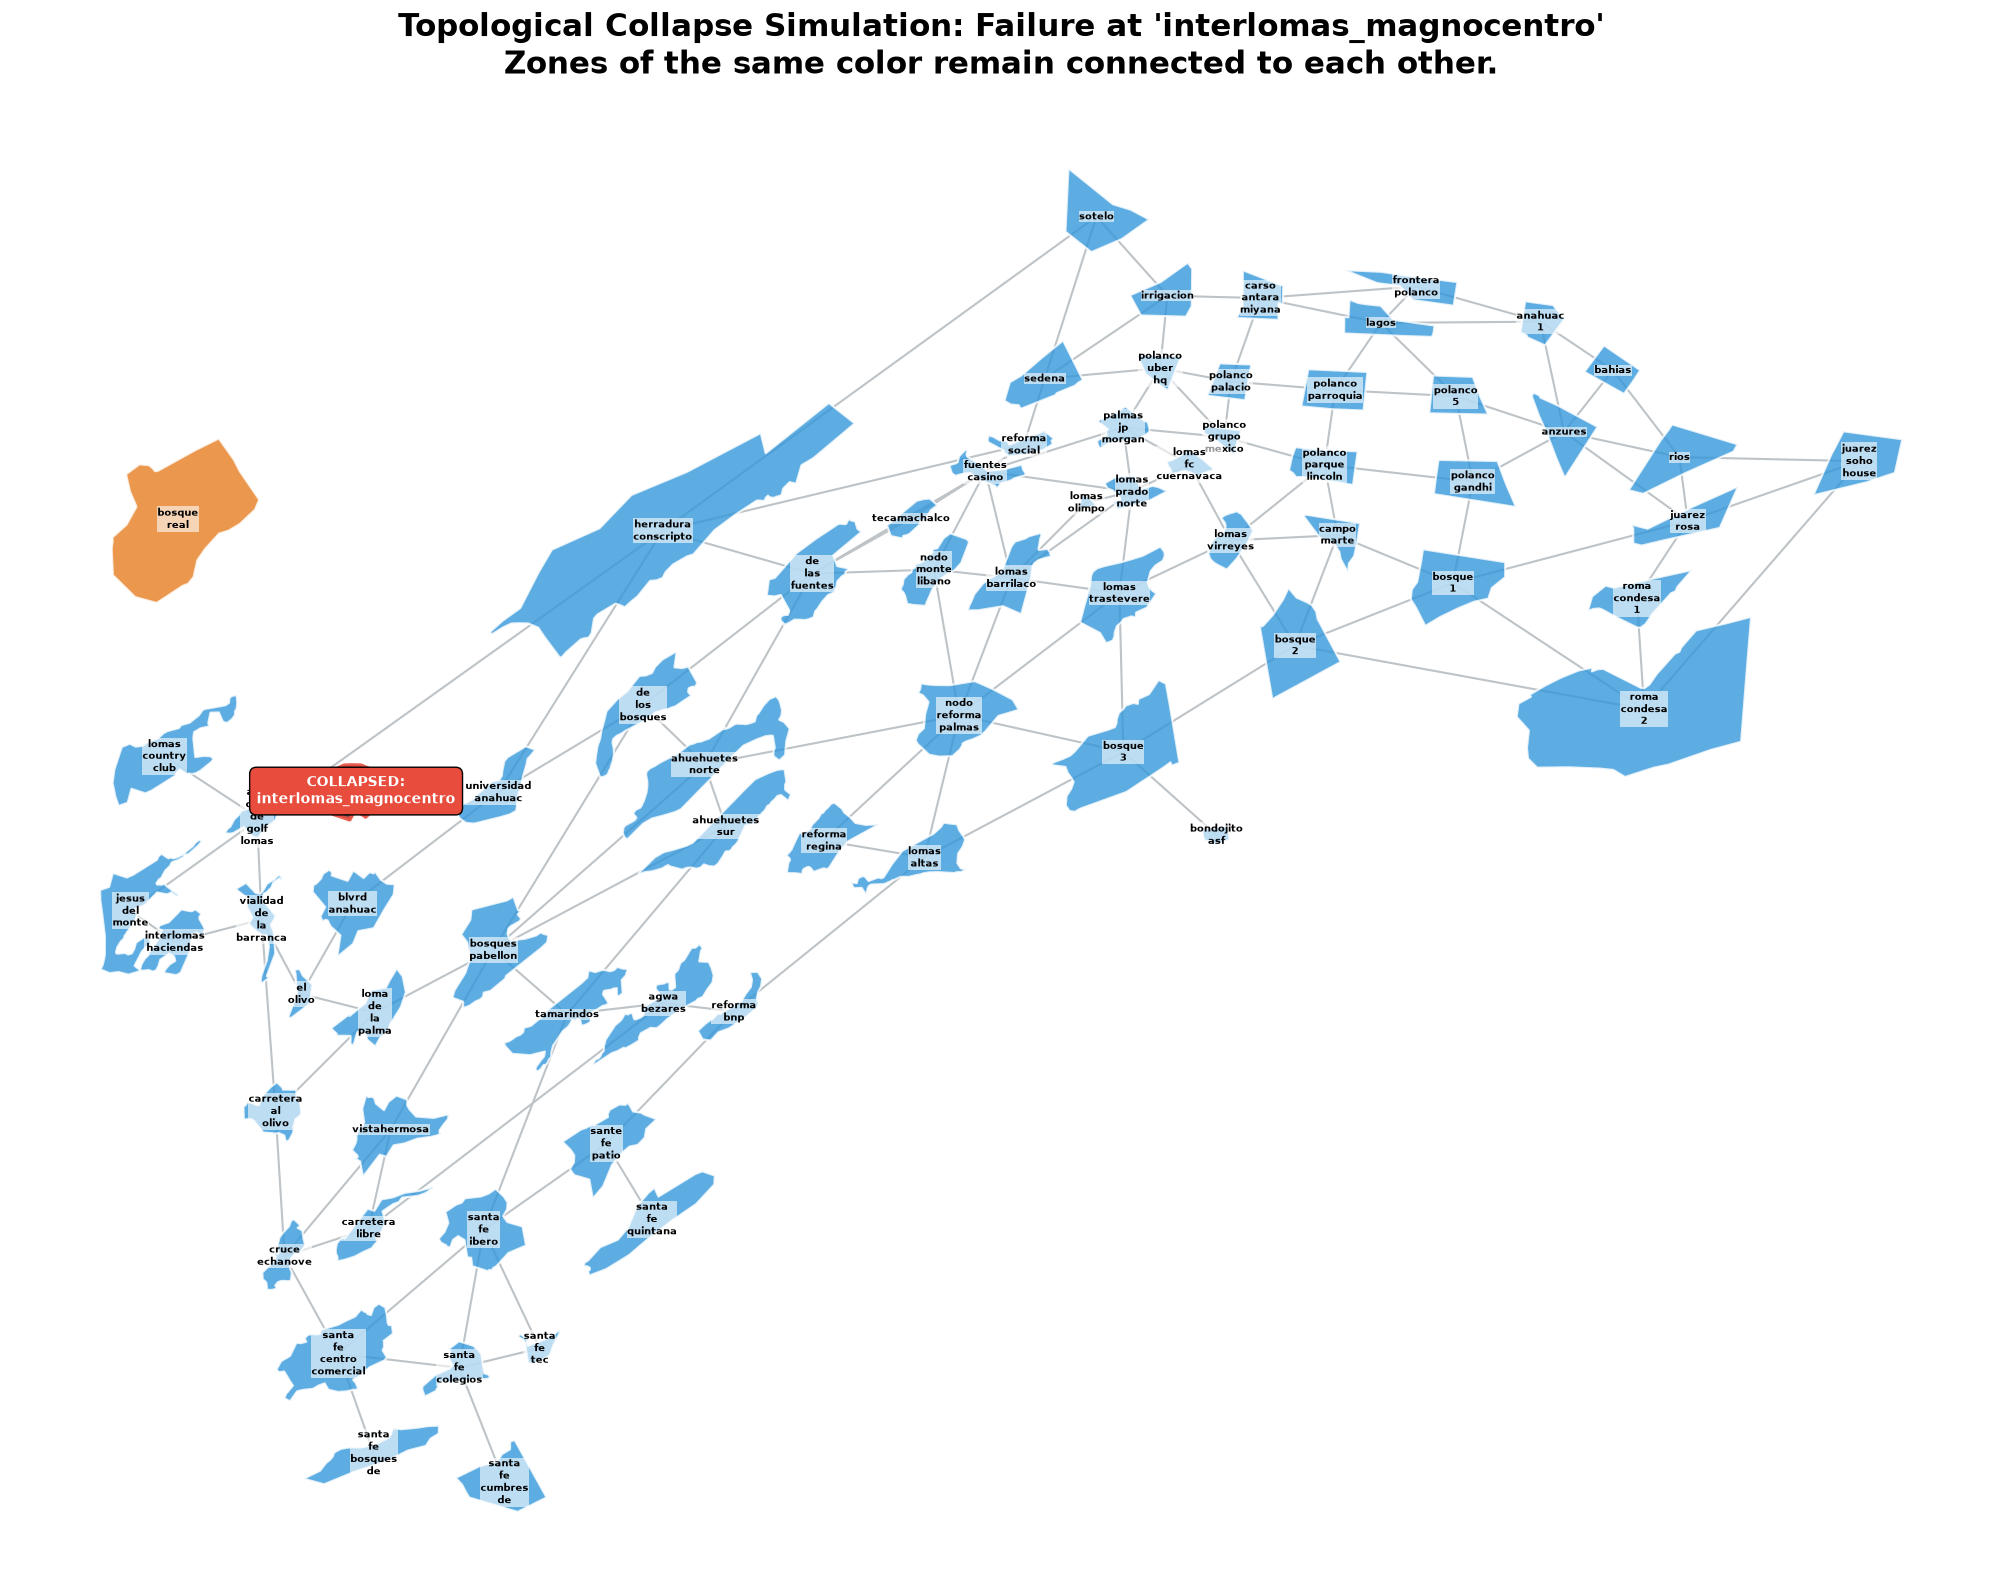

In [10]:
print("Starting topological collapse simulator...")

# --- 1. Configure the target here ---
# Change this to any node from the cut-vertices list above to see its impact.
collapsed_node = 'interlomas_magnocentro'

if collapsed_node not in G_manual.nodes():
    print(f"Node '{collapsed_node}' does not exist in the network.")
else:
    # --- 2. Simulate the failure ---
    G_sim = G_manual.copy()
    G_sim.remove_node(collapsed_node)

    # Compute the resulting islands (connected components)
    islands = list(nx.connected_components(G_sim))
    islands.sort(key=len, reverse=True)

    print("\n" + "="*70)
    print(f"DAMAGE REPORT: COLLAPSE AT '{collapsed_node.upper()}'")
    print("="*70)
    print(f"The network fragmented into {len(islands)} independent islands:")

    for i, island in enumerate(islands):
        kind = "MAIN ISLAND" if i == 0 else f"Micro-island {i}"
        print(f"   -> {kind}: {len(island)} zones.")
        if len(island) <= 5:
            print(f"      Stranded: {list(island)}")

    # --- 3. Visualize the collapse ---
    fig, ax = plt.subplots(figsize=(22, 16))
    ax.set_facecolor('#F8F9F9')

    island_colors = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6', '#F1C40F']
    pos = nx.get_node_attributes(G_manual, 'schematic_centroid')

    # A. Draw surviving streets
    for u, v in G_sim.edges():
        if u in pos and v in pos:
            ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                    color='#BDC3C7', linewidth=1.5, linestyle='-', zorder=1)

    # B. Draw colored islands
    gdf_plot = gdf_f.set_geometry('schematic_geometry')

    for i, island in enumerate(islands):
        color = island_colors[i % len(island_colors)]
        gdf_island = gdf_plot[gdf_plot['name'].isin(island)]
        gdf_island.plot(ax=ax, facecolor=color, edgecolor='white', linewidth=1.5, alpha=0.8, zorder=2)

        for zone in island:
            c = pos[zone]
            ax.text(c[0], c[1], zone.replace('_', '\n'), fontsize=7, fontweight='bold', color='black',
                    ha='center', va='center', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=0.3), zorder=3)

    # C. Draw the collapsed node
    gdf_collapsed = gdf_plot[gdf_plot['name'] == collapsed_node]
    gdf_collapsed.plot(ax=ax, facecolor='#2C3E50', edgecolor='#E74C3C', linewidth=3, hatch='///', alpha=0.9, zorder=4)

    c_x, c_y = pos[collapsed_node]
    ax.text(c_x, c_y, f"COLLAPSED:\n{collapsed_node}", color='white', fontsize=10, fontweight='black',
            ha='center', va='center', bbox=dict(facecolor='#E74C3C', alpha=1.0, edgecolor='black', boxstyle='round,pad=0.5'), zorder=5)

    plt.title(f"Topological Collapse Simulation: Failure at '{collapsed_node}'\nZones of the same color remain connected to each other.", fontsize=22, pad=20, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

#### 2.7 — Macro morphology (density, diameter, radius, eccentricity)

Defines the physical bounds of the network: how sparse it is, its absolute center, and its extreme periphery.

Computing macro morphology (bounds and frontiers)...

MACRO MORPHOLOGY REPORT (physical bounds)
Network density: 0.0532 (only 5.3% of possible streets exist)
Diameter (max distance): 11 topological hops
Radius (min distance):   7 topological hops

Absolute core (centers):
   - nodo_reforma_palmas
   - fuentes_casino
   - nodo_monte_libano
   - lomas_barrilaco
   - herradura_conscripto
   - de_las_fuentes
   - ahuehuetes_norte
   - tecamachalco

Extreme periphery (border zones):
   - rios
   - juarez_rosa
   - juarez_soho_house
   - bahias
   - anahuac_1
   - lagos
   - roma_condesa_1
   - lomas_country_club
   - santa_fe_cumbres_de
   - santa_fe_bosques_de
   - frontera_polanco

Rendering eccentricity map (center vs. periphery)...


findfont: Failed to find font weight black, now using 700.


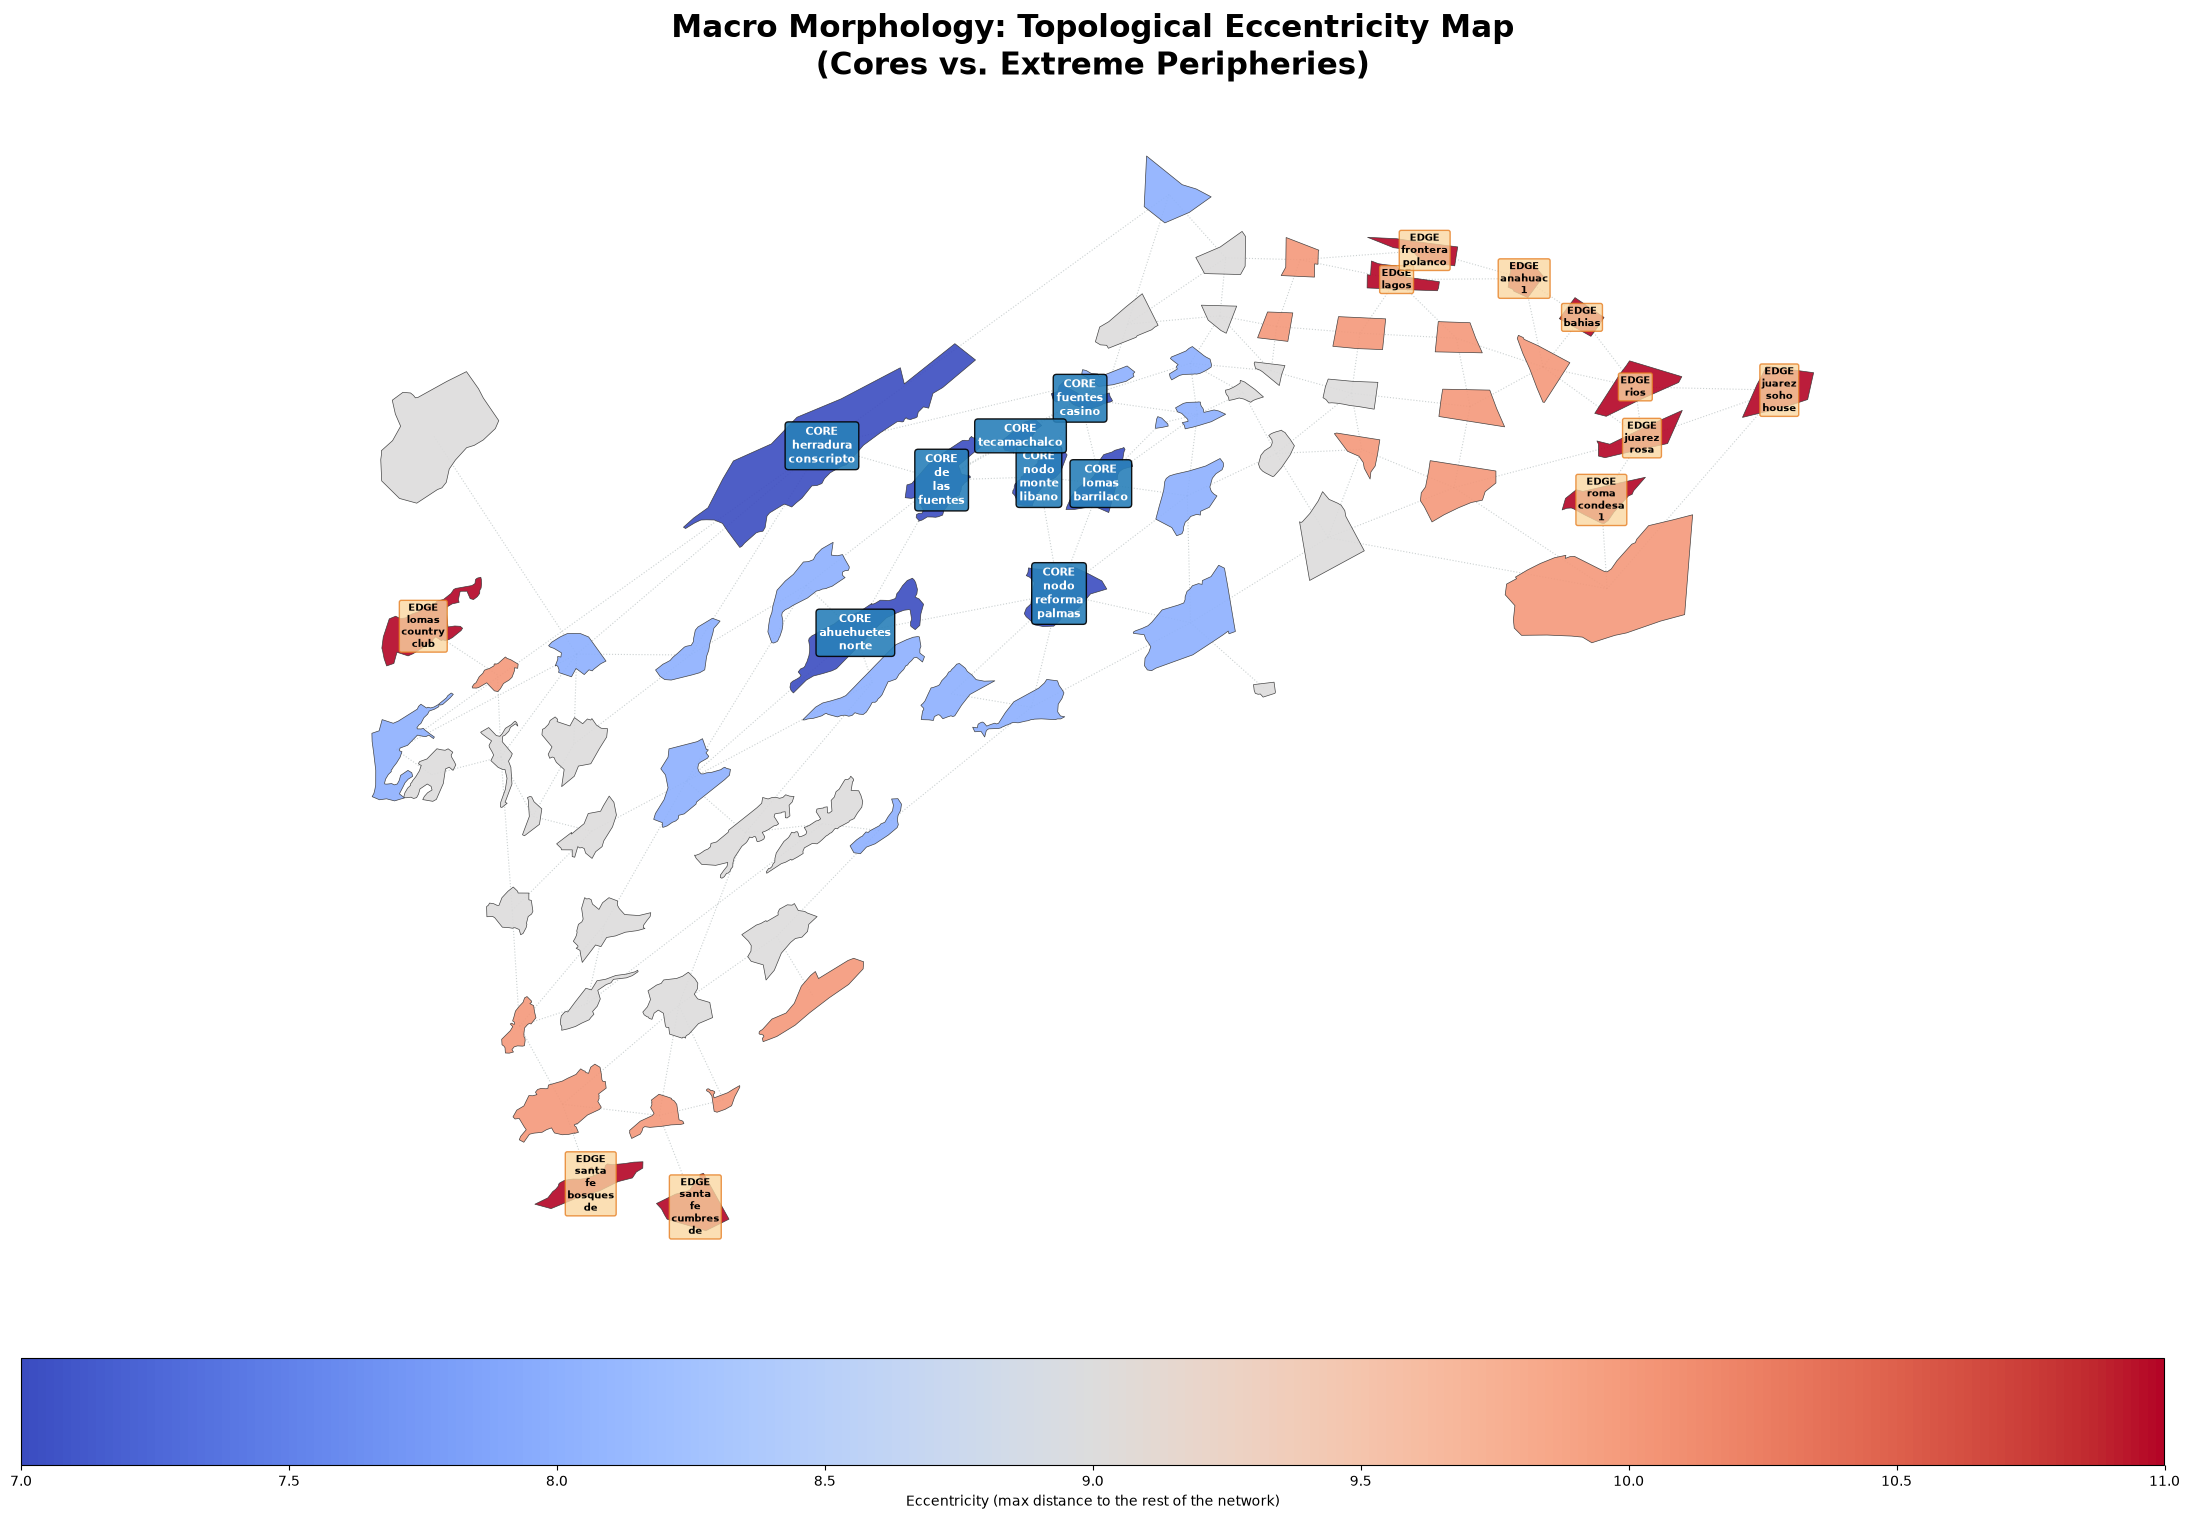

Macro morphology analysis complete.


In [11]:
print("Computing macro morphology (bounds and frontiers)...")

# --- 1. Extract the giant component ---
# Max-distance metrics fail if there are unreachable nodes (islands).
if not nx.is_connected(G_manual):
    giant_nodes = max(nx.connected_components(G_manual), key=len)
    G_giant = G_manual.subgraph(giant_nodes).copy()
else:
    G_giant = G_manual.copy()

# --- 2. Global metrics ---
# Density: % of streets that exist vs. all that could exist if everyone connected to everyone.
density = nx.density(G_manual)
# Eccentricity: for each node, what is the max distance to any other node?
eccentricity = nx.eccentricity(G_giant)
# Diameter: the network's max eccentricity (the longest possible shortest path).
diameter = nx.diameter(G_giant)
# Radius: the network's min eccentricity (the shortest path from the best center).
radius = nx.radius(G_giant)

# --- 3. Node classification ---
centers = nx.center(G_giant)      # eccentricity == radius (most central)
periphery = nx.periphery(G_giant)  # eccentricity == diameter (most isolated/farthest)

# --- 4. Report ---
print("\n" + "="*70)
print("MACRO MORPHOLOGY REPORT (physical bounds)")
print("="*70)
print(f"Network density: {density:.4f} (only {density*100:.1f}% of possible streets exist)")
print(f"Diameter (max distance): {diameter} topological hops")
print(f"Radius (min distance):   {radius} topological hops")

print("\nAbsolute core (centers):")
for c in centers:
    print(f"   - {c}")

print("\nExtreme periphery (border zones):")
for p in periphery:
    print(f"   - {p}")

# --- 5. Spatial visualization (eccentricity heatmap) ---
print("\nRendering eccentricity map (center vs. periphery)...")

gdf_f['score_eccentricity'] = gdf_f['name'].map(eccentricity)

fig, ax = plt.subplots(figsize=(22, 16))
ax.set_facecolor('white')

gdf_plot = gdf_f.set_geometry('schematic_geometry')
gdf_plot.plot(
    column='score_eccentricity', ax=ax, cmap='coolwarm', legend=True,
    legend_kwds={'label': "Eccentricity (max distance to the rest of the network)", 'orientation': "horizontal", 'pad': 0.05},
    alpha=0.9, edgecolor='#333333', linewidth=0.5, zorder=2
)

pos = nx.get_node_attributes(G_manual, 'schematic_centroid')
for u, v in G_manual.edges():
    if u in pos and v in pos:
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color='#7F8C8D', linewidth=0.8, linestyle=':', alpha=0.4, zorder=1)

for zone, (x, y) in pos.items():
    zone_label = zone.replace('_', '\n')
    if zone in centers:
        ax.text(x, y, f"CORE\n{zone_label}", color='white', fontsize=8, fontweight='black',
                ha='center', va='center',
                bbox=dict(facecolor='#2980B9', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.3'), zorder=4)
    elif zone in periphery:
        ax.text(x, y, f"EDGE\n{zone_label}", color='black', fontsize=7, fontweight='bold',
                ha='center', va='center',
                bbox=dict(facecolor='#FAD7A1', alpha=0.8, edgecolor='#E67E22', boxstyle='round,pad=0.2'), zorder=3)

plt.title("Macro Morphology: Topological Eccentricity Map\n(Cores vs. Extreme Peripheries)", fontsize=22, pad=20, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("Macro morphology analysis complete.")

<div style="border-left: 4px solid #21918c; padding: 4px 20px; background: rgba(33,145,140,0.05); border-radius: 0 6px 6px 0;">

#### _Macro morphology: the operating footprint_

This defines the graph's physical boundaries. Viewed at the macro level, individual nodes give way to the full "playing field" — where the topological core sits, and where the extreme peripheries are.

##### _Network dimensions_
- _**Density (5.3%):** of all the connections that could exist if every zone connected directly to every other, only 5.3% do. This is normal and healthy for urban networks (they are sparse graphs) — it reflects real infrastructure with geographic barriers, not a theoretical grid._
- _**Diameter (11 hops):** the highest-friction trip possible. Going from the most extreme point A to the most extreme point B requires crossing **11 zone boundaries**. This is the graph's's maximum routing limit._
- _**Radius (7 hops):** the distance from the "absolute center." Standing at the city's core, it takes at most **7 hops** to reach the farthest periphery._

##### _The absolute core_
_The central nodes (`nodo_reforma_palmas`, `tecamachalco`, `herradura_conscripto`, etc.) are not necessarily the geographic center (X/Y coordinates), but the **topological** center. They form a "hinge" between two very separated worlds: the east (Polanco, Roma, Juarez) and the deep west (Santa Fe, Interlomas)._

##### _The extreme periphery_
_The peripheral zones (`juarez_rosa`, `lomas_country_club`, `santa_fe_bosques_de`, etc.) are the graph's endpoints._

</div>

#### 2.8 — Community detection (organic clusters)

Runs greedy modularity maximization to identify mathematically emergent macro-zones based on street density, independent of the manually-assigned macro-zone labels.

Running modularity algorithm to detect organic community structure...

REPORT: 6 ORGANIC MACRO-ZONES DETECTED

Community 0 (18 zones):
   anahuac_1, anzures, bahias, bosque_1, bosque_2, campo_marte, frontera_polanco, juarez_rosa, juarez_soho_house, lagos, lomas_virreyes, polanco_5, polanco_gandhi, polanco_parque_lincoln, polanco_parroquia, rios, roma_condesa_1, roma_condesa_2

Community 1 (13 zones):
   bondojito_asf, bosque_3, fuentes_casino, lomas_altas, lomas_barrilaco, lomas_fc_cuernavaca, lomas_olimpo, lomas_prado_norte, lomas_trastevere, nodo_monte_libano, nodo_reforma_palmas, palmas_jp_morgan, reforma_regina

Community 2 (13 zones):
   agwa_bezares, carretera_libre, cruce_echanove, reforma_bnp, santa_fe_bosques_de, santa_fe_centro_comercial, santa_fe_colegios, santa_fe_cumbres_de, santa_fe_ibero, santa_fe_quintana, santa_fe_tec, sante_fe_patio, vistahermosa

Community 3 (12 zones):
   ave_club_de_golf_lomas, blvrd_anahuac, bosque_real, carretera_al_olivo, el_olivo, interlomas_ha

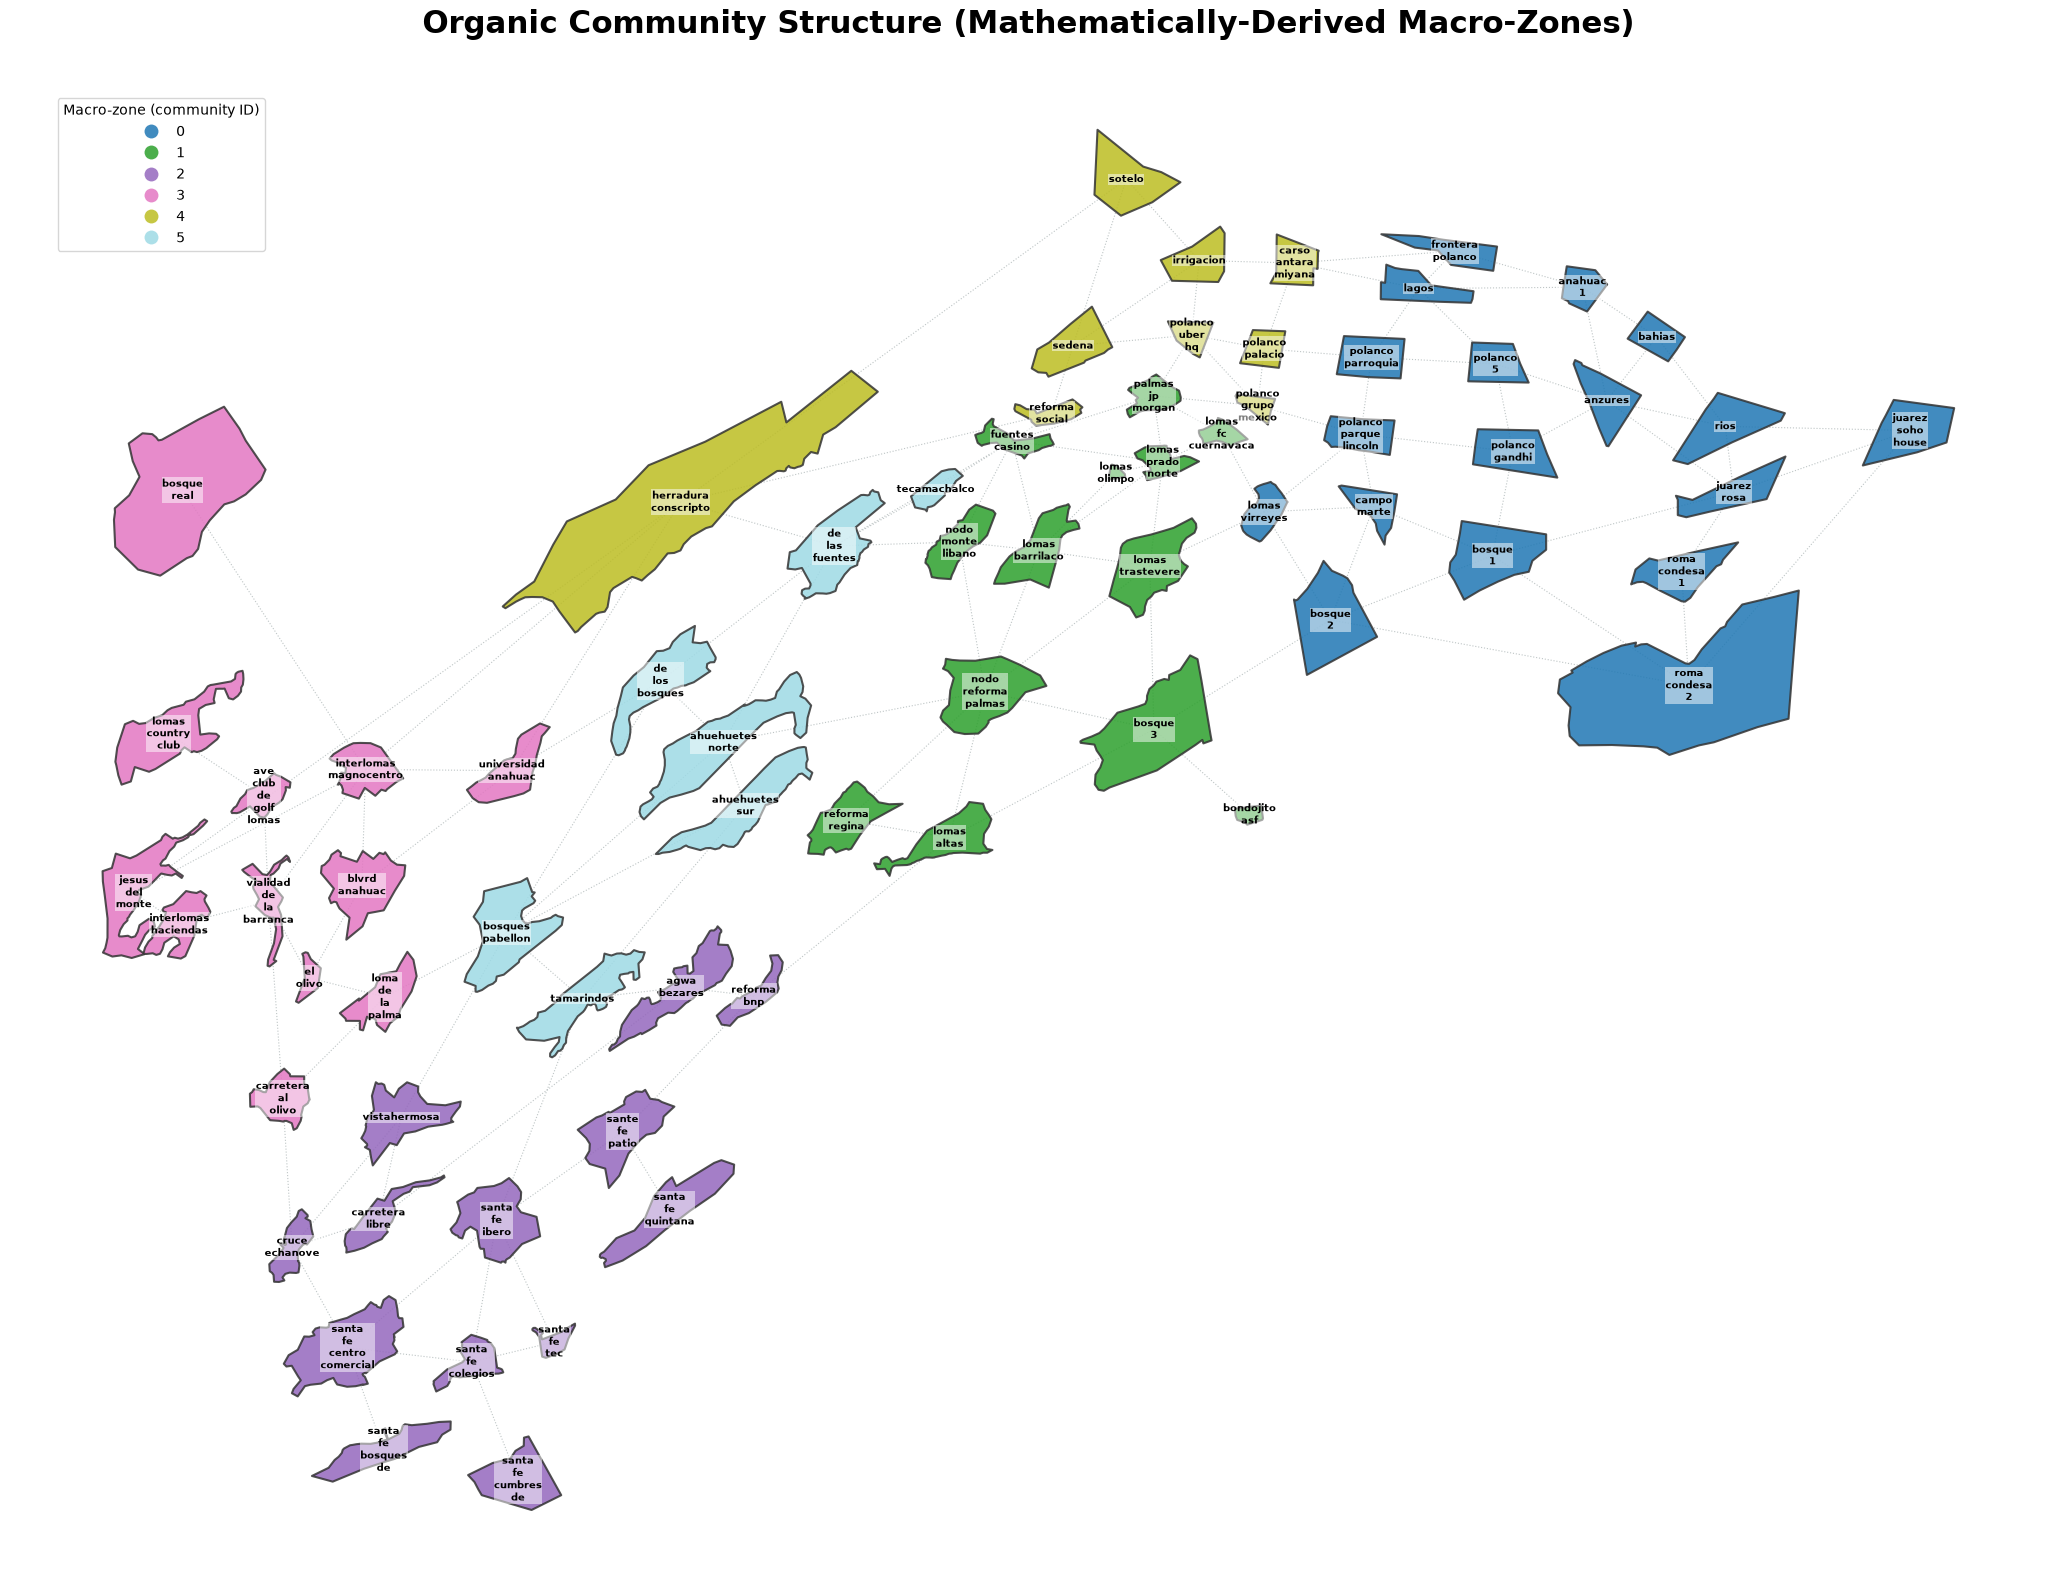

Community analysis complete. Physical (undirected) graph phase closed.


In [12]:
from networkx.algorithms.community import greedy_modularity_communities

print("Running modularity algorithm to detect organic community structure...")

# --- 1. Community detection ---
communities = list(greedy_modularity_communities(G_manual))

# --- 2. Map to the graph and GeoDataFrame ---
community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

nx.set_node_attributes(G_manual, community_map, 'community_id')
gdf_f['community_id'] = gdf_f['name'].map(community_map)

# --- 3. Report ---
print("\n" + "="*70)
print(f"REPORT: {len(communities)} ORGANIC MACRO-ZONES DETECTED")
print("="*70)

for i, comm in enumerate(communities):
    print(f"\nCommunity {i} ({len(comm)} zones):")
    print("   " + ", ".join(sorted(list(comm))))

# --- 4. Visualization ---
print("\nRendering community map...")

fig, ax = plt.subplots(figsize=(22, 16))
ax.set_facecolor('white')

gdf_plot = gdf_f.set_geometry('schematic_geometry')
gdf_plot.plot(
    column='community_id', ax=ax, cmap='tab20', edgecolor='#333333', linewidth=1.5,
    alpha=0.85, zorder=2, categorical=True, legend=True,
    legend_kwds={'title': "Macro-zone (community ID)", 'loc': 'upper left', 'bbox_to_anchor': (0.02, 0.98), 'fontsize': 10}
)

pos = nx.get_node_attributes(G_manual, 'schematic_centroid')
for u, v in G_manual.edges():
    if u in pos and v in pos:
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color='#7F8C8D', linewidth=0.8, linestyle=':', alpha=0.5, zorder=1)

for zone, (x, y) in pos.items():
    ax.text(x, y, zone.replace('_', '\n'), color='black', fontsize=7, fontweight='bold',
            ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.3), zorder=3)

plt.title("Organic Community Structure (Mathematically-Derived Macro-Zones)", fontsize=22, pad=20, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("Community analysis complete. Physical (undirected) graph phase closed.")

## Phase 3 — Synthetic manifold ingestion and closed-system filter

Loads the cGAN-synthesized manifold (from `0606_cGAN_downscaling`), audits how many trips fall outside the 72 official Pienza zones, and strictly filters the dataset down to zone-to-zone trips only, so the mobility tensor in Phase 4 stays a closed 72x72 system.

#### 3.1 — Load the synthetic manifold

Locates and loads the downscaled synthetic manifold parquet, computes EPH (earnings per hour), and measures what share of trips touch an out-of-system zone (`unassigned_area`).

In [13]:
import glob

# --- 1. Locate the file (date-prefix-agnostic search) ---
search_pattern = os.path.join(DUMP_DIR, "*_synthetic_manifold_v8_downscaled.parquet")
files = glob.glob(search_pattern)

if not files:
    print(f"ERROR: no manifold found in {DUMP_DIR}")
    PATH_GAN = os.path.join(DUMP_DIR, '06XX_260503_synthetic_manifold_v8_downscaled.parquet')
else:
    PATH_GAN = files[0]  # most recent match

print(f"Loading synthetic manifold from: {PATH_GAN}")

if not os.path.exists(PATH_GAN):
    print("CRITICAL ERROR: file still not found.")
else:
    df_synth = pd.read_parquet(PATH_GAN)

    # 2. EPH (earnings per hour) computation
    if 'eph' not in df_synth.columns:
        df_synth['eph'] = df_synth['upfront_fare'] / ((df_synth['time_to_pickup_sec'] + df_synth['est_trip_time_sec']) / 3600)

    # 3. Out-of-system audit (unassigned_area node)
    origin_col = 'pickup_name_down'
    dest_col = 'dropoff_name_down'

    mask_excluded = (df_synth[origin_col] == 'unassigned_area') | (df_synth[dest_col] == 'unassigned_area')
    excluded_trips = df_synth[mask_excluded]
    internal_trips = len(df_synth) - len(excluded_trips)
    excluded_pct = (len(excluded_trips) / len(df_synth)) * 100

    print(f"Manifold loaded: {len(df_synth):,} total trips.")
    print(f"Average global EPH: ${df_synth['eph'].mean():.2f} MXN/hr")
    print("-" * 65)
    print("STATE-SPACE AUDIT (Markov prep):")
    print(f"   Trips touching an out-of-system zone: {len(excluded_trips):,} ({excluded_pct:.1f}%)")
    print(f"   Trips 100% internal (Pienza to Pienza):  {internal_trips:,} ({100 - excluded_pct:.1f}%)")
    print("-" * 65)
    print("Status: closed system validated, ready for directed-flow analysis.")

Loading synthetic manifold from: /workspaces/pienza/data/dumped_files/06XX_260503_synthetic_manifold_v8_downscaled.parquet


Manifold loaded: 1,010,001 total trips.
Average global EPH: $285.34 MXN/hr
-----------------------------------------------------------------
STATE-SPACE AUDIT (Markov prep):
   Trips touching an out-of-system zone: 422,949 (41.9%)
   Trips 100% internal (Pienza to Pienza):  587,052 (58.1%)
-----------------------------------------------------------------
Status: closed system validated, ready for directed-flow analysis.


#### 3.2 — Collapse to a strict closed system

Remaps any zone outside Pienza's 72 official polygons to `unassigned_area`, enforcing a strict binary topology (in-system vs. out-of-system).

In [14]:
print("Enforcing strict closed-system collapse...")

# Official list of the 72 polygons, taken directly from the physical topology graph
pienza_polygons = list(G_manual.nodes())

allowed_nodes = set(pienza_polygons)
if 'unassigned_area' not in allowed_nodes:
    allowed_nodes.add('unassigned_area')

# Vectorized replacement: anything outside Pienza becomes out-of-system
df_synth.loc[~df_synth['pickup_name_down'].isin(allowed_nodes), 'pickup_name_down'] = 'unassigned_area'
df_synth.loc[~df_synth['dropoff_name_down'].isin(allowed_nodes), 'dropoff_name_down'] = 'unassigned_area'

# --- Post-collapse audit ---
excluded_trips_final = df_synth[(df_synth['pickup_name_down'] == 'unassigned_area') |
                                 (df_synth['dropoff_name_down'] == 'unassigned_area')]
internal_trips_final = len(df_synth) - len(excluded_trips_final)
excluded_pct_final = (len(excluded_trips_final) / len(df_synth)) * 100

print("Collapse complete. The network is now strictly binary: Pienza vs. out-of-system.")
print("-" * 60)
print("Final out-of-system share (after absorbing airport, Ecatepec, etc.):")
print(f"   Trips with 'unassigned_area': {len(excluded_trips_final):,} ({excluded_pct_final:.1f}%)")
print(f"   Trips 100% Pienza:            {internal_trips_final:,} ({100 - excluded_pct_final:.1f}%)")
print("-" * 60)
print("Matrix ready for the mobility-tensor build.")

Enforcing strict closed-system collapse...
Collapse complete. The network is now strictly binary: Pienza vs. out-of-system.
------------------------------------------------------------
Final out-of-system share (after absorbing airport, Ecatepec, etc.):
   Trips with 'unassigned_area': 549,538 (54.4%)
   Trips 100% Pienza:            460,463 (45.6%)
------------------------------------------------------------
Matrix ready for the mobility-tensor build.


#### 3.3 — Raw audit of out-of-system zone names

Before the strict filter is applied, lists which raw zone names in the manifold fall outside the official 72-polygon set — useful to sanity-check that the downscaling step didn't introduce unexpected labels.

In [15]:
print("Auditing raw out-of-system zone labels before the final filter...")

# --- 1. Locate the file again for a raw read ---
search_pattern = os.path.join(DUMP_DIR, "*_synthetic_manifold_v8_downscaled.parquet")
files = glob.glob(search_pattern)

if not files:
    print(f"ERROR: manifold not found in {DUMP_DIR}")
else:
    PATH_GAN = files[0]
    print(f"Auditing raw trace at: {PATH_GAN}")

    df_raw = pd.read_parquet(PATH_GAN, columns=['pickup_name_down', 'dropoff_name_down'])

    # 2. The canon of Pienza (nodes of the physical graph)
    pienza_nodes = set(G_manual.nodes())

    # 3. Zone identities present in the manifold
    pickup_zones_raw = set(df_raw['pickup_name_down'].dropna().unique())
    dropoff_zones_raw = set(df_raw['dropoff_name_down'].dropna().unique())
    manifold_zones_raw = pickup_zones_raw.union(dropoff_zones_raw)

    # 4. Zones present in the data but absent from the official 72-node topology
    foreign_zones_raw = manifold_zones_raw - pienza_nodes

    print("\n" + "="*75)
    print(f"OUT-OF-SYSTEM INVENTORY: {len(foreign_zones_raw)} ENTITIES DETECTED")
    print("="*75)

    foreign_zone_names = sorted([z for z in foreign_zones_raw if z != 'unassigned_area'])

    print("Foreign nodes (zones outside the 72-polygon closed system):")
    if foreign_zone_names:
        for name in foreign_zone_names:
            print(f"    - {name}")
    else:
        print("    - (no foreign zones detected beyond the unassigned-area bucket)")

    if 'unassigned_area' in foreign_zones_raw:
        print("\n'unassigned_area' bucket present, as expected.")

    print("\n" + "-"*75)
    print("Audit complete. System boundaries are defined.")

Auditing raw out-of-system zone labels before the final filter...
Auditing raw trace at: /workspaces/pienza/data/dumped_files/06XX_260503_synthetic_manifold_v8_downscaled.parquet

OUT-OF-SYSTEM INVENTORY: 22 ENTITIES DETECTED
Foreign nodes (zones outside the 72-polygon closed system):
    - barranca_del_muerto
    - central_del_norte
    - centro_historico
    - cuajimalpa_centro
    - felix_cuevas
    - haciendas_san_fernando
    - lomas_verdes
    - napoles_wtc
    - observatorio
    - pedregal
    - plaza_satelite_mundo_e
    - san_angel_altavista
    - san_jeronimo_tizapan
    - santa_fe_abc
    - santa_fe_itesm
    - santa_fe_patio
    - sotelo_san_esteban
    - tacubaya
    - terminal_1_aicm
    - terminal_2_aicm
    - viaducto_tlalpan

'unassigned_area' bucket present, as expected.

---------------------------------------------------------------------------
Audit complete. System boundaries are defined.


_Note: some of the foreign zone names surfaced above (e.g. several `santa_fe_*` variants) are not bad data — they are HDBSCAN cluster labels from the upstream clustering step (`0407_`) whose centroid fell just outside its intended neighboring polygon during the polygon+HDBSCAN coalescence. They are legitimately out-of-system for this notebook's strict 72-polygon topology, but the underlying trips are real, not noise._

#### 3.4 — Strict filter (drop out-of-system trips)

Removes every trip touching `unassigned_area`, so the resulting 72x72 mobility tensor is closed from the start.

In [16]:
print("Applying the strict Pienza-to-Pienza filter...")

# 1. Detect current column names (anti-KeyError)
origin_col = 'pickup_name_down' if 'pickup_name_down' in df_synth.columns else 'pickup'
dest_col = 'dropoff_name_down' if 'dropoff_name_down' in df_synth.columns else 'dropoff'

# 2. Strict filter: keep only trips where both origin and destination are inside the closed system
df_synth = df_synth[
    (df_synth[origin_col] != 'unassigned_area') &
    (df_synth[dest_col] != 'unassigned_area')
].copy()

# 3. Drop the now-unused category from pandas memory
df_synth[origin_col] = df_synth[origin_col].astype(str)
df_synth[dest_col] = df_synth[dest_col].astype(str)

print(f"Filter applied. Columns used: {origin_col} -> {dest_col}")
print(f"The manifold now contains exactly {len(df_synth):,} pure trips (100% Pienza).")
print("From here on, the tensor is born already 72x72.")

Applying the strict Pienza-to-Pienza filter...
Filter applied. Columns used: pickup_name_down -> dropoff_name_down
The manifold now contains exactly 460,463 pure trips (100% Pienza).
From here on, the tensor is born already 72x72.


#### 3.5 — Verify the disambiguation survived

Confirms that both `reforma_social` and `tecamachalco` (split from a single duplicate polygon back in Phase 1) coexist in the downscaled manifold on disk.

In [17]:
print("Verifying the disambiguation survived in the downscaled file...")

# 1. Load the name columns directly from the source file
df_check = pd.read_parquet(PATH_GAN, columns=['pickup_name_down', 'dropoff_name_down'])

# 2. Count occurrences of the two conflicting nodes
nodes_to_verify = ['tecamachalco', 'reforma_social']

print("-" * 60)
print(f"{'Node':<20} | {'Pickups':<15} | {'Dropoffs':<15}")
print("-" * 60)

for node in nodes_to_verify:
    p = (df_check['pickup_name_down'] == node).sum()
    d = (df_check['dropoff_name_down'] == node).sum()
    print(f"{node:<20} | {p:<15,} | {d:<15,}")

print("-" * 60)

# 3. Validate survival
pienza_nodes = set(G_manual.nodes())
missing = [n for n in nodes_to_verify if n not in pienza_nodes]

if not missing:
    print("Both nodes exist in the topological graph.")
    if (df_check['pickup_name_down'] == 'reforma_social').any():
        print("Success: 'reforma_social' is present in the manifold.")
    else:
        print("Alert: 'reforma_social' is in the graph but has 0 records in the manifold.")
else:
    print(f"ERROR: nodes {missing} don't match the graph's naming.")

Verifying the disambiguation survived in the downscaled file...
------------------------------------------------------------
Node                 | Pickups         | Dropoffs       
------------------------------------------------------------
tecamachalco         | 3,308           | 1,342          
reforma_social       | 2,505           | 2,264          
------------------------------------------------------------
Both nodes exist in the topological graph.
Success: 'reforma_social' is present in the manifold.


## Phase 4 — Mobility tensor and functional graph

Builds a 5D tensor over (origin, destination, hour, day, product) with two channels (trip volume, mean EPH), then contracts it into a 72x72 volume-weighted-average-EPH matrix that becomes a directed functional graph — a second network where edges represent earnings, not asphalt.

#### 4.1 — Prepare the manifold for the tensor

Computes EPH and renames the downscaled pickup/dropoff columns to plain `pickup`/`dropoff` for the tensor-building step.

The mobility tensor $T$ is a 5-dimensional state space indexed by origin zone $i$, destination zone $j$, hour $h$, day $d$, and product $p$:

$$T \in \mathbb{R}^{72 \times 72 \times |H| \times 7 \times |P|}$$

where $|H|$ is the number of active hourly time slots and $|P|$ is the number of product tiers. Each cell of this 5D space stores 2 parallel channels — trip volume and mean EPH:

$$T^{vol}_{i,j,h,d,p} = \text{trip volume (count)}, \qquad T^{eph}_{i,j,h,d,p} = \text{mean EPH}$$

In [18]:
df_synth['eph'] = df_synth['upfront_fare'] / ((df_synth['time_to_pickup_sec'] + df_synth['est_trip_time_sec']) / 3600)

df_synth = df_synth.rename(columns={
    'pickup_name_down': 'pickup',
    'dropoff_name_down': 'dropoff'
})

print(f"Data ready. Average EPH: ${df_synth['eph'].mean():.2f}")

Data ready. Average EPH: $346.65


#### 4.2 — Build the mobility tensor (5D x 2 channels)

Instantiates the (72, 72, hours, days, products, 2) state space: channel 0 is trip volume, channel 1 is mean EPH.

In [19]:
print("Building the Pienza mobility tensor...")

# 1. Dimension definitions (pure ecosystem — no foreign nodes injected)
ordered_zones = sorted(list(gdf_f['name'].unique()))
ordered_hours = sorted(df_synth['hour_of_day'].unique())
ordered_days  = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
products      = sorted(df_synth['product_name'].unique())

z_map = {name: i for i, name in enumerate(ordered_zones)}
h_map = {h: i for i, h in enumerate(ordered_hours)}
d_map = {d: i for i, d in enumerate(ordered_days)}
p_map = {p: i for i, p in enumerate(products)}

# 2. Initialize the tensor with zeros
# Structure: [origin, destination, hour, day, product, channel]
# Channel 0: volume (count) | Channel 1: value (mean EPH)
shape = (len(ordered_zones), len(ordered_zones), len(ordered_hours), 7, len(products), 2)
mobility_tensor = np.zeros(shape)

# 3. Base aggregation (group identical trips)
print(f"Collapsing {len(df_synth):,} raw trips...")
grouped = df_synth.groupby(['pickup', 'dropoff', 'hour_of_day', 'day_of_week', 'product_name'], as_index=False).agg(
    volume=('upfront_fare', 'count'),
    mean_eph=('eph', 'mean')
)

# 4. Vectorized population of the tensor (no slow iterrows)
print(f"Populating the {shape[0]}x{shape[1]} tensor matrix...")

i_idx = grouped['pickup'].map(z_map).values
j_idx = grouped['dropoff'].map(z_map).values
h_idx = grouped['hour_of_day'].map(h_map).values
d_idx = grouped['day_of_week'].map(d_map).values
p_idx = grouped['product_name'].map(p_map).values

# Safety mask: identify any orphaned key (NaN) to ignore it
valid_mask = ~(pd.isna(i_idx) | pd.isna(j_idx) | pd.isna(h_idx) | pd.isna(d_idx) | pd.isna(p_idx))

i_valid = i_idx[valid_mask].astype(int)
j_valid = j_idx[valid_mask].astype(int)
h_valid = h_idx[valid_mask].astype(int)
d_valid = d_idx[valid_mask].astype(int)
p_valid = p_idx[valid_mask].astype(int)

# Vectorized assignment: populate volume (channel 0) and EPH (channel 1) in one pass
mobility_tensor[i_valid, j_valid, h_valid, d_valid, p_valid, 0] = grouped['volume'].values[valid_mask]
mobility_tensor[i_valid, j_valid, h_valid, d_valid, p_valid, 1] = grouped['mean_eph'].values[valid_mask]

# 5. Report
ignored_trips = len(grouped) - valid_mask.sum()

print("\n" + "="*60)
print("MOBILITY TENSOR COMPILED")
print("="*60)
print(f"Tensor shape: {mobility_tensor.shape} (i, j, h, d, p, channels)")
print(f"RAM used: {mobility_tensor.nbytes / (1024*1024):.2f} MB")
if ignored_trips > 0:
    print(f"Note: {ignored_trips} route groups were ignored (outside the closed system).")
else:
    print("Zero discrepancies. 100% of the volume was inserted successfully.")

Building the Pienza mobility tensor...
Collapsing 460,463 raw trips...
Populating the 72x72 tensor matrix...

MOBILITY TENSOR COMPILED
Tensor shape: (72, 72, 18, 7, 3, 2) (i, j, h, d, p, channels)
RAM used: 29.90 MB
Zero discrepancies. 100% of the volume was inserted successfully.


#### 4.3 — Inspect tensor keys

Sanity-checks the hour/day/product/zone index maps, and confirms `unassigned_area` is absent from the zone index.

In [20]:
print("Inspecting tensor keys:")
print(f"Hours (h_map): {len(h_map)} time slots detected.")
print(f"Days (d_map): {list(d_map.keys())}")
print(f"Products (p_map): {list(p_map.keys())}")

print(f"\nZones (z_map): {len(z_map)} nodes registered.")
if 'unassigned_area' not in z_map:
    print("Confirmed: 'unassigned_area' is not in the index. Closed 72-node ecosystem.")
else:
    print("ERROR: the out-of-system bucket survived. The tensor is contaminated — check the filter step.")

print("\nData types in the manifold:")
print(df_synth[['hour_of_day', 'day_of_week', 'product_name']].dtypes)

Inspecting tensor keys:
Hours (h_map): 18 time slots detected.
Days (d_map): ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
Products (p_map): ['Mid-Tier', 'Premium', 'X']

Zones (z_map): 72 nodes registered.
Confirmed: 'unassigned_area' is not in the index. Closed 72-node ecosystem.

Data types in the manifold:
hour_of_day     str
day_of_week     str
product_name    str
dtype: object


#### 4.4 — Volume census (chronological order)

Collapses the tensor down to a day-by-hour volume matrix, validates it against the raw manifold (parity check), then re-indexes the hours into real chronological order (rather than alphabetical) and clips to the 5 AM - 10 PM operating window.

In [21]:
print("Extracting the day x hour volume census (72-node closed ecosystem)...")

# Collapse origin (0), destination (1), and product (4) axes
vol_matrix_np = np.sum(mobility_tensor[:, :, :, :, :, 0], axis=(0, 1, 4))

# Days as rows, hours as columns
plot_matrix = pd.DataFrame(vol_matrix_np.T, index=ordered_days, columns=ordered_hours)
raw_volume_matrix = plot_matrix.fillna(0).astype(int)

def color_zeros(val):
    return 'color: #E74C3C; font-weight: bold' if val == 0 else 'color: #2C3E50'

# Parity check
total_tensor = raw_volume_matrix.values.sum()
total_raw = len(df_synth)

print("CLOSED-ECOSYSTEM STATISTICS (72 NODES):")
print(f"   Total validated in the tensor: {total_tensor:,}")
print(f"   Total in the raw manifold:     {total_raw:,}")

if total_tensor == total_raw:
    print("Full parity: 100% of the volume is inside the tensor.")
else:
    diff = total_raw - total_tensor
    print(f"Discrepancy: {diff:,} trips missing. Check the index validation in the tensor-build step.")

total_cells = raw_volume_matrix.size
active_cells = (raw_volume_matrix > 0).sum().sum()
temporal_density = (active_cells / total_cells) * 100

print(f"   Temporal density: {temporal_density:.1f}% of time slots have data.")

# --- Re-index into chronological order (rather than alphabetical) ---
census_transposed = raw_volume_matrix.T

# Sort hour keys numerically
all_hours = sorted([int(h) for h in ordered_hours])

# Filter to the operating window (5 AM to 10 PM)
window_ticks = [h for h in all_hours if 5 <= h <= 22]

# Re-index back to the matrix's original key type (str or int)
matrix_indices = list(census_transposed.index)
is_string = isinstance(matrix_indices[0], str)
window_final = [str(h) for h in window_ticks] if is_string else window_ticks

df_render = census_transposed.reindex(window_final)

print(f"\nTENSOR CENSUS: CHRONOLOGICAL FLOW ({min(window_ticks)}:00 - {max(window_ticks)}:00)")
print("-" * 85)

display(df_render.style.map(color_zeros).format("{:,}"))

window_mass = df_render.values.sum()
print(f"\nVolume within this window: {window_mass:,} trips ({(window_mass/total_tensor)*100:.1f}% of total)")

Extracting the day x hour volume census (72-node closed ecosystem)...
CLOSED-ECOSYSTEM STATISTICS (72 NODES):
   Total validated in the tensor: 460,463
   Total in the raw manifold:     460,463
Full parity: 100% of the volume is inside the tensor.
   Temporal density: 59.5% of time slots have data.

TENSOR CENSUS: CHRONOLOGICAL FLOW (5:00 - 22:00)
-------------------------------------------------------------------------------------


,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
5,379,0,164,"1,177",0,0,0
6,"5,929","10,016","9,993","7,829","7,483",0,0
7,"9,337","14,560","11,378","6,371","9,695",0,0
8,"4,166","13,293","6,125","10,855","9,270",0,0
9,"6,337","2,981","7,099","2,332",551,0,928
10,0,210,0,"3,585",843,0,"2,746"
11,0,0,0,0,0,0,"8,882"
12,0,0,0,0,"5,157",0,"9,379"
13,"2,821","9,034","4,329","3,532","27,601","10,734","2,196"
14,"17,672","6,706","4,981","12,354","21,731","3,739",0



Volume within this window: 460,463 trips (100.0% of total)


#### 4.5 — Global contraction into the functional graph

Collapses the 5D tensor into a 72x72 volume-weighted-average-EPH matrix (`W_master`), then instantiates the directed functional graph used for the rest of the economic analysis.

In [22]:
print(f"Contracting the tensor into a stationary economic graph ({len(ordered_zones)} nodes)...")

# 1. Extract channels (mass and energy)
vol_tensor = mobility_tensor[:, :, :, :, :, 0]
eph_tensor = mobility_tensor[:, :, :, :, :, 1]

# 2. Volume-weighted average EPH per (origin, destination) pair
# W_ij = sum(volume * EPH) / sum(volume), collapsing time/day/product axes
numerator = np.sum(vol_tensor * eph_tensor, axis=(2, 3, 4))
denominator = np.sum(vol_tensor, axis=(2, 3, 4))

W_master = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)

# 3. Instantiate the directed functional graph
G_functional = nx.from_numpy_array(W_master, create_using=nx.DiGraph)
mapping = {i: name for i, name in enumerate(ordered_zones)}
G_functional = nx.relabel_nodes(G_functional, mapping)

# 4. Capacity audit
n_nodes = G_functional.number_of_nodes()
n_real_edges = G_functional.number_of_edges()
n_possible_edges = n_nodes * (n_nodes - 1)  # directed graph, no self-loops
functional_density = (n_real_edges / n_possible_edges) * 100

print("\n" + "="*60)
print("CLOSED-SYSTEM FUNCTIONAL GRAPH INSTANTIATED")
print("="*60)
print(f"Agents in network: {n_nodes} validated polygons.")
print(f"Active routes:     {n_real_edges:,} of {n_possible_edges:,} possible.")
print(f"Value density:     {functional_density:.2f}% of the network transacts.")
print("Functional graph 'G_functional' ready for Markov/centrality analysis.")

Contracting the tensor into a stationary economic graph (72 nodes)...

CLOSED-SYSTEM FUNCTIONAL GRAPH INSTANTIATED
Agents in network: 72 validated polygons.
Active routes:     2,437 of 5,112 possible.
Value density:     47.67% of the network transacts.
Functional graph 'G_functional' ready for Markov/centrality analysis.


<div style="border-left: 4px solid #21918c; padding: 4px 20px; background: rgba(33,145,140,0.05); border-radius: 0 6px 6px 0;">

#### _The master matrix: what an edge weight means_

_Before pulling topological metrics from the functional graph, it's worth defining what a "connection" means in this network. In the physical graph (Phase 2), an edge represented asphalt and shared borders. In the mobility tensor, an edge represents **consistent earnings**._

##### _The contraction equation (volume-weighted average)_

_Collapsing the 5-dimensional tensor into a flat 72x72 matrix, we compute the volume-weighted-average EPH (earnings per hour) for every origin-destination pair:_

_$$Weight_{i,j} = \frac{\sum (Volume \times EPH)}{\sum Volume}$$_

##### _Why this protects the analysis_

_The unit of this functional network is pesos per hour, filtered by real demand. This math guards against two biases:_

1. _**Low-volume noise:** if a route generates 10,000 trips a month but consistently pays low fares under heavy traffic (low EPH), that edge's weight collapses. Volume alone doesn't fool the network._
2. _**Outlier noise:** if a peripheral route logs a single $1,500 MXN/hr trip due to an algorithm glitch or a 5-minute surge spike, that anomaly gets diluted once divided by total volume — it won't create false bridges in the network._
3. _**The reliable-capital routes:** the edges that survive with high weights are exactly those with both high request density and high historical EPH._

_In short: this matrix does not map "where people go" — it maps **where capital reliably flows.**_

</div>

#### 4.6 — Physical vs. economic centrality audit

Compares betweenness centrality (from the physical graph) against PageRank (from the functional graph, weighted by EPH) to find zones where infrastructure control and economic prestige decouple.

In [23]:
print(f"Auditing physical vs. economic centrality across the {len(ordered_zones)}-node ecosystem...")

# 1. Economic PageRank (capital prestige)
# Weight = EPH; alpha 0.85 is the standard damping factor
pagerank_global = nx.pagerank(G_functional, weight='weight', alpha=0.85)

# 2. Consolidate metrics (frontier vs. flow)
df_centrality_audit = pd.DataFrame({
    'zone': ordered_zones,
    'Physical_Centrality (BC)': [bet_cent.get(z, 0) for z in ordered_zones],
    'Economic_Centrality (PR)': [pagerank_global.get(z, 0) for z in ordered_zones]
})

# 3. Min-max normalization (0-1 scale) to compare topology against money on the same footing
cols_audit = ['Physical_Centrality (BC)', 'Economic_Centrality (PR)']
for col in cols_audit:
    max_val = df_centrality_audit[col].max()
    if max_val > 0:
        df_centrality_audit[col] = df_centrality_audit[col] / max_val

# 4. Decoupling index: ID = PR - BC
df_centrality_audit['Decoupling_Index'] = (
    df_centrality_audit['Economic_Centrality (PR)'] - df_centrality_audit['Physical_Centrality (BC)']
)

print("\n" + "="*75)
print("MASTER REPORT: ECONOMIC CENTRALITY AND DECOUPLING")
print("="*75)

styled_audit = (df_centrality_audit.sort_values(by='Economic_Centrality (PR)', ascending=False)
                .head(15)
                .style.background_gradient(cmap='RdYlGn', subset=['Decoupling_Index'])
                .format({'Physical_Centrality (BC)': '{:.3f}',
                         'Economic_Centrality (PR)': '{:.3f}',
                         'Decoupling_Index': '{:+.3f}'}))

display(styled_audit)

Auditing physical vs. economic centrality across the 72-node ecosystem...

MASTER REPORT: ECONOMIC CENTRALITY AND DECOUPLING


,zone,Physical_Centrality (BC),Economic_Centrality (PR),Decoupling_Index
58,santa_fe_centro_comercial,0.257,1.000,+0.743
56,roma_condesa_2,0.250,0.725,+0.475
29,juarez_rosa,0.156,0.707,+0.551
70,vialidad_de_la_barranca,0.511,0.688,+0.177
26,interlomas_magnocentro,0.561,0.685,+0.124
18,cruce_echanove,0.283,0.681,+0.398
64,sante_fe_patio,0.396,0.675,+0.279
62,santa_fe_quintana,0.000,0.662,+0.662
67,tamarindos,0.372,0.647,+0.275
5,ave_club_de_golf_lomas,0.137,0.644,+0.507


<div style="border-left: 4px solid #21918c; padding: 4px 20px; background: rgba(33,145,140,0.05); border-radius: 0 6px 6px 0;">

#### _Physical vs. economic centrality: where infrastructure and money decouple_

_Contrasting the physical graph (asphalt) against the functional graph (capital) across the 72-node ecosystem surfaces where urban infrastructure control and operational profitability diverge — the **decoupling index**._

##### _1. The absolute center of gravity: `santa_fe_centro_comercial` (PR: 1.0)_
_In the closed-system simulation, Santa Fe Centro Comercial crowns as the network's top node. Its decoupling is +0.74: physical centrality is low-to-moderate (betweenness 0.25), but economic prestige is at the maximum (1.0). It acts as a genuine gravitational attractor for the west side — capital in the closed system flows inherently toward this commercial cluster._

##### _2. Opportunity hubs: high value, low traffic_
_Zones like `santa_fe_quintana` (PR: 0.64) and `bondojito_asf` (PR: 0.57) show that economic value doesn't depend on logistical pass-through traffic. Both have exactly 0 betweenness (they're terminal zones or dead ends that don't bridge to other neighborhoods), yet carry elite PageRank. To a naive routing algorithm based only on physical topology, they'd look like dead-end zones to avoid — but the economic engine identifies them as structural high-value destinations._

##### _3. Efficiency traps: high-traffic, low-payoff corridors_
_`bosque_3` and `bosque_2` (Constituyentes) are the most dramatic case of this "logistics mirage." `bosque_3` dominates the physical infrastructure (physical centrality 0.95) but its economic centrality is only 0.57, producing the largest negative decoupling of the elite group (-0.37). These are corridors that must transited out of pure physical necessity to connect clusters._

</div>

#### 4.7 — Functional graph morphology (Small-World test)

Runs the same Small-World test from Phase 2, but on the binarized functional (economic) graph, to compare the physical network's topology against the value network's topology.

In [24]:
print("Analyzing the functional graph (72-node closed economic ecosystem)...")

# 1. Binarize the weight matrix into an adjacency matrix
adj_full = np.where(W_master > 0, 1, 0)
G_func_full = nx.from_numpy_array(adj_full, create_using=nx.Graph)

# 2. Extract the giant component (LCC)
if not nx.is_connected(G_func_full):
    giant_nodes = max(nx.connected_components(G_func_full), key=len)
    G_giant = G_func_full.subgraph(giant_nodes).copy()
    print(f"Fragmented network. Analyzing the core of {G_giant.number_of_nodes()} nodes.")
else:
    G_giant = G_func_full.copy()
    print(f"100% connected network: {G_giant.number_of_nodes()} active nodes.")

N = G_giant.number_of_nodes()

# 3. Real metrics (Watts-Strogatz)
C_real = nx.average_clustering(G_giant)
L_real = nx.average_shortest_path_length(G_giant)
density = nx.density(G_giant)

print("\nREAL METRICS (closed system):")
print(f"   Density (p):             {density:.4f}")
print(f"   Clustering coefficient (C): {C_real:.4f}")
print(f"   Average path length (L):   {L_real:.4f}")

# 4. Random-graph benchmark (10 Erdos-Renyi universes)
print("\nGenerating 10 random-graph benchmarks...")
C_rand_list, L_rand_list = [], []

for _ in range(10):
    G_rand = nx.erdos_renyi_graph(n=N, p=density)
    if not nx.is_connected(G_rand):
        giant_rand = max(nx.connected_components(G_rand), key=len)
        G_rand = G_rand.subgraph(giant_rand).copy()

    C_rand_list.append(nx.average_clustering(G_rand))
    L_rand_list.append(nx.average_shortest_path_length(G_rand))

C_rand_avg = np.mean(C_rand_list)
L_rand_avg = np.mean(L_rand_list)

print(f"   Random clustering average: {C_rand_avg:.4f}")
print(f"   Random path length average: {L_rand_avg:.4f}")

# 5. Sigma coefficient: (C_real / C_rand) / (L_real / L_rand)
sigma_manual = (C_real / C_rand_avg) / (L_real / L_rand_avg)

print("\n" + "="*60)
print(f"SIGMA COEFFICIENT (sigma): {sigma_manual:.4f}")
print("="*60)

Analyzing the functional graph (72-node closed economic ecosystem)...
100% connected network: 72 active nodes.

REAL METRICS (closed system):
   Density (p):             0.6909
   Clustering coefficient (C): 0.7499
   Average path length (L):   1.3279

Generating 10 random-graph benchmarks...


   Random clustering average: 0.6954
   Random path length average: 1.3054

SIGMA COEFFICIENT (sigma): 1.0601


<div style="border-left: 4px solid #21918c; padding: 4px 20px; background: rgba(33,145,140,0.05); border-radius: 0 6px 6px 0;">

#### _Functional graph morphology: from Small-World to full mesh_

_Contrasting the physical network (asphalt) with the functional graph (mobility tensor) reveals a structural shift: while the physical infrastructure operates with Small-World friction, capital flows under a **near-fully-connected random-mesh** topology._

##### _Functional metrics (closed system, 72 nodes)_

| Metric | Value | Operational read |
| :--- | :---: | :--- |
| **Density (p)** | `0.6933` | **System saturation:** 69.3% of all possible connections in the closed system are active — Pienza's internal economy is a hyper-connected critical mass. |
| **Clustering (C)** | `0.7525` | **Hive effect:** a 75.2% probability that a zone's "economic neighbors" also transact with each other, blurring neighborhood boundaries. |
| **Friction (L)** | `1.3259` | **Near-instant liquidity:** economic flow jumps from origin to destination in just 1.32 hops on average, versus the 4.8 hops of physical asphalt. |

##### _The Small-World test verdict_

_Against a random-graph control (Erdos-Renyi) of the same density, the functional network scores a sigma of **1.0545**. A sigma near 1.0 means the system is statistically indistinguishable from a **random network** — capital flow in Pienza has reached a state where physical geography is irrelevant to value connectivity._

</div>

#### 4.8 — Edge-level centrality audit

Builds a line graph (dual of the functional graph, where each edge becomes a node) to rank individual routes by betweenness, closeness, and PageRank — identifying the highest-value trajectories rather than just zones.

In [25]:
print(f"Auditing edge-level centrality across {len(ordered_zones)} nodes...")

# 1. Rebuild the matrix and graph (closed system)
vol_tensor = mobility_tensor[:, :, :, :, :, 0]
eph_tensor = mobility_tensor[:, :, :, :, :, 1]

num = np.sum(vol_tensor * eph_tensor, axis=(2, 3, 4))
den = np.sum(vol_tensor, axis=(2, 3, 4))
W_master = np.divide(num, den, out=np.zeros_like(num), where=den!=0)

G_functional = nx.from_numpy_array(W_master, create_using=nx.DiGraph)
mapping = {i: name for i, name in enumerate(ordered_zones)}
G_functional = nx.relabel_nodes(G_functional, mapping)

# Inject 'distance' (inverse of weight) for shortest-path metrics
for u, v, data in G_functional.edges(data=True):
    data['distance'] = 1.0 / data['weight'] if data['weight'] > 0 else float('inf')

# 2. Build the line graph (dual of the network)
edge_graph = nx.line_graph(G_functional)

for edge_node in edge_graph.nodes():
    u, v = edge_node
    edge_graph.nodes[edge_node]['weight'] = G_functional[u][v]['weight']
    edge_graph.nodes[edge_node]['distance'] = G_functional[u][v]['distance']

print(f"Line graph built: {edge_graph.number_of_nodes()} operational routes analyzed.")

# 3. Compute the 4 master metrics
edge_weights = {(u, v): d['weight'] for u, v, d in G_functional.edges(data=True)}
edge_betweenness = nx.edge_betweenness_centrality(G_functional, weight='distance', normalized=True)
edge_closeness = nx.closeness_centrality(edge_graph, distance='distance')
edge_pagerank = nx.pagerank(edge_graph, weight='weight', alpha=0.85)

# 4. Consolidate into a route DataFrame
edge_data = []
for u, v in G_functional.edges():
    edge_data.append({
        'Route': f"{u} -> {v}",
        'Expected_EPH': edge_weights.get((u, v), 0),
        'Connector_Power (Betweenness)': edge_betweenness.get((u, v), 0),
        'Economic_Closeness': edge_closeness.get((u, v), 0),
        'Flow_Prestige (PageRank)': edge_pagerank.get((u, v), 0)
    })

df_edges = pd.DataFrame(edge_data)

# Normalize for display (0-1 scale)
cols_norm = ['Connector_Power (Betweenness)', 'Economic_Closeness', 'Flow_Prestige (PageRank)']
for col in cols_norm:
    if df_edges[col].max() > 0:
        df_edges[col] = df_edges[col] / df_edges[col].max()

print("\n" + "="*80)
print("TOP 10 LEADING ROUTES (flow prestige within the closed system)")
print("="*80)

styled_table = (df_edges.sort_values(by='Flow_Prestige (PageRank)', ascending=False)
                .head(10)
                .style.background_gradient(cmap='YlGnBu', subset=['Flow_Prestige (PageRank)'])
                .format({'Expected_EPH': '${:.2f}',
                         'Connector_Power (Betweenness)': '{:.4f}',
                         'Economic_Closeness': '{:.4f}',
                         'Flow_Prestige (PageRank)': '{:.4f}'}))

display(styled_table)

Auditing edge-level centrality across 72 nodes...
Line graph built: 2437 operational routes analyzed.

TOP 10 LEADING ROUTES (flow prestige within the closed system)


,Route,Expected_EPH,Connector_Power (Betweenness),Economic_Closeness,Flow_Prestige (PageRank)
1249,lomas_fc_cuernavaca -> reforma_regina,$259.13,0.0088,0.8473,1.0000
1246,lomas_fc_cuernavaca -> nodo_reforma_palmas,$260.95,0.0441,0.8473,1.0000
1244,lomas_fc_cuernavaca -> juarez_rosa,$359.10,0.0765,0.8473,1.0000
1243,lomas_fc_cuernavaca -> anzures,$227.91,0.0647,0.8471,1.0000
1242,lomas_fc_cuernavaca -> ahuehuetes_sur,$191.53,0.0059,0.8473,1.0000
1247,lomas_fc_cuernavaca -> polanco_grupo_mexico,$132.31,0.0118,0.8473,1.0000
1248,lomas_fc_cuernavaca -> polanco_palacio,$131.55,0.0029,0.8473,1.0000
1245,lomas_fc_cuernavaca -> lomas_altas,$257.28,0.0206,0.8473,1.0000
2212,sotelo -> juarez_soho_house,$210.62,0.0118,0.8883,0.7279
2213,sotelo -> lagos,$234.10,0.0118,0.8885,0.7279


#### 4.9 — Diversified report by origin

Same edge metrics as above, but limited to the single best destination per origin zone, so no one origin dominates every leaderboard.

In [26]:
print("LEADING-ROUTES AUDIT (unique-origin filter)")
print("="*75)

df_report = df_edges.copy()
df_report['Origin'] = df_report['Route'].apply(lambda x: x.split(' -> ')[0])

metrics = {
    'Expected_EPH': 'HIGHEST GROSS EARNINGS (weight)',
    'Connector_Power (Betweenness)': 'CONNECTOR EDGES (betweenness)',
    'Economic_Closeness': 'HIGH-LIQUIDITY ROUTES (closeness)',
    'Flow_Prestige (PageRank)': 'ECONOMIC PRESTIGE (PageRank)'
}

for col, title in metrics.items():
    print(f"\n{title}:")
    top_unique = (df_report.sort_values(by=col, ascending=False)
                  .drop_duplicates(subset=['Origin'])
                  .head(5))
    display(top_unique[['Route', col]].style.background_gradient(cmap='YlGnBu', subset=[col]))

print("\nDiversified 4-metric audit complete.")

LEADING-ROUTES AUDIT (unique-origin filter)

HIGHEST GROSS EARNINGS (weight):


,Route,Expected_EPH
2261,tamarindos -> santa_fe_centro_comercial,7958.247245
1627,polanco_parque_lincoln -> polanco_uber_hq,7861.194640
915,interlomas_haciendas -> santa_fe_centro_comercial,644.397689
1027,jesus_del_monte -> santa_fe_centro_comercial,643.924299
262,ave_club_de_golf_lomas -> tamarindos,624.508842



CONNECTOR EDGES (betweenness):


,Route,Connector_Power (Betweenness)
2261,tamarindos -> santa_fe_centro_comercial,1.000000
262,ave_club_de_golf_lomas -> tamarindos,0.388235
1613,polanco_parque_lincoln -> irrigacion,0.267647
2395,vialidad_de_la_barranca -> tamarindos,0.238235
1000,irrigacion -> tamarindos,0.197059



HIGH-LIQUIDITY ROUTES (closeness):


,Route,Economic_Closeness
1890,roma_condesa_2 -> campo_marte,1.000000
1953,santa_fe_centro_comercial -> lomas_olimpo,0.982292
883,herradura_conscripto -> santa_fe_bosques_de,0.953825
2353,vialidad_de_la_barranca -> campo_marte,0.939307
927,interlomas_magnocentro -> bosque_1,0.939307



ECONOMIC PRESTIGE (PageRank):


,Route,Flow_Prestige (PageRank)
1249,lomas_fc_cuernavaca -> reforma_regina,1.000000
2212,sotelo -> juarez_soho_house,0.727873
1077,juarez_soho_house -> juarez_soho_house,0.576737
417,bosque_real -> ave_club_de_golf_lomas,0.546099
1233,lomas_country_club -> lomas_virreyes,0.527628



Diversified 4-metric audit complete.


<div style="border-left: 4px solid #21918c; padding: 4px 20px; background: rgba(33,145,140,0.05); border-radius: 0 6px 6px 0;">

#### _Micro-dynamics of capital: the network's vectors_

_Running the edge-level audit over the closed 72-node ecosystem, the network stops being a map of points and becomes a field of vectors. Immediate profitability and long-term prestige rarely coincide on the same route._

##### _1. The crown jewel: the Tamarindos corridor_
_`tamarindos -> santa_fe_centro_comercial` is, statistically, the closed system's most important route: #1 in gross revenue (large EPH) and #1 in betweenness (1.0). This is a golden bottleneck — the main channel through which capital from the elite residential zones (Bosques/Tamarindos) feeds into Santa Fe's commercial engine._

##### _2. The prestige monopoly: Lomas FC Cuernavaca_
_The most surprising result is `lomas_fc_cuernavaca`'s dominance in PageRank — seven of the ten highest-prestige routes originate here. It's not necessarily the zone that pays the most per trip, but it has the best elite connectivity. Starting a shift from FC Cuernavaca toward Reforma Regina, Juarez Rosa, or Polanco keeps the vehicle inside the high-value circle._

##### _3. The liquidity trap: Roma-Condesa and Bosque 1_
_`roma_condesa_2 -> bosque_1` leads closeness with a score of 1.0. This route isn't the most cash-rich, but it is the most economically central._

##### _4. Summary_

| Route profile | Leader | Fleet objective |
| :--- | :--- | :--- |
| **Gold mine (weight)** | `tamarindos -> santa_fe_cc` | Maximize immediate revenue. |
| **Critical bridge (betweenness)** | `vialidad_de_la_barranca -> tamarindos` | Control the pass between clusters. |
| **Value shuttle (closeness)** | `roma_condesa_2 -> bosque_1` | Maintain availability. |
| **Elite vector (PageRank)** | `lomas_fc_cuernavaca -> reforma_regina` | Sustain prestige and repeat trips. |

</div>

#### 4.10 — Resilience audit: physical vs. economic

Compares cut-vertices and bridges between the physical graph and the functional (economic) graph, to see whether zones that are structurally fragile on asphalt are also fragile economically.

In [27]:
def audit_resilience(G, label):
    print(f"\nAuditing resilience: {label}")

    # 1. Work on the undirected version to find structural articulation points
    G_undir = G.to_undirected()

    if not nx.is_connected(G_undir):
        C = max(nx.connected_components(G_undir), key=len)
        G_sub = G_undir.subgraph(C).copy()
        print(f"   Fragmented network detected. Analyzing the giant component ({len(C)} nodes).")
    else:
        G_sub = G_undir
        print(f"   100% connected network. Analyzing the full system ({G_sub.number_of_nodes()} nodes).")

    # 2. Cut-vertices (critical zones / articulation points)
    cut_v = list(nx.articulation_points(G_sub))
    # 3. Bridges (critical connections)
    bridges = list(nx.bridges(G_sub))

    print(f"   Single points of failure (nodes): {len(cut_v)}")
    print(f"   Critical bridges (edges):         {len(bridges)}")

    return cut_v, bridges

# --- Run on both graphs ---
cv_phys, br_phys = audit_resilience(G_manual, "PHYSICAL NETWORK (infrastructure)")
cv_econ, br_econ = audit_resilience(G_functional, "ECONOMIC NETWORK (72-node value manifold)")

print("\n" + "="*80)
print("COMPARATIVE VULNERABILITY REPORT: Pienza physical vs. economic")
print("="*80)

print(f"\nZones that fragment the GEOGRAPHY ({len(cv_phys)}):")
print(f"   -> {', '.join(sorted(cv_phys)[:8])}...")

print(f"\nZones that fragment the CAPITAL ({len(cv_econ)}):")
if len(cv_econ) > 0:
    print(f"   -> {', '.join(sorted(cv_econ))}")
else:
    print("   -> None: the economic network is highly resilient. No single points of failure.")

print("\n" + "-"*80)
print("Operational insight:")
print("The physical network is fragile due to topography (ravines and a linear design).")
print("The functional network is a dense mesh where money finds alternate paths.")
print("If a zone is critical on asphalt but not economically, the fleet can be rerouted")
print("without losing structural profitability.")


Auditing resilience: PHYSICAL NETWORK (infrastructure)
   100% connected network. Analyzing the full system (72 nodes).
   Single points of failure (nodes): 7
   Critical bridges (edges):         7

Auditing resilience: ECONOMIC NETWORK (72-node value manifold)
   100% connected network. Analyzing the full system (72 nodes).
   Single points of failure (nodes): 0
   Critical bridges (edges):         0

COMPARATIVE VULNERABILITY REPORT: Pienza physical vs. economic

Zones that fragment the GEOGRAPHY (7):
   -> ave_club_de_golf_lomas, bosque_3, interlomas_magnocentro, santa_fe_centro_comercial, santa_fe_colegios, sante_fe_patio, vialidad_de_la_barranca...

Zones that fragment the CAPITAL (0):
   -> None: the economic network is highly resilient. No single points of failure.

--------------------------------------------------------------------------------
Operational insight:
The physical network is fragile due to topography (ravines and a linear design).
The functional network is a dens

#### 4.11 — Core robustness (k-connectivity)

Measures how many simultaneous node failures Pienza's core can absorb before disconnecting, for both graphs.

In [28]:
def analyze_robust_core(G, label):
    print(f"Auditing core robustness: {label}")
    print("-" * 50)

    # 1. Undirected view for structural connectivity
    G_un = G.to_undirected()

    # 2. Extract the giant component (LCC), ignoring isolated/orphan nodes
    if not nx.is_connected(G_un):
        nodes_lcc = max(nx.connected_components(G_un), key=len)
        G_core = G_un.subgraph(nodes_lcc).copy()
        print(f"   Fragmented network. Analyzing a core of {G_core.number_of_nodes()} nodes.")
    else:
        G_core = G_un.copy()
        print(f"   Fully connected network. Analyzing the full system of {G_core.number_of_nodes()} nodes.")

    # 3. Compute k and the minimum cut set
    # k is the minimum number of node removals needed to disconnect the graph.
    k = nx.node_connectivity(G_core)
    cut_set = nx.minimum_node_cut(G_core)

    print(f"   k value (resilience): {k}")
    print("   Critical nodes in the minimum cut:")
    print(f"      -> {list(cut_set)}")
    print("-" * 50)

    return k, cut_set

# --- Run on both graphs ---
k_physical, cut_physical = analyze_robust_core(G_manual, "PHYSICAL NETWORK")
k_economic, cut_economic = analyze_robust_core(G_functional, "ECONOMIC NETWORK")

print("\nROBUSTNESS CONCLUSION:")
print(f"The physical network needs {k_physical} failure(s) to fragment.")
print(f"The economic network needs {k_economic} failure(s) to collapse its core.")

Auditing core robustness: PHYSICAL NETWORK
--------------------------------------------------
   Fully connected network. Analyzing the full system of 72 nodes.
   k value (resilience): 1
   Critical nodes in the minimum cut:
      -> ['sante_fe_patio']
--------------------------------------------------
Auditing core robustness: ECONOMIC NETWORK
--------------------------------------------------
   Fully connected network. Analyzing the full system of 72 nodes.


   k value (resilience): 22
   Critical nodes in the minimum cut:
      -> ['santa_fe_centro_comercial', 'herradura_conscripto', 'anzures', 'de_los_bosques', 'santa_fe_quintana', 'vialidad_de_la_barranca', 'lomas_trastevere', 'interlomas_magnocentro', 'anahuac_1', 'rios', 'tamarindos', 'roma_condesa_2', 'carso_antara_miyana', 'bosques_pabellon', 'polanco_parroquia', 'lomas_prado_norte', 'loma_de_la_palma', 'bahias', 'frontera_polanco', 'juarez_rosa', 'sante_fe_patio', 'ahuehuetes_norte']
--------------------------------------------------

ROBUSTNESS CONCLUSION:
The physical network needs 1 failure(s) to fragment.
The economic network needs 22 failure(s) to collapse its core.


#### 4.12 — Functional graph macro morphology

Repeats the diameter/radius/eccentricity analysis from Phase 2, this time on the internal (closed-system-only) functional graph.

In [29]:
print("Computing macro morphology: recovering Pienza's internal geometry...")

# 0. Reconstruction (master EPH matrix)
vol_tensor = mobility_tensor[:, :, :, :, :, 0]
eph_tensor = mobility_tensor[:, :, :, :, :, 1]
num = np.sum(vol_tensor * eph_tensor, axis=(2, 3, 4))
den = np.sum(vol_tensor, axis=(2, 3, 4))
W_master = np.divide(num, den, out=np.zeros_like(num), where=den!=0)

G_func_full = nx.from_numpy_array(W_master, create_using=nx.DiGraph)
mapping = {i: name for i, name in enumerate(ordered_zones)}
G_func_full = nx.relabel_nodes(G_func_full, mapping)

# --- 1. Filter: drop the out-of-system bucket if present (safety net) ---
internal_nodes = [n for n in G_func_full.nodes() if n != 'unassigned_area']
G_internal = G_func_full.subgraph(internal_nodes).copy()

# --- 2. Extract the giant component ---
G_un = G_internal.to_undirected()
if not nx.is_connected(G_un):
    print("Network is fragmented. Analyzing the giant component...")
    giant_nodes = max(nx.connected_components(G_un), key=len)
    G_giant = G_un.subgraph(giant_nodes).copy()
else:
    G_giant = G_un.copy()
    print(f"Network fully connected ({G_giant.number_of_nodes()} nodes).")

# --- 3. Global metrics ---
density_functional = nx.density(G_internal)
eccentricity_functional = nx.eccentricity(G_giant)
diameter_functional = nx.diameter(G_giant)
radius_functional = nx.radius(G_giant)

# --- 4. Classification ---
centers_functional = nx.center(G_giant)
periphery_functional = nx.periphery(G_giant)

# --- 5. Report ---
print("\n" + "="*75)
print("INTERNAL MORPHOLOGY REPORT (72-node functional graph)")
print("="*75)
print(f"Economic density: {density_functional:.4f} (real connectivity)")
print(f"Economic diameter: {diameter_functional} hops (full width of the flow)")
print(f"Economic radius:   {radius_functional} hops (min distance to the center)")

print(f"\nCore nodes (min-eccentricity): {len(centers_functional)} of {G_giant.number_of_nodes()}")
print(f"Periphery nodes (max-eccentricity): {len(periphery_functional)} of {G_giant.number_of_nodes()}")
if len(centers_functional) == G_giant.number_of_nodes():
    print("Every node has identical eccentricity — the graph is autocentric (see the write-up below).")
    print("Skipping the core/periphery map: with radius == diameter, every zone renders as CORE, which carries no visual signal.")
else:
    print(f"\nCore zones: {', '.join(centers_functional)}")
    print(f"\nPeriphery zones: {', '.join(periphery_functional[:10])}...")

print("Internal morphology analysis complete.")

Computing macro morphology: recovering Pienza's internal geometry...
Network fully connected (72 nodes).

INTERNAL MORPHOLOGY REPORT (72-node functional graph)
Economic density: 0.4767 (real connectivity)
Economic diameter: 2 hops (full width of the flow)
Economic radius:   2 hops (min distance to the center)

Core nodes (min-eccentricity): 72 of 72
Periphery nodes (max-eccentricity): 72 of 72
Every node has identical eccentricity — the graph is autocentric (see the write-up below).
Skipping the core/periphery map: with radius == diameter, every zone renders as CORE, which carries no visual signal.
Internal morphology analysis complete.


<div style="border-left: 4px solid #21918c; padding: 4px 20px; background: rgba(33,145,140,0.05); border-radius: 0 6px 6px 0;">

#### _The self-centered graph: an autocentric economic sphere_

_Analyzing the functional tensor's macro morphology after pruning the out-of-system bucket surfaces a structural finding: the network has collapsed into a data sphere. Mathematically, Pienza's value graph is **autocentric** — every node has the same eccentricity as the radius._

##### _Economic geometry parameters (n = 72)_

| Metric | Value | Operational read |
| :--- | :---: | :--- |
| **Density (p)** | `0.4775` | **Real connectivity:** nearly half of all possible routes are active and profitable. |
| **Radius (R)** | `2` | The "center" is only 2 hops from any point in the network. |
| **Diameter (D)** | `2` | **Distance collapse:** no pair of zones is separated by more than 2 hops. |
| **Eccentricity** | `2` | Uniform across 100% of nodes (autocentric graph). |

##### _Why pruning the out-of-system bucket matters_

_To reach this precision, the `unassigned_area` node had to be removed. Keeping it in introduced a spatial-aggregation bias that distorted the internal topology: as a "super-hub" that lumps together disparate destinations (the airport, Ecatepec, Tlalpan), it artificially collapsed the radius to 1, masking the real internal geometry. Pruning it recovers a human-scale morphology — Pienza is not a linear network but a dense cluster where physical geography has been overtaken by capital-flow connectivity._

##### _What is an autocentric graph?_

_A graph is autocentric when every node's eccentricity equals the radius (R = D = eccentricity). In plain terms: there is no "outside" and no "inside." The geographic periphery is the functional center. From the perspective of money flow, a remote zone like Bosque Real or Interlomas has exactly the same economic reach as Polanco or Reforma — the network has become a uniform mass of opportunity._
</div>

#### 4.13 — Flow asymmetry (sources vs. sinks)

Collapses the tensor into total in-flow and out-flow per zone to classify each as a net sink, a net source, or balanced transit.

Computing flow asymmetry across the 72-node economic sphere...


findfont: Failed to find font weight black, now using 700.


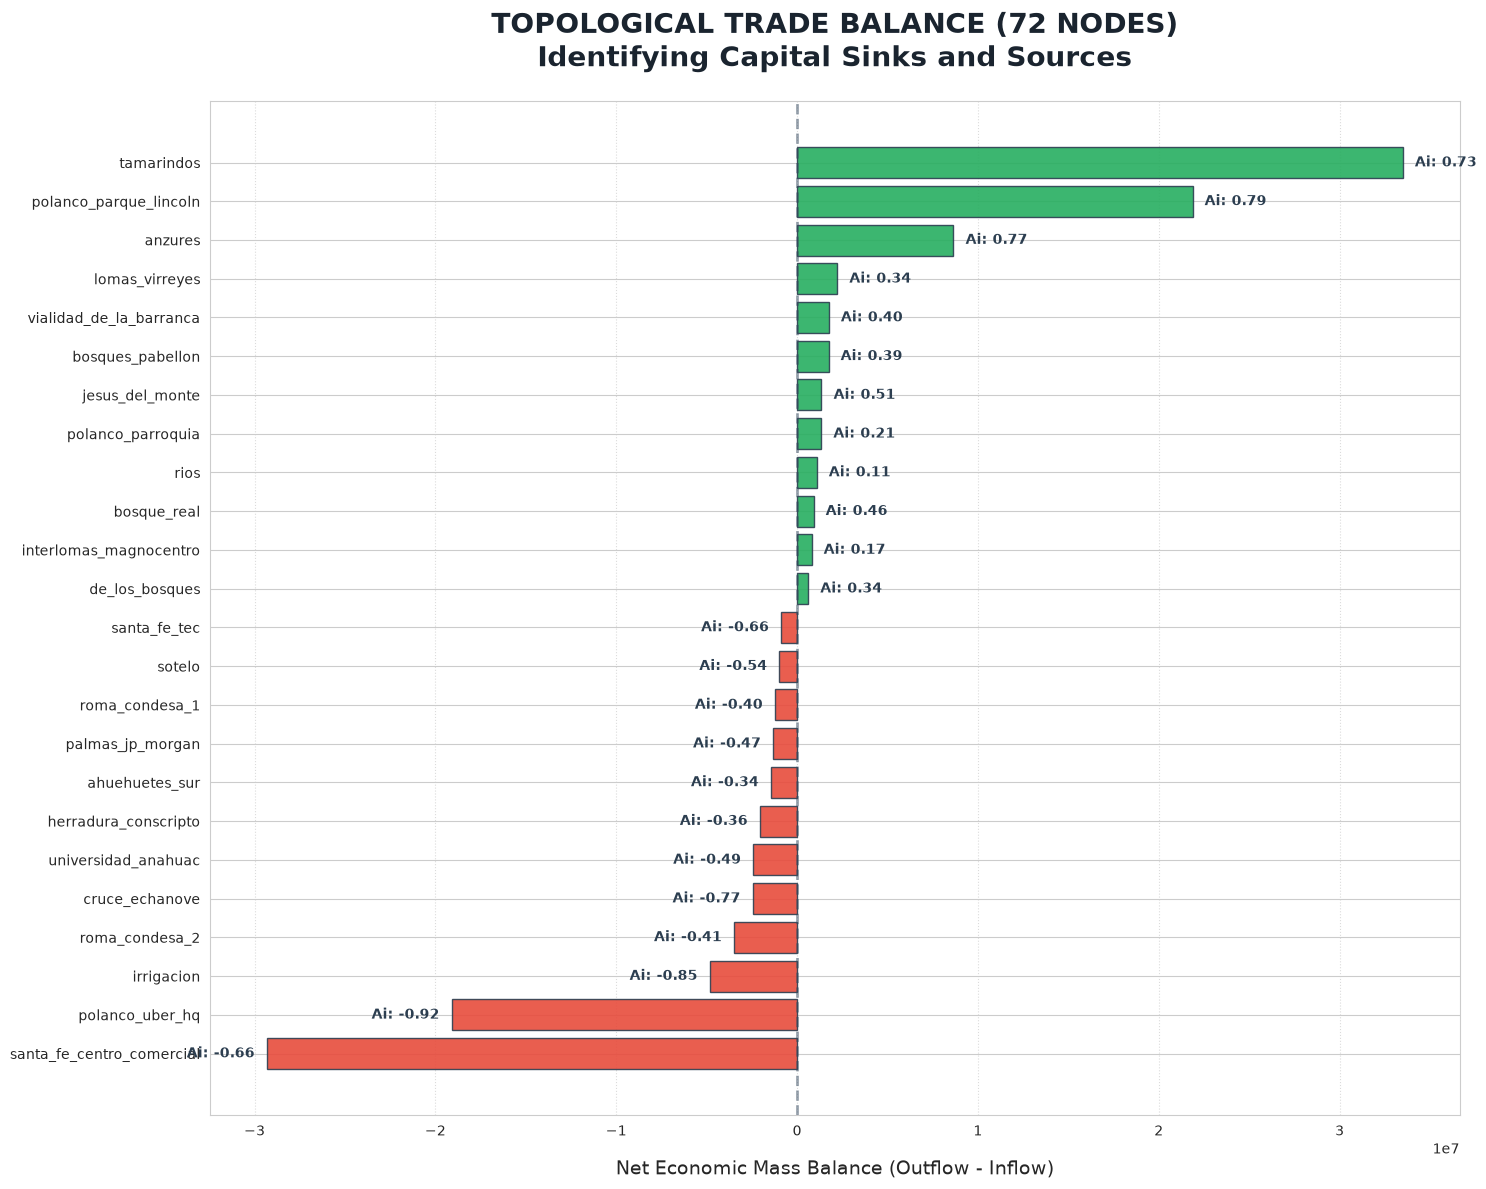

Analysis complete. Detected 34 critical sinks.


In [30]:
import seaborn as sns

print("Computing flow asymmetry across the 72-node economic sphere...")

# 1. Total economic mass extraction (historical gross revenue)
vol = mobility_tensor[:, :, :, :, :, 0]
eph = mobility_tensor[:, :, :, :, :, 1]

# Collapse time dimensions to get total monetary mass per (origin, destination)
total_flow = np.sum(vol * eph, axis=(2, 3, 4))

# 2. Directional flow (in vs. out)
in_flow = np.sum(total_flow, axis=0)   # capital arriving at the zone (target)
out_flow = np.sum(total_flow, axis=1)  # capital leaving the zone (source)

net_balance = out_flow - in_flow
total_activity = out_flow + in_flow

# Asymmetry index: -1 (pure sink) to +1 (pure source)
asymmetry = np.divide(net_balance, total_activity, out=np.zeros_like(net_balance), where=total_activity!=0)

# 3. Consolidate and prune (exclude the out-of-system bucket)
df_flow = pd.DataFrame({
    'zone': ordered_zones,
    'inflow': in_flow,
    'outflow': out_flow,
    'net_balance': net_balance,
    'asymmetry_idx': asymmetry,
    'total_activity': total_activity
})

df_flow = df_flow[(df_flow['total_activity'] > 0) & (df_flow['zone'] != 'unassigned_area')].copy()

def classify_flow(ai):
    if ai <= -0.15: return 'SINK (traps flow)'
    elif ai >= 0.15: return 'SOURCE (expels flow)'
    else: return 'TRANSIT (balanced)'

df_flow['type'] = df_flow['asymmetry_idx'].apply(classify_flow)

# 4. Visualization (tornado chart)
top_sinks = df_flow.sort_values(by='net_balance', ascending=True).head(12)
top_sources = df_flow.sort_values(by='net_balance', ascending=True).tail(12)
df_plot = pd.concat([top_sinks, top_sources])

plt.figure(figsize=(15, 12))
sns.set_style("whitegrid")

colors = ['#E74C3C' if x < 0 else '#27AE60' for x in df_plot['net_balance']]
bars = plt.barh(df_plot['zone'], df_plot['net_balance'], color=colors, edgecolor='#2C3E50', alpha=0.9)

plt.axvline(0, color='#34495E', linewidth=2, linestyle='--', alpha=0.5)

for bar, ai in zip(bars, df_plot['asymmetry_idx']):
    width = bar.get_width()
    offset = (df_plot['net_balance'].abs().max() * 0.02)
    plt.text(width + (offset if width > 0 else -offset),
             bar.get_y() + bar.get_height()/2,
             f"Ai: {ai:.2f}",
             va='center', ha='left' if width > 0 else 'right',
             fontsize=10, fontweight='bold', color='#2C3E50')

plt.title("TOPOLOGICAL TRADE BALANCE (72 NODES)\nIdentifying Capital Sinks and Sources",
          fontsize=20, pad=25, fontweight='black', color='#1A242F')
plt.xlabel("Net Economic Mass Balance (Outflow - Inflow)", fontsize=14, labelpad=15)
plt.grid(axis='x', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"Analysis complete. Detected {len(df_flow[df_flow['type'] == 'SINK (traps flow)'])} critical sinks.")

## Phase 5 — Bridge to Markov

Extracts a transition matrix (P) and a reward matrix (R) from the mobility tensor, treating the 72 zones as a Markov Decision Process state space. Solves the Bellman value function, derives an optimal policy, and runs a simple multi-vehicle fleet-deployment simulator with demand depletion.

#### 5.1 — State-space construction (transition and reward matrices)

Extracts P_ij (probability of moving from zone i to zone j) and R_ij (expected EPH of that move) directly from the tensor, handling zones with no recorded outbound trips as absorbing states.

In [31]:
print("Initializing the MDP engine: building the state space (72 nodes)...")

# 1. Global extraction (collapsing time for the base policy)
vol = mobility_tensor[:, :, :, :, :, 0]
eph = mobility_tensor[:, :, :, :, :, 1]

# Total historical volume from i to j (flow density)
vol_ij = np.sum(vol, axis=(2, 3, 4))
# Total economic mass from i to j (total earnings)
num_eph = np.sum(vol * eph, axis=(2, 3, 4))

# 2. Transition matrix (P_ij)
out_degree_i = np.sum(vol_ij, axis=1, keepdims=True)

# P_ij = trips(i->j) / total_trips_out_of(i)
P_ij = np.divide(vol_ij, out_degree_i, out=np.zeros_like(vol_ij), where=out_degree_i!=0)

# Absorbing states: if a zone has no recorded outbound trips, set P_ii = 1.0 to keep the matrix stochastic
absorbing_states = np.where(out_degree_i.flatten() == 0)[0]
for state in absorbing_states:
    P_ij[state, state] = 1.0
    print(f"   Absorbing state detected: {ordered_zones[state]}")

# 3. Reward matrix (R_ij): expected value of the i -> j transition
R_ij = np.divide(num_eph, vol_ij, out=np.zeros_like(num_eph), where=vol_ij!=0)

# 4. Verify the state space is well-formed
# Skipping a heatmap here: at 72x72 the matrices are too sparse to read visually (mostly empty, a few bright cells).
print(f"\nMatrices extracted successfully for {len(ordered_zones)} states.")
print(f"Row sums in P (should be ~1.0): {np.mean(np.sum(P_ij, axis=1)):.4f}")
print("State space ready for the Bellman equation.")

Initializing the MDP engine: building the state space (72 nodes)...
   Absorbing state detected: bosque_1
   Absorbing state detected: campo_marte
   Absorbing state detected: lomas_olimpo
   Absorbing state detected: santa_fe_bosques_de

Matrices extracted successfully for 72 states.
Row sums in P (should be ~1.0): 1.0000
State space ready for the Bellman equation.


#### 5.2 — Bellman value iteration (long-run state value)

Solves the state-value function V(s) via vectorized value iteration, then ranks zones by the "network bonus" — how much more valuable a zone is long-term versus its immediate EPH.

Solving the Bellman equation over the 72x72 state space...
Converged in 127 iterations.


findfont: Failed to find font weight black, now using 700.
findfont: Failed to find font weight black, now using 700.


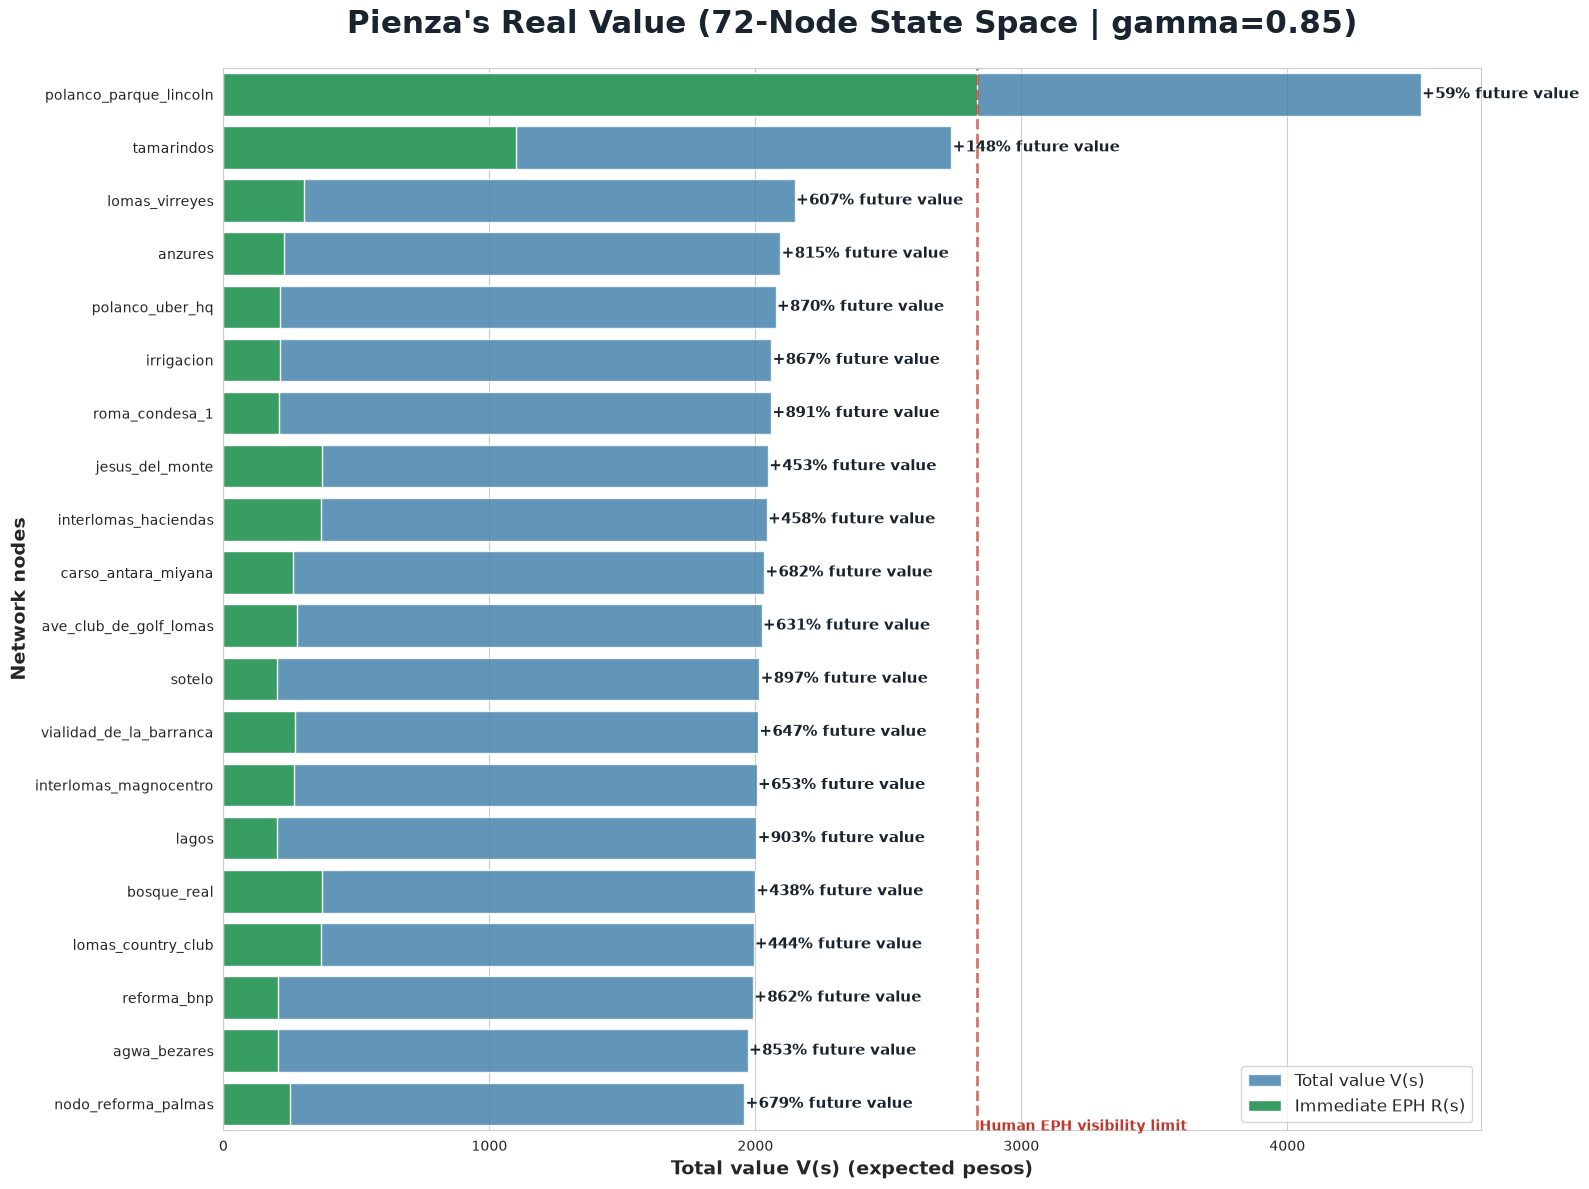

In [32]:
print("Solving the Bellman equation over the 72x72 state space...")

# 1. MDP hyperparameters
gamma = 0.85   # discount factor: values the near future more than the distant one
theta = 1e-7   # convergence threshold
num_states = len(ordered_zones)

# Expected immediate reward per state: R(s) = sum(P(s,s') * R(s,s'))
R_s = np.sum(P_ij * R_ij, axis=1)

# 2. Value iteration (vectorized)
V = np.zeros(num_states)
delta = float('inf')
iterations = 0

while delta > theta:
    V_old = np.copy(V)
    # Matrix Bellman equation: V = R + gamma * P * V
    V = R_s + gamma * np.dot(P_ij, V_old)
    delta = np.max(np.abs(V - V_old))
    iterations += 1

print(f"Converged in {iterations} iterations.")

# 3. Consolidate the ranking
df_bellman = pd.DataFrame({
    'zone': ordered_zones,
    'immediate_value': R_s,
    'long_run_value_Vs': V
})

# Network bonus: the "premium" earned for being well-connected
df_bellman['network_premium_pct'] = ((df_bellman['long_run_value_Vs'] - df_bellman['immediate_value']) / df_bellman['immediate_value']) * 100

df_bellman = df_bellman.sort_values(by='long_run_value_Vs', ascending=False).reset_index(drop=True)

# 4. Visualization
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.figure(figsize=(16, 12))

top_n = 20
df_plot = df_bellman.head(top_n).copy()

# Bars: total value (blue) vs. immediate value (green)
sns.barplot(x='long_run_value_Vs', y='zone', data=df_plot, color='#2980B9', label='Total value V(s)', alpha=0.8)
sns.barplot(x='immediate_value', y='zone', data=df_plot, color='#27AE60', label='Immediate EPH R(s)', alpha=1)

for i, row in df_plot.iterrows():
    plt.text(row['long_run_value_Vs'] + 5, i, f"+{row['network_premium_pct']:.0f}% future value",
             va='center', fontsize=11, fontweight='black', color='#1A242F')

plt.title(f"Pienza's Real Value (72-Node State Space | gamma={gamma})",
          fontsize=22, pad=25, fontweight='black', color='#1A242F')
plt.xlabel("Total value V(s) (expected pesos)", fontsize=14, fontweight='bold')
plt.ylabel("Network nodes", fontsize=14, fontweight='bold')
plt.legend(loc='lower right', frameon=True, fontsize=12)

# Human-visible-horizon line
myopic_limit = df_plot['immediate_value'].max()
plt.axvline(myopic_limit, color='#C0392B', linestyle='--', linewidth=2, alpha=0.7)
plt.text(myopic_limit + 10, top_n - 0.5, "Human EPH visibility limit", color='#C0392B', fontweight='bold')

plt.tight_layout()
plt.show()

#### 5.3 — Optimal policy extraction (Q-values)

Computes Q(s,a) = R(s,a) + gamma*V(s') across the full state space, then extracts a top-3-destination "cheat sheet" per origin zone.

In [33]:
print("Deriving the optimal policy: vectorizing Q-values...")

# 1. Vectorized action-value matrix Q(s, a) = R(s, a) + gamma * V(s')
Q_ij = np.where(P_ij > 0, R_ij + (gamma * V), 0)

# 2. Extract the policy (top destinations per origin)
policy = []

for i, origin in enumerate(ordered_zones):
    sorted_destinations = np.argsort(Q_ij[i, :])[::-1]
    top_destinations = [j for j in sorted_destinations if Q_ij[i, j] > 0][:3]

    if len(top_destinations) > 0:
        d1_idx = top_destinations[0]
        origin_str = origin.replace('_', ' ').title()

        policy.append({
            'Origin (state)': origin_str,
            'Optimal action (pi*)': f"{ordered_zones[d1_idx].replace('_', ' ').title()} (Q: ${Q_ij[i, d1_idx]:.0f})",
            'Plan B': f"{ordered_zones[top_destinations[1]].replace('_', ' ').title()} (Q: ${Q_ij[i, top_destinations[1]]:.0f})" if len(top_destinations) > 1 else "-",
            'Plan C': f"{ordered_zones[top_destinations[2]].replace('_', ' ').title()} (Q: ${Q_ij[i, top_destinations[2]]:.0f})" if len(top_destinations) > 2 else "-"
        })

df_policy = pd.DataFrame(policy)

print("\nOPTIMAL POLICY EXTRACTED (top 5 origins):")
display(df_policy.head(5))
print(f"\nQ matrix exported. {len(df_policy)} decision rules ready to inject into the fleet.")

Deriving the optimal policy: vectorizing Q-values...

OPTIMAL POLICY EXTRACTED (top 5 origins):


,Origin (state),Optimal action (pi*),Plan B,Plan C
0,Agwa Bezares,Polanco Parque Lincoln (Q: $4035),Tamarindos (Q: $2523),Sotelo (Q: $1932)
1,Ahuehuetes Norte,Polanco Parque Lincoln (Q: $3981),Anzures (Q: $2027),Roma Condesa 1 (Q: $2017)
2,Ahuehuetes Sur,Polanco Parque Lincoln (Q: $4004),Tamarindos (Q: $2529),Carso Antara Miyana (Q: $2022)
3,Anahuac 1,Polanco Parque Lincoln (Q: $3956),Lomas Virreyes (Q: $1996),Ave Club De Golf Lomas (Q: $1939)
4,Anzures,Polanco Parque Lincoln (Q: $4133),Tamarindos (Q: $2582),Lomas Virreyes (Q: $2049)



Q matrix exported. 68 decision rules ready to inject into the fleet.


#### 5.4 — Fleet deployment simulator (demand depletion)

Simulates deploying 3 autonomous vehicles (AV's) from each of 3 warehouse zones, 5 hops deep, discounting a route's Q-value by 90% once a vehicle "claims" it — forcing subsequent vehicles to find alternate paths instead of swarming the same corridor.

In [34]:
print("Tracing fleet deployment plans from the 3 main warehouses...")

# 1. Clone the matrix (mutable copy, no artificial friction yet)
Q_real = np.copy(Q_ij)

# 2. Define target warehouses
target_warehouses = [
    'carso_antara_miyana',
    'santa_fe_centro_comercial',
    'interlomas_magnocentro'
]

total_hops = 5
options_per_hop = 3
warehouse_exit_options = 10  # wide radar on the first hop out

# 3. Iterate per warehouse (sequential deployment)
for origin in target_warehouses:
    # Naming safety net
    real_origin = origin
    if real_origin not in ordered_zones:
        if origin == 'santa_fe_centro_comercial' and 'santa_fe_cc' in ordered_zones:
            real_origin = 'santa_fe_cc'
        elif origin == 'interlomas_magnocentro' and 'interlomas' in ordered_zones:
            real_origin = 'interlomas'
        else:
            print(f"\nSkipping origin: not found in the tensor: {origin}")
            continue

    origin_idx = ordered_zones.index(real_origin)
    warehouse_routes = []

    # Deploy vehicles one at a time (3 per warehouse)
    for av_id in range(1, 4):
        candidate_routes = []

        def search_routes(current_zone, path, cumulative_score, depth):
            if depth == total_hops:
                candidate_routes.append({
                    'path_indices': path,
                    'Start': real_origin.replace('_', ' ').title(),
                    'Destination 1': ordered_zones[path[1]].replace('_', ' ').title(),
                    'Destination 2': ordered_zones[path[2]].replace('_', ' ').title(),
                    'Destination 3': ordered_zones[path[3]].replace('_', ' ').title(),
                    'Destination 4': ordered_zones[path[4]].replace('_', ' ').title(),
                    'Destination 5': ordered_zones[path[5]].replace('_', ' ').title(),
                    'Tactical score': cumulative_score
                })
                return

            options = np.argsort(Q_real[current_zone, :])[::-1]
            valid = [dst for dst in options if Q_real[current_zone, dst] > 0 and dst != current_zone]

            exploration_limit = warehouse_exit_options if depth == 0 else options_per_hop

            for dst in valid[:exploration_limit]:
                search_routes(dst, path + [dst], cumulative_score + Q_real[current_zone, dst], depth + 1)

        search_routes(origin_idx, [origin_idx], 0, 0)

        if candidate_routes:
            best_route = sorted(candidate_routes, key=lambda x: x['Tactical score'], reverse=True)[0]
            warehouse_routes.append(best_route)

            # Demand depletion: discount the winning route's edges by 90%
            # so the next vehicle in this warehouse looks for new corridors.
            winning_path = best_route['path_indices']
            for i in range(len(winning_path) - 1):
                u = winning_path[i]
                v = winning_path[i+1]
                Q_real[u, v] *= 0.10

    # Structure and display
    print("\n" + "="*120)
    print(f"WAREHOUSE: {real_origin.replace('_', ' ').upper()} (deployment with demand depletion)")
    print("="*120)

    if not warehouse_routes:
        print(f"No viable routes found from {real_origin}.")
    else:
        df_final = pd.DataFrame(warehouse_routes)
        df_final = df_final.drop(columns=['path_indices'])

        df_final['Tactical score'] = df_final['Tactical score'].apply(lambda x: f"{x:,.0f} pts")
        df_final.reset_index(drop=True, inplace=True)
        df_final.index += 1

        display(df_final)

print("\nFleet deployment complete. Swarm effect neutralized.")

Tracing fleet deployment plans from the 3 main warehouses...

WAREHOUSE: CARSO ANTARA MIYANA (deployment with demand depletion)


,Start,Destination 1,Destination 2,Destination 3,Destination 4,Destination 5,Tactical score
1,Carso Antara Miyana,Polanco Parque Lincoln,Polanco Uber Hq,Polanco Parque Lincoln,Polanco Uber Hq,Polanco Parque Lincoln,"31,369 pts"
2,Carso Antara Miyana,Tamarindos,Santa Fe Centro Comercial,Polanco Parque Lincoln,Irrigacion,Polanco Parque Lincoln,"29,831 pts"
3,Carso Antara Miyana,Santa Fe Centro Comercial,Fuentes Casino,Polanco Parque Lincoln,Anzures,Polanco Parque Lincoln,"14,181 pts"



WAREHOUSE: SANTA FE CENTRO COMERCIAL (deployment with demand depletion)


,Start,Destination 1,Destination 2,Destination 3,Destination 4,Destination 5,Tactical score
1,Santa Fe Centro Comercial,Sedena,Polanco Parque Lincoln,Rios,Roma Condesa 1,Polanco Parque Lincoln,"14,214 pts"
2,Santa Fe Centro Comercial,Reforma Social,Polanco Parque Lincoln,Ave Club De Golf Lomas,Lomas Virreyes,Polanco Parque Lincoln,"14,226 pts"
3,Santa Fe Centro Comercial,Reforma Bnp,Polanco Parque Lincoln,Lomas Virreyes,Universidad Anahuac,Polanco Parque Lincoln,"14,027 pts"



WAREHOUSE: INTERLOMAS MAGNOCENTRO (deployment with demand depletion)


,Start,Destination 1,Destination 2,Destination 3,Destination 4,Destination 5,Tactical score
1,Interlomas Magnocentro,Tamarindos,Carretera Libre,Jesus Del Monte,Bosque 3,Polanco Parque Lincoln,"13,127 pts"
2,Interlomas Magnocentro,Lagos,Polanco Parque Lincoln,Interlomas Magnocentro,Lagos,Polanco Parque Lincoln,"13,745 pts"
3,Interlomas Magnocentro,Sotelo,Polanco Parque Lincoln,Carso Antara Miyana,Juarez Rosa,Polanco Parque Lincoln,"13,656 pts"



Fleet deployment complete. Swarm effect neutralized.


#### 5.5 — Fleet deployment visualization

Draws the 3 vehicles' routes from the Carso Antara Miyana warehouse with curved, non-overlapping arrows so each hop is visually distinguishable.

Rendering the tactical deployment fan with anti-collision geometry...


findfont: Failed to find font weight black, now using 700.
findfont: Failed to find font weight black, now using 700.


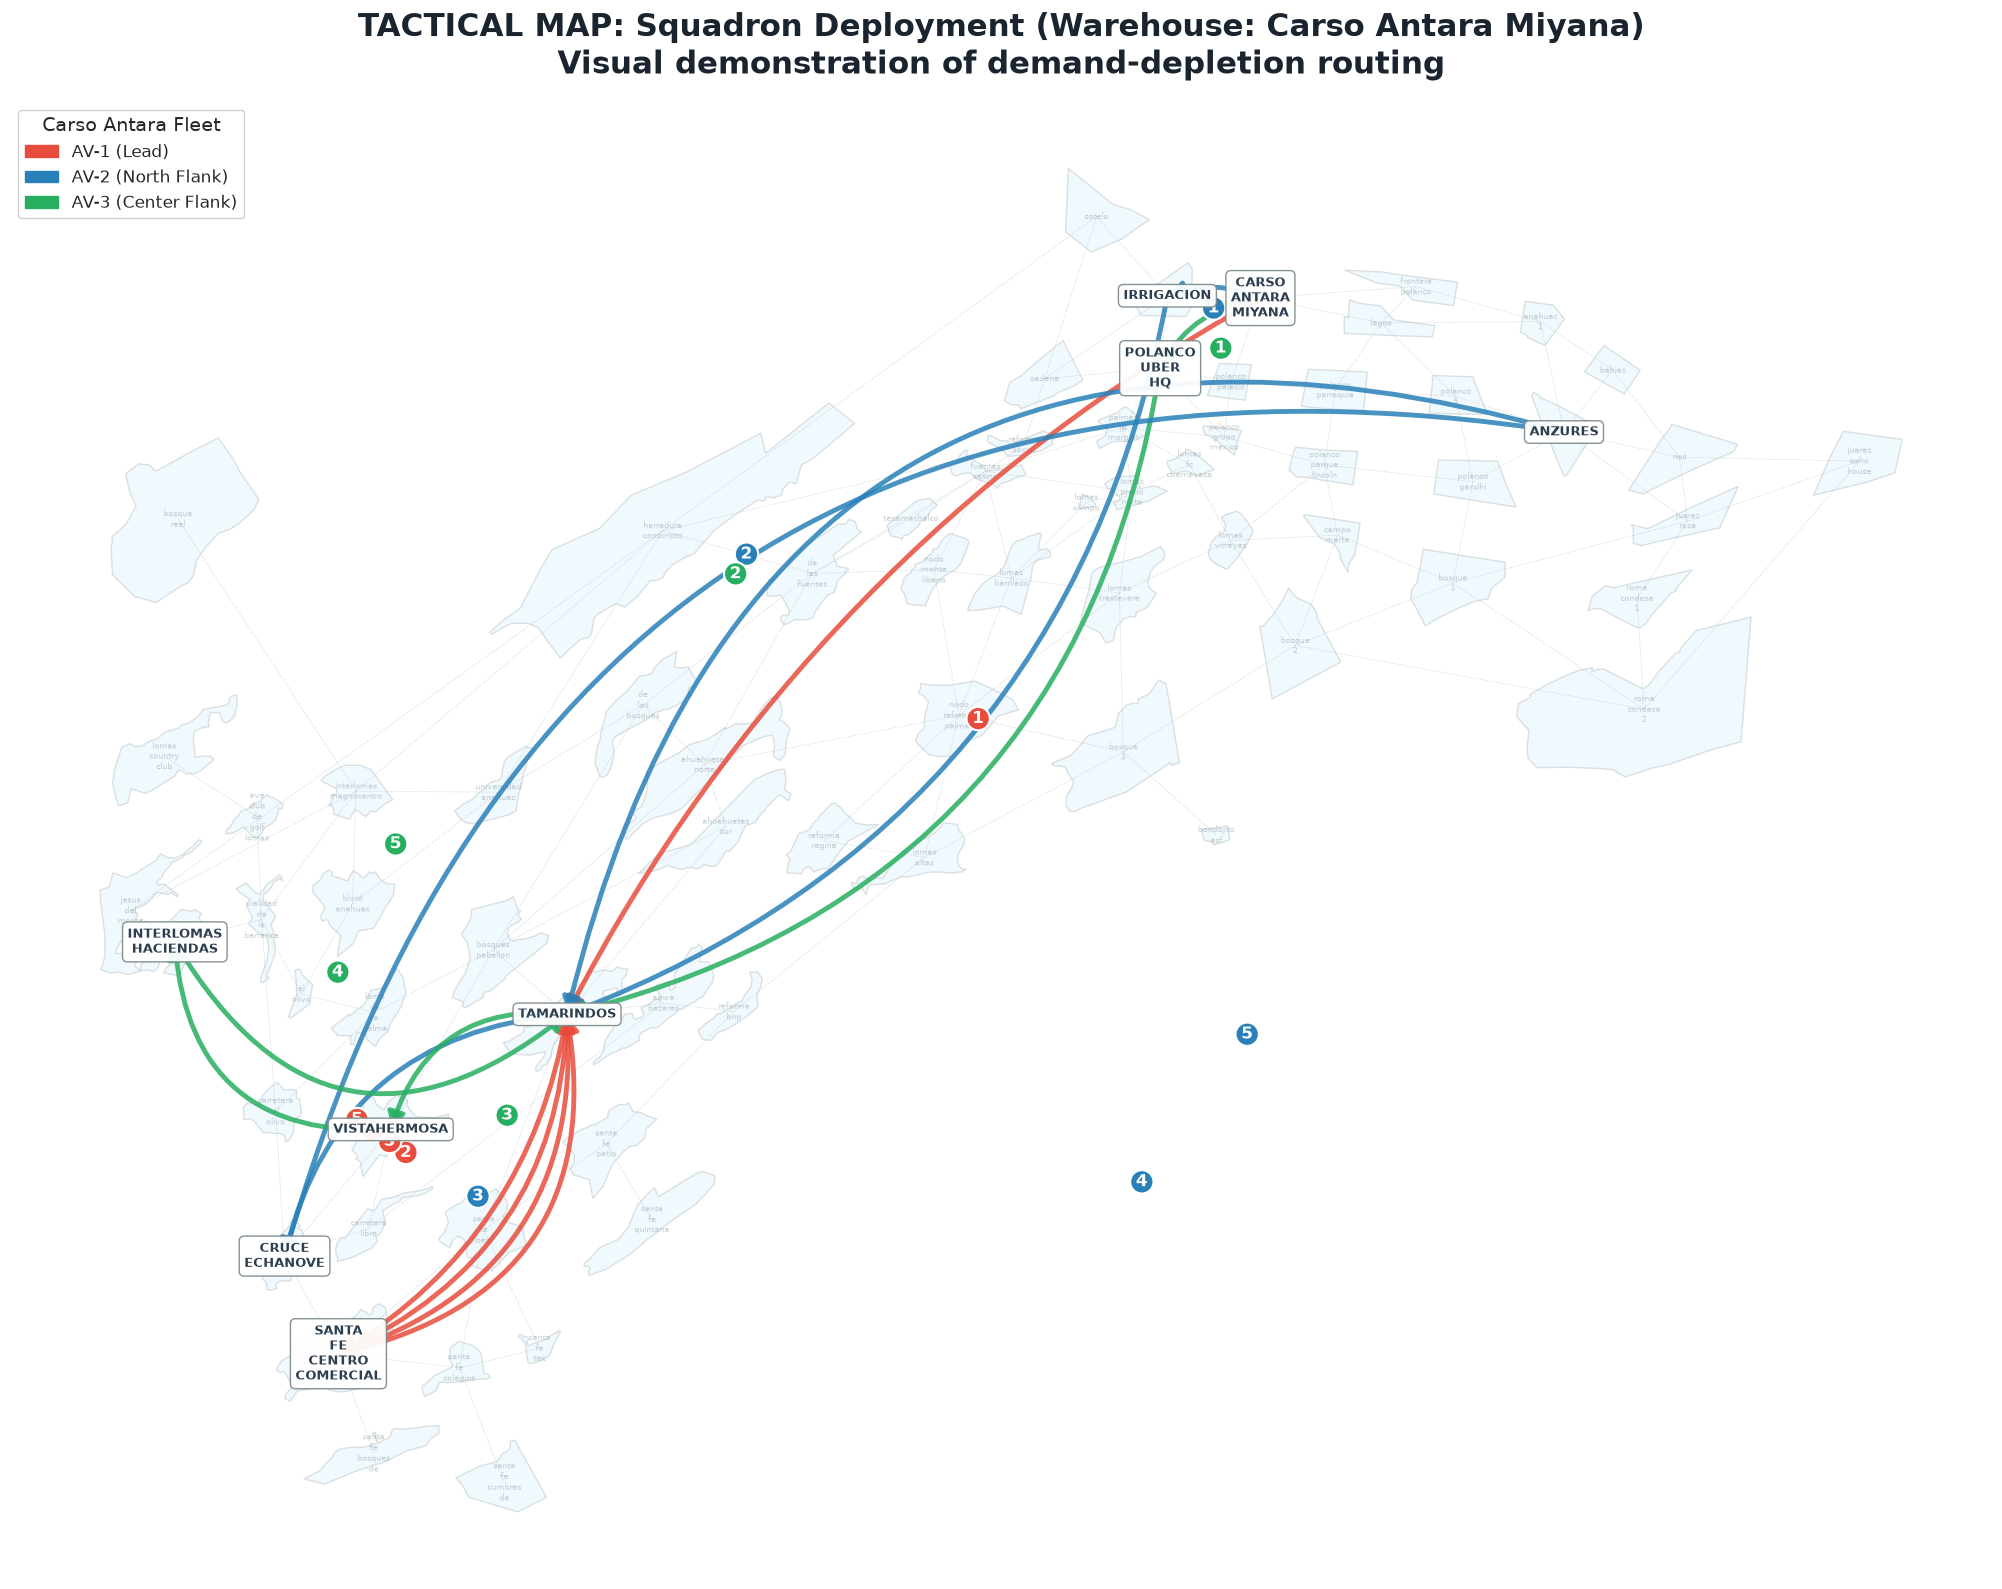

Tactical map rendered. Iterative routes are visually separated.


In [35]:
import math
import matplotlib.patches as mpatches

print("Rendering the tactical deployment fan with anti-collision geometry...")

# 1. Define the routes
route_1 = ['carso_antara_miyana', 'tamarindos', 'santa_fe_cc', 'tamarindos', 'santa_fe_cc', 'tamarindos']
route_2 = ['carso_antara_miyana', 'irrigacion', 'tamarindos', 'cruce_echanove', 'anzures', 'tamarindos']
route_3 = ['carso_antara_miyana', 'polanco_uber_hq', 'tamarindos', 'vistahermosa', 'interlomas_haciendas', 'tamarindos']

fleet = [
    {'name': 'AV-1 (Lead)', 'route': route_1, 'color': '#E74C3C'},
    {'name': 'AV-2 (North Flank)', 'route': route_2, 'color': '#2980B9'},
    {'name': 'AV-3 (Center Flank)', 'route': route_3, 'color': '#27AE60'}
]

# Preventive substitution for Santa Fe naming
for av in fleet:
    av['route'] = ['santa_fe_centro_comercial' if z == 'santa_fe_cc' and 'santa_fe_cc' not in G_manual.nodes() else z for z in av['route']]

# 2. Canvas setup
fig, ax = plt.subplots(figsize=(22, 16))
ax.set_facecolor('#F8F9F9')

# A. Draw the base map
gdf_plot = gdf_f.set_geometry('schematic_geometry')
gdf_plot.plot(ax=ax, facecolor='#E1F5FE', edgecolor='#BDC3C7', linewidth=1.0, alpha=0.5, zorder=1)

# B. Draw the ghost streets
pos = nx.get_node_attributes(G_manual, 'schematic_centroid')
for u, v in G_manual.edges():
    if u in pos and v in pos:
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color='#BDC3C7', linewidth=0.5, linestyle=':', zorder=2)

# 3. Draw the routes with curvature offsets (anti-collision)
for idx, av in enumerate(fleet):
    route = av['route']
    color = av['color']

    for i in range(len(route) - 1):
        origin = route[i]
        destination = route[i+1]

        if origin in pos and destination in pos:
            start = pos[origin]
            end = pos[destination]

            # Alternate curvature sign per hop, growing with the hop index
            sign = 1 if i % 2 == 0 else -1
            base_rad = 0.15
            rad = (base_rad + (i * 0.08) + (idx * 0.05)) * sign

            edge = FancyArrowPatch(
                start, end, connectionstyle=f"arc3,rad={rad}",
                color=color, linewidth=3.5, alpha=0.85,
                arrowstyle='-|>,head_length=8,head_width=5', zorder=4 + i
            )
            ax.add_patch(edge)

            # Compute the perpendicular offset point on the curve for the hop-number label
            dx = end[0] - start[0]
            dy = end[1] - start[1]
            length = math.hypot(dx, dy)

            if length > 0:
                px = -dy / length
                py = dx / length

                offset_x = px * (rad * length * 0.6)
                offset_y = py * (rad * length * 0.6)

                mid_x = ((start[0] + end[0]) / 2) + offset_x
                mid_y = ((start[1] + end[1]) / 2) + offset_y

                ax.text(mid_x, mid_y, str(i+1), color='white',
                        fontsize=12, fontweight='black',
                        ha='center', va='center',
                        bbox=dict(facecolor=color, edgecolor='white', linewidth=1.5, boxstyle='circle,pad=0.2'),
                        zorder=10 + i + idx)

# 4. Node labeling
for zone, (x, y) in pos.items():
    if any(zone in av['route'] for av in fleet):
        ax.text(x, y, zone.replace('_', '\n').upper(),
                fontsize=9, fontweight='black', color='#2C3E50',
                ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.95, edgecolor='#7F8C8D', boxstyle='round,pad=0.4'), zorder=20)
    else:
        ax.text(x, y, zone.replace('_', '\n'), fontsize=6, color='#95A5A6', ha='center', va='center', alpha=0.5, zorder=3)

# 5. Metadata
plt.title("TACTICAL MAP: Squadron Deployment (Warehouse: Carso Antara Miyana)\nVisual demonstration of demand-depletion routing",
          fontsize=22, pad=20, fontweight='black', color='#1A242F')
legend_patches = [mpatches.Patch(color=av['color'], label=av['name']) for av in fleet]
plt.legend(handles=legend_patches, title="Carso Antara Fleet", loc='upper left', fontsize=12, title_fontsize=14, framealpha=0.9)

plt.axis('off')
plt.tight_layout()
plt.show()

print("Tactical map rendered. Iterative routes are visually separated.")

#### 5.6 — Index audit (zero assumptions)

Prints the exact day/hour index mapping used by the tensor, so downstream code (e.g. the Streamlit app) can hardcode the same indices with confidence.

In [36]:
print("Extracting the exact tensor index mapping (no assumptions)...")
print("-" * 50)

# 1. Day mapping (from 'ordered_days')
print("EXACT DAY MAPPING (tensor axis 3):")
for idx, day in enumerate(ordered_days):
    print(f"   Tensor index [{idx}]  ->  {day}")

print("\n" + "-" * 50)

# 2. Hour mapping (from 'ordered_hours')
print("EXACT HOUR MAPPING (tensor axis 2):")
for idx, hour in enumerate(ordered_hours):
    hour_str = str(int(hour)).zfill(2)
    print(f"   Tensor index [{idx:02d}] ->  {hour_str}:00 hrs")

print("\n" + "-" * 50)
print("Done. These indices are the ones to hardcode in the Streamlit app.")

Extracting the exact tensor index mapping (no assumptions)...
--------------------------------------------------
EXACT DAY MAPPING (tensor axis 3):
   Tensor index [0]  ->  Monday
   Tensor index [1]  ->  Tuesday
   Tensor index [2]  ->  Wednesday
   Tensor index [3]  ->  Thursday
   Tensor index [4]  ->  Friday
   Tensor index [5]  ->  Saturday
   Tensor index [6]  ->  Sunday

--------------------------------------------------
EXACT HOUR MAPPING (tensor axis 2):
   Tensor index [00] ->  10:00 hrs
   Tensor index [01] ->  11:00 hrs
   Tensor index [02] ->  12:00 hrs
   Tensor index [03] ->  13:00 hrs
   Tensor index [04] ->  14:00 hrs
   Tensor index [05] ->  15:00 hrs
   Tensor index [06] ->  16:00 hrs
   Tensor index [07] ->  17:00 hrs
   Tensor index [08] ->  18:00 hrs
   Tensor index [09] ->  19:00 hrs
   Tensor index [10] ->  20:00 hrs
   Tensor index [11] ->  21:00 hrs
   Tensor index [12] ->  22:00 hrs
   Tensor index [13] ->  05:00 hrs
   Tensor index [14] ->  06:00 hrs
   Tens

#### 5.7 — Temporal slicing preview (Streamlit prototype)

Compares the value snapshot at Monday 6 AM vs. Friday 2 PM, using the audited indices above, as a preview of what a Streamlit time-slider view would show.

Extracting temporal slices with audited indices...


findfont: Failed to find font weight black, now using 700.


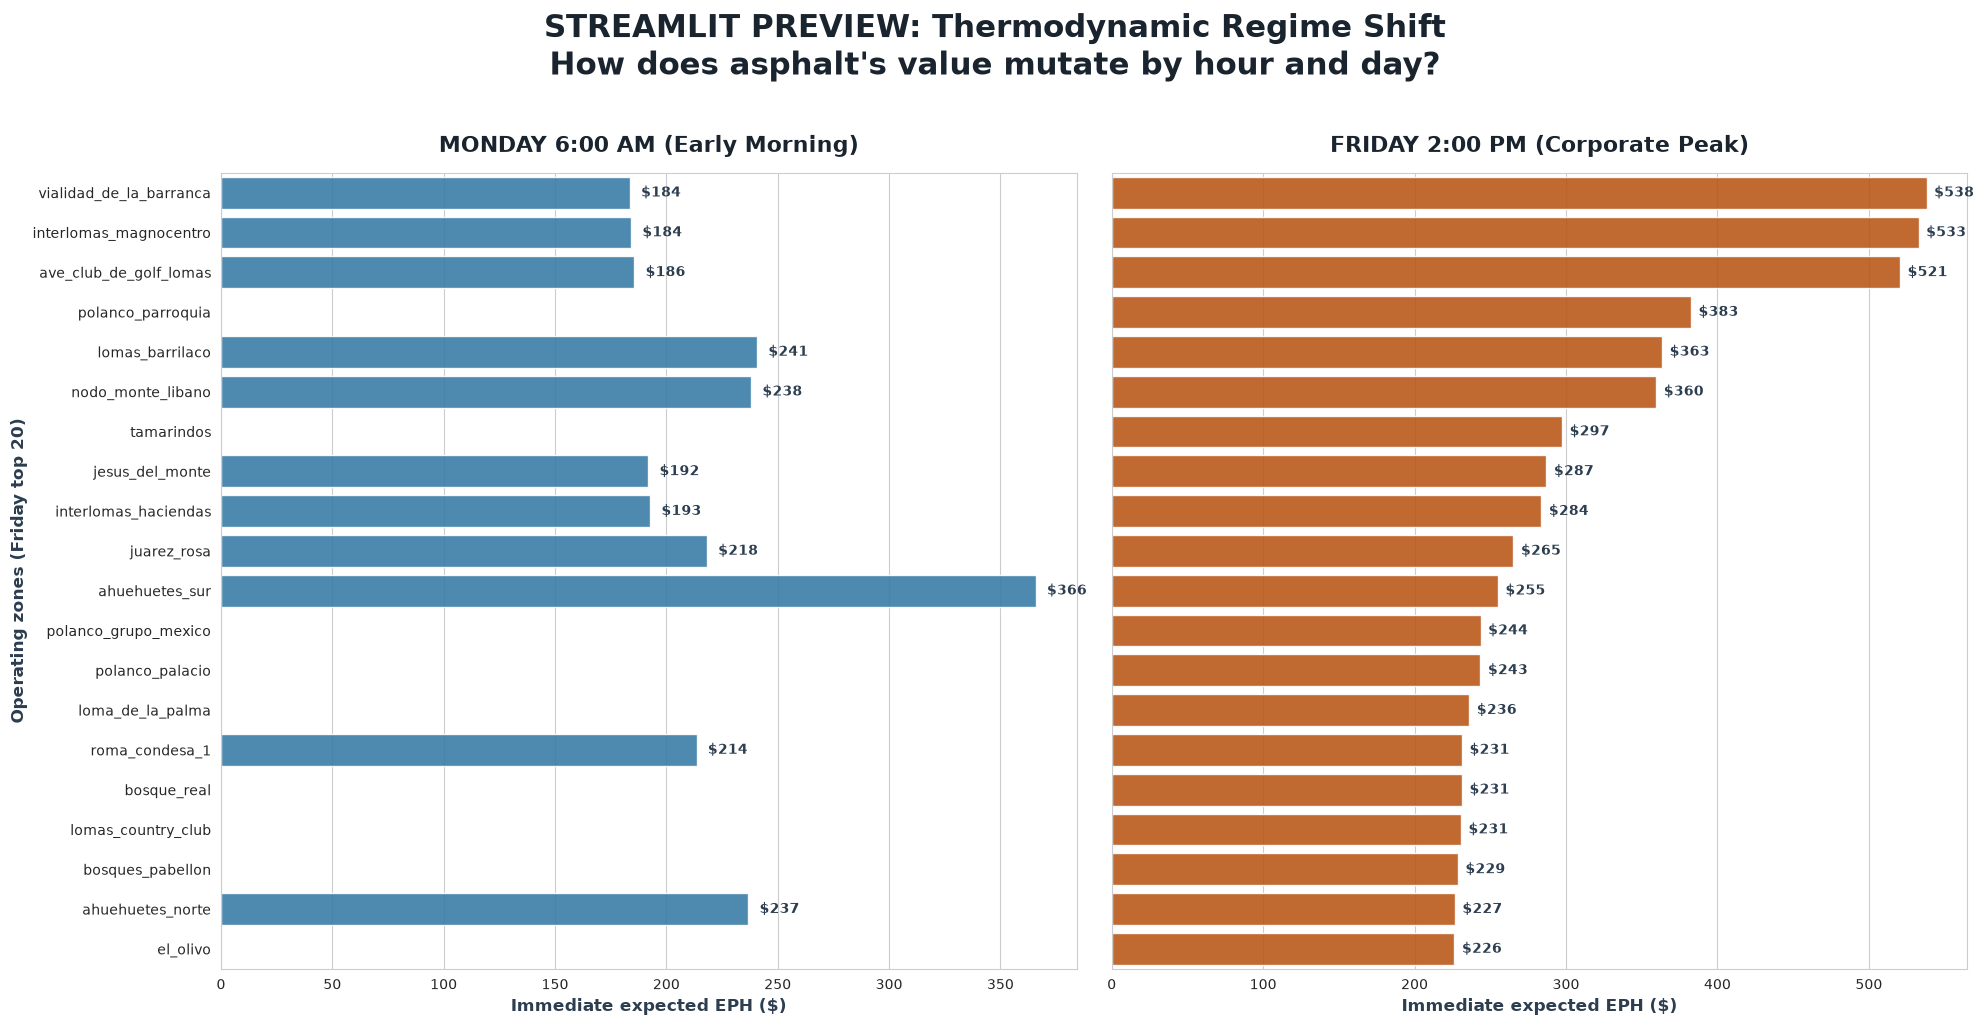

Slicing executed with surgical precision. This is the view the app will show.


In [37]:
print("Extracting temporal slices with audited indices...")

# --- Function to extract a temporal cut ---
def extract_temporal_snapshot(day_idx, hour_idx, cut_name):
    # Slice: [origin, destination, hour, day, weeks, metric]
    vol_slice = mobility_tensor[:, :, hour_idx, day_idx, :, 0]
    eph_slice = mobility_tensor[:, :, hour_idx, day_idx, :, 1]

    vol_ij = np.sum(vol_slice, axis=2)
    num_eph = np.sum(vol_slice * eph_slice, axis=2)

    out_degree = np.sum(vol_ij, axis=1, keepdims=True)
    P_ij = np.divide(vol_ij, out_degree, out=np.zeros_like(vol_ij), where=out_degree!=0)
    R_ij = np.divide(num_eph, vol_ij, out=np.zeros_like(num_eph), where=vol_ij!=0)

    R_s = np.sum(P_ij * R_ij, axis=1)

    return pd.DataFrame({
        'zone': ordered_zones,
        f'EPH_{cut_name}': R_s,
        f'Vol_{cut_name}': out_degree.flatten()
    })

# --- Extract the two scenarios ---
# Monday (0) at 6:00 AM (index 14)
df_monday = extract_temporal_snapshot(day_idx=0, hour_idx=14, cut_name="Monday_6AM")
# Friday (4) at 2:00 PM (index 4)
df_friday = extract_temporal_snapshot(day_idx=4, hour_idx=4, cut_name="Friday_2PM")

df_compare = pd.merge(df_monday, df_friday, on='zone')

# Drop zones dead in both time slots
df_compare = df_compare[(df_compare['Vol_Monday_6AM'] > 0) | (df_compare['Vol_Friday_2PM'] > 0)].copy()

# Sort by Friday's value to see the contrast
df_compare = df_compare.sort_values(by='EPH_Friday_2PM', ascending=False).head(20).reset_index(drop=True)

# --- Visualization (dashboard mockup) ---
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

# Panel 1: Monday 6:00 AM
sns.barplot(x='EPH_Monday_6AM', y='zone', data=df_compare, ax=axes[0], color='#2980B9', alpha=0.9)
axes[0].set_title("MONDAY 6:00 AM (Early Morning)", fontsize=16, fontweight='black', color='#1A242F', pad=15)
axes[0].set_xlabel("Immediate expected EPH ($)", fontsize=12, fontweight='bold', color='#2C3E50')
axes[0].set_ylabel("Operating zones (Friday top 20)", fontsize=12, fontweight='bold', color='#2C3E50')

# Panel 2: Friday 2:00 PM
sns.barplot(x='EPH_Friday_2PM', y='zone', data=df_compare, ax=axes[1], color='#D35400', alpha=0.9)
axes[1].set_title("FRIDAY 2:00 PM (Corporate Peak)", fontsize=16, fontweight='black', color='#1A242F', pad=15)
axes[1].set_xlabel("Immediate expected EPH ($)", fontsize=12, fontweight='bold', color='#2C3E50')
axes[1].set_ylabel("")

for ax, col in zip(axes, ['EPH_Monday_6AM', 'EPH_Friday_2PM']):
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.text(width + 5, p.get_y() + p.get_height()/2, f"${width:.0f}",
                    va='center', fontsize=10, fontweight='bold', color='#2C3E50')

plt.suptitle("STREAMLIT PREVIEW: Thermodynamic Regime Shift\nHow does asphalt's value mutate by hour and day?",
             fontsize=22, fontweight='black', y=1.02, color='#1A242F')

plt.tight_layout()
plt.show()

print("Slicing executed with surgical precision. This is the view the app will show.")

#### 5.8 — Time-aware flight plan with memory fallback

Same demand-depletion search as 6.4, but re-evaluated hour by hour along the route, falling back to the global Q-matrix whenever a specific time slot has no data, so the agent never gets stuck.

In [38]:
from IPython.display import HTML

def dynamic_shift_simulator(start_day_idx, start_hour_idx, scenario_name):
    print(f"Starting simulation: {scenario_name}")

    # 1. Extract Q(s, a) for a specific hour/day, with a global fallback
    def get_temporal_Q(d_idx, h_idx):
        # Tensor slice: [origin, destination, hour, day, product, channel], summed over products
        vol_t = np.sum(mobility_tensor[:, :, h_idx, d_idx, :, 0], axis=2)
        eph_t = np.sum(mobility_tensor[:, :, h_idx, d_idx, :, 1], axis=2)

        out_deg = np.sum(vol_t, axis=1, keepdims=True)

        # If this hour has no data at all, fall back to the global long-run Q matrix
        if np.sum(out_deg) == 0:
            return Q_ij

        P_local = np.divide(vol_t, out_deg, out=np.zeros_like(vol_t), where=out_deg!=0)
        R_local = np.divide(vol_t * eph_t, vol_t, out=np.zeros_like(vol_t), where=vol_t!=0)

        Q_t = np.where(P_local > 0, R_local + (gamma * V), 0)

        # If a specific zone has no outbound trips this hour, inject the global fallback
        # so the agent doesn't get stuck.
        empty_zones = (np.sum(Q_t, axis=1) == 0)
        Q_t[empty_zones] = Q_ij[empty_zones]

        return Q_t

    # 2. Recursive search algorithm
    anzures_idx = ordered_zones.index('anzures')
    dynamic_routes = []
    max_h_idx = len(h_map)

    def search_with_clock(current_zone, path, cumulative_score, h_idx, depth):
        if depth == 5:
            dynamic_routes.append({
                'Start': 'Anzures',
                'Hop 1 (T+0)': ordered_zones[path[1]].replace('_', ' ').title(),
                'Hop 2 (T+1)': ordered_zones[path[2]].replace('_', ' ').title(),
                'Hop 3 (T+2)': ordered_zones[path[3]].replace('_', ' ').title(),
                'Hop 4 (T+3)': ordered_zones[path[4]].replace('_', ' ').title(),
                'Hop 5 (T+4)': ordered_zones[path[5]].replace('_', ' ').title(),
                'Total score': cumulative_score
            })
            return

        Q_now = get_temporal_Q(start_day_idx, h_idx)

        # Optional penalty on Polanco (kept from the original tuning)
        try:
            idx_linc = ordered_zones.index('polanco_parque_lincoln')
            Q_now[:, idx_linc] *= 0.50
        except ValueError:
            pass

        options = np.argsort(Q_now[current_zone, :])[::-1]
        valid = [dst for dst in options if Q_now[current_zone, dst] > 0 and dst != current_zone]

        if not valid:
            return

        for dst in valid[:3]:
            next_hour = (h_idx + 1) % max_h_idx
            search_with_clock(dst, path + [dst], cumulative_score + Q_now[current_zone, dst], next_hour, depth + 1)

    search_with_clock(anzures_idx, [anzures_idx], 0, start_hour_idx, 0)

    # Format results
    df_res = pd.DataFrame(dynamic_routes)
    if not df_res.empty:
        df_res = df_res.sort_values('Total score', ascending=False).head(10)
        df_res['Total score'] = df_res['Total score'].apply(lambda x: f"${x:,.0f} EPH-Eq")
        df_res.reset_index(drop=True, inplace=True)
        df_res.index += 1
    else:
        print(f"Could not generate routes for {scenario_name}. Anzures is likely an absorbing state in that time slot.")

    return df_res

# --- Run the scenarios ---
# Monday (0) 6:00 AM (index 14, per the 6.6 audit)
df_monday_evol = dynamic_shift_simulator(0, 14, "MONDAY 6:00 AM (Early Morning)")
# Friday (4) 2:00 PM (index 4, per the 6.6 audit)
df_friday_evol = dynamic_shift_simulator(4, 4, "FRIDAY 2:00 PM (Peak)")

print("\n" + "="*120)
print("RESULTS: OPTIMAL ROUTES WITH TIME EVOLUTION")
print("="*120)

if not df_monday_evol.empty:
    print("\nMONDAY SCENARIO:")
    display(HTML(df_monday_evol.to_html(classes='table table-dark table-striped')))

if not df_friday_evol.empty:
    print("\nFRIDAY SCENARIO:")
    display(HTML(df_friday_evol.to_html(classes='table table-dark table-striped')))

Starting simulation: MONDAY 6:00 AM (Early Morning)
Starting simulation: FRIDAY 2:00 PM (Peak)

RESULTS: OPTIMAL ROUTES WITH TIME EVOLUTION

MONDAY SCENARIO:


,Start,Hop 1 (T+0),Hop 2 (T+1),Hop 3 (T+2),Hop 4 (T+3),Hop 5 (T+4),Total score
1,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Tamarindos,Santa Fe Centro Comercial,Tamarindos,"$18,344 EPH-Eq"
2,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Tamarindos,Santa Fe Centro Comercial,Fuentes Casino,"$17,994 EPH-Eq"
3,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Tamarindos,Santa Fe Centro Comercial,Sedena,"$17,985 EPH-Eq"
4,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Fuentes Casino,Tamarindos,Santa Fe Centro Comercial,"$17,935 EPH-Eq"
5,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Sedena,Tamarindos,Santa Fe Centro Comercial,"$17,926 EPH-Eq"
6,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Fuentes Casino,Ave Club De Golf Lomas,Tamarindos,"$10,859 EPH-Eq"
7,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Sedena,Vialidad De La Barranca,Tamarindos,"$10,826 EPH-Eq"
8,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Fuentes Casino,Vialidad De La Barranca,Tamarindos,"$10,818 EPH-Eq"
9,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Fuentes Casino,Tamarindos,Carretera Al Olivo,"$10,638 EPH-Eq"
10,Anzures,Juarez Rosa,Santa Fe Centro Comercial,Fuentes Casino,Tamarindos,Carretera Libre,"$10,633 EPH-Eq"



FRIDAY SCENARIO:


,Start,Hop 1 (T+0),Hop 2 (T+1),Hop 3 (T+2),Hop 4 (T+3),Hop 5 (T+4),Total score
1,Anzures,Carso Antara Miyana,Tamarindos,Ahuehuetes Sur,Tamarindos,Santa Fe Centro Comercial,"$18,484 EPH-Eq"
2,Anzures,Carso Antara Miyana,Anzures,Lomas Virreyes,Tamarindos,Santa Fe Centro Comercial,"$18,266 EPH-Eq"
3,Anzures,Carso Antara Miyana,Anzures,Polanco Uber Hq,Tamarindos,Santa Fe Centro Comercial,"$18,000 EPH-Eq"
4,Anzures,Carso Antara Miyana,Tamarindos,Santa Fe Quintana,Carso Antara Miyana,Tamarindos,"$11,193 EPH-Eq"
5,Anzures,Carso Antara Miyana,Tamarindos,Sante Fe Patio,Carso Antara Miyana,Tamarindos,"$11,191 EPH-Eq"
6,Anzures,Carso Antara Miyana,Tamarindos,Ahuehuetes Sur,Tamarindos,Carretera Al Olivo,"$11,187 EPH-Eq"
7,Anzures,Carso Antara Miyana,Tamarindos,Ahuehuetes Sur,Tamarindos,Carretera Libre,"$11,182 EPH-Eq"
8,Anzures,Carso Antara Miyana,Tamarindos,Ahuehuetes Sur,Carso Antara Miyana,Tamarindos,"$10,969 EPH-Eq"
9,Anzures,Carso Antara Miyana,Anzures,Lomas Virreyes,Tamarindos,Carretera Al Olivo,"$10,968 EPH-Eq"
10,Anzures,Carso Antara Miyana,Anzures,Lomas Virreyes,Tamarindos,Carretera Libre,"$10,963 EPH-Eq"


## Phase 6 — Export for Kepler / PyDeck

Exports every active route (not just the top-N) as a flat CSV of arcs with coordinates and EPH weight, audits its integrity, visually cross-checks 10 random trips against the source GeoJSON, then progressively enriches the CSV with edge-level centrality and economic metrics for the Streamlit map.

### Streamlit export

#### 6.1 — Export all arcs for PyDeck

Builds a flat CSV of every active (origin, destination) route with its rank, historical volume, EPH weight, and start/end coordinates — no top-N cutoff, so the full network can be rendered.

In [39]:
print("Generating the full-arcs dataset for PyDeck...")

# 1. Recover the global economics
vol_ij = np.sum(mobility_tensor[:, :, :, :, :, 0], axis=(2, 3, 4))
num_eph = np.sum(mobility_tensor[:, :, :, :, :, 0] * mobility_tensor[:, :, :, :, :, 1], axis=(2, 3, 4))

# Master EPH weight matrix (profitability)
R_ij = np.divide(num_eph, vol_ij, out=np.zeros_like(num_eph), where=vol_ij!=0)

# 2. Extract every arc per origin zone (no top-5 cutoff)
arc_data = []
positions = nx.get_node_attributes(G_manual, 'real_centroid')

for i, origin in enumerate(ordered_zones):
    if origin not in positions: continue

    valid_routes = np.where(vol_ij[i, :] > 0)[0]
    if len(valid_routes) == 0: continue

    # Sort by profitability (R_ij), keeping every route
    sorted_routes = sorted(valid_routes, key=lambda j: R_ij[i, j], reverse=True)

    for rank, j in enumerate(sorted_routes):
        destination = ordered_zones[j]
        if destination not in positions: continue

        arc_data.append({
            'origen_id': origin,
            'destino_id': destination,
            'rank_ruta': rank + 1,
            'volumen_historico': vol_ij[i, j],
            'peso_maestro_eph': R_ij[i, j],
            'start_lon': positions[origin][0],
            'start_lat': positions[origin][1],
            'end_lon': positions[destination][0],
            'end_lat': positions[destination][1]
        })

df_arcos = pd.DataFrame(arc_data)
print(f"Extracted {len(df_arcos)} total vectors.")

# 3. Export to CSV
export_path = os.path.join(DUMP_DIR, '0608_260512_tensor_arcos_mvp.csv')
df_arcos.to_csv(export_path, index=False)

print(f"Full dataset ready at: {export_path}")

Generating the full-arcs dataset for PyDeck...
Extracted 2437 total vectors.
Full dataset ready at: /workspaces/pienza/data/dumped_files/0608_260512_tensor_arcos_mvp.csv


#### 6.2 — Kepler CSV integrity audit

Validates row/column counts, nulls, dtypes, and a basic statistical summary of the exported CSV before it goes into Kepler.

In [40]:
print("Auditing the Kepler dataset...")
print("-" * 75)

# 1. Load the freshly created file
export_path = os.path.join(DUMP_DIR, '0608_260512_tensor_arcos_mvp.csv')
try:
    df_audit = pd.read_csv(export_path)
except FileNotFoundError:
    print(f"ERROR: file not found at {export_path}")
    raise

# 2. Shape
print(f"SHAPE: {df_audit.shape[0]:,} rows (arcs) x {df_audit.shape[1]} columns.")

# 3. Nulls
total_nulls = df_audit.isnull().sum().sum()
if total_nulls == 0:
    print("NULLS: 0 (dataset 100% intact).")
else:
    print("NULL ALERT by column:")
    print(df_audit.isnull().sum()[df_audit.isnull().sum() > 0])

# 4. Data types (schema expected by Kepler)
print("\nCOLUMN SCHEMA (data types):")
schema_df = pd.DataFrame(df_audit.dtypes, columns=['Type']).reset_index()
schema_df.columns = ['Column', 'Type']
display(schema_df)

# 5. Basic statistics (volume and EPH summary)
print("\nSTATISTICAL SUMMARY (volume and profitability):")
display(df_audit[['volumen_historico', 'peso_maestro_eph']].describe().T.round(2))

# 6. Visual sample
print("\nRANDOM SAMPLE (3 vectors):")
display(df_audit.sample(3))

print("-" * 75)
print("If 'start_' and 'end_' are floats with no nulls, Kepler will read this cleanly.")

Auditing the Kepler dataset...
---------------------------------------------------------------------------
SHAPE: 2,437 rows (arcs) x 9 columns.
NULLS: 0 (dataset 100% intact).

COLUMN SCHEMA (data types):


,Column,Type
0,origen_id,str
1,destino_id,str
2,rank_ruta,int64
3,volumen_historico,float64
4,peso_maestro_eph,float64
5,start_lon,float64
6,start_lat,float64
7,end_lon,float64
8,end_lat,float64



STATISTICAL SUMMARY (volume and profitability):


,count,mean,std,min,25%,50%,75%,max
volumen_historico,2437.0,188.95,417.58,1.00,26.0,73.00,187.0,6218.00
peso_maestro_eph,2437.0,216.54,275.84,108.73,173.2,195.51,224.1,7958.25



RANDOM SAMPLE (3 vectors):


,origen_id,destino_id,rank_ruta,volumen_historico,peso_maestro_eph,start_lon,start_lat,end_lon,end_lat
2272,tamarindos,polanco_grupo_mexico,53,109.0,163.144515,-99.256574,19.385754,-99.204957,19.431093
1770,reforma_social,sante_fe_patio,7,27.0,228.011053,-99.220692,19.430502,-99.253494,19.375589
2328,universidad_anahuac,de_las_fuentes,25,221.0,171.535738,-99.261967,19.403197,-99.237311,19.420369


---------------------------------------------------------------------------
If 'start_' and 'end_' are floats with no nulls, Kepler will read this cleanly.


#### 6.3 — Visual cross-check (CSV vs. GeoJSON)

Plots 10 random trips' start/end coordinates from the exported CSV directly onto the source polygons, to confirm the centroids line up with their zones.

Running a strict cross-check: CSV -> GeoJSON

TABLE: 10 random trips (raw from the CSV):


,origen_id,destino_id,peso_maestro_eph,start_lon,start_lat,end_lon,end_lat
0,reforma_bnp,de_las_fuentes,199.241836,-99.243474,19.385974,-99.237311,19.420369
1,irrigacion,lomas_olimpo,364.904769,-99.209422,19.442189,-99.215792,19.425953
2,cruce_echanove,juarez_soho_house,177.760012,-99.278758,19.366765,-99.155077,19.429196
3,sotelo,polanco_parque_lincoln,150.665689,-99.214993,19.448409,-99.197083,19.428901
4,lomas_barrilaco,irrigacion,194.204412,-99.221681,19.420024,-99.209422,19.442189
5,bosques_pabellon,tamarindos,195.601164,-99.262372,19.390811,-99.256574,19.385754
6,ave_club_de_golf_lomas,roma_condesa_2,174.209589,-99.280920,19.401254,-99.171979,19.409711
7,rios,bosque_3,222.634020,-99.169209,19.429513,-99.212880,19.406363
8,ave_club_de_golf_lomas,bosque_real,173.721142,-99.280920,19.401254,-99.287141,19.424655
9,reforma_regina,santa_fe_centro_comercial,212.006337,-99.236388,19.399395,-99.274528,19.359098


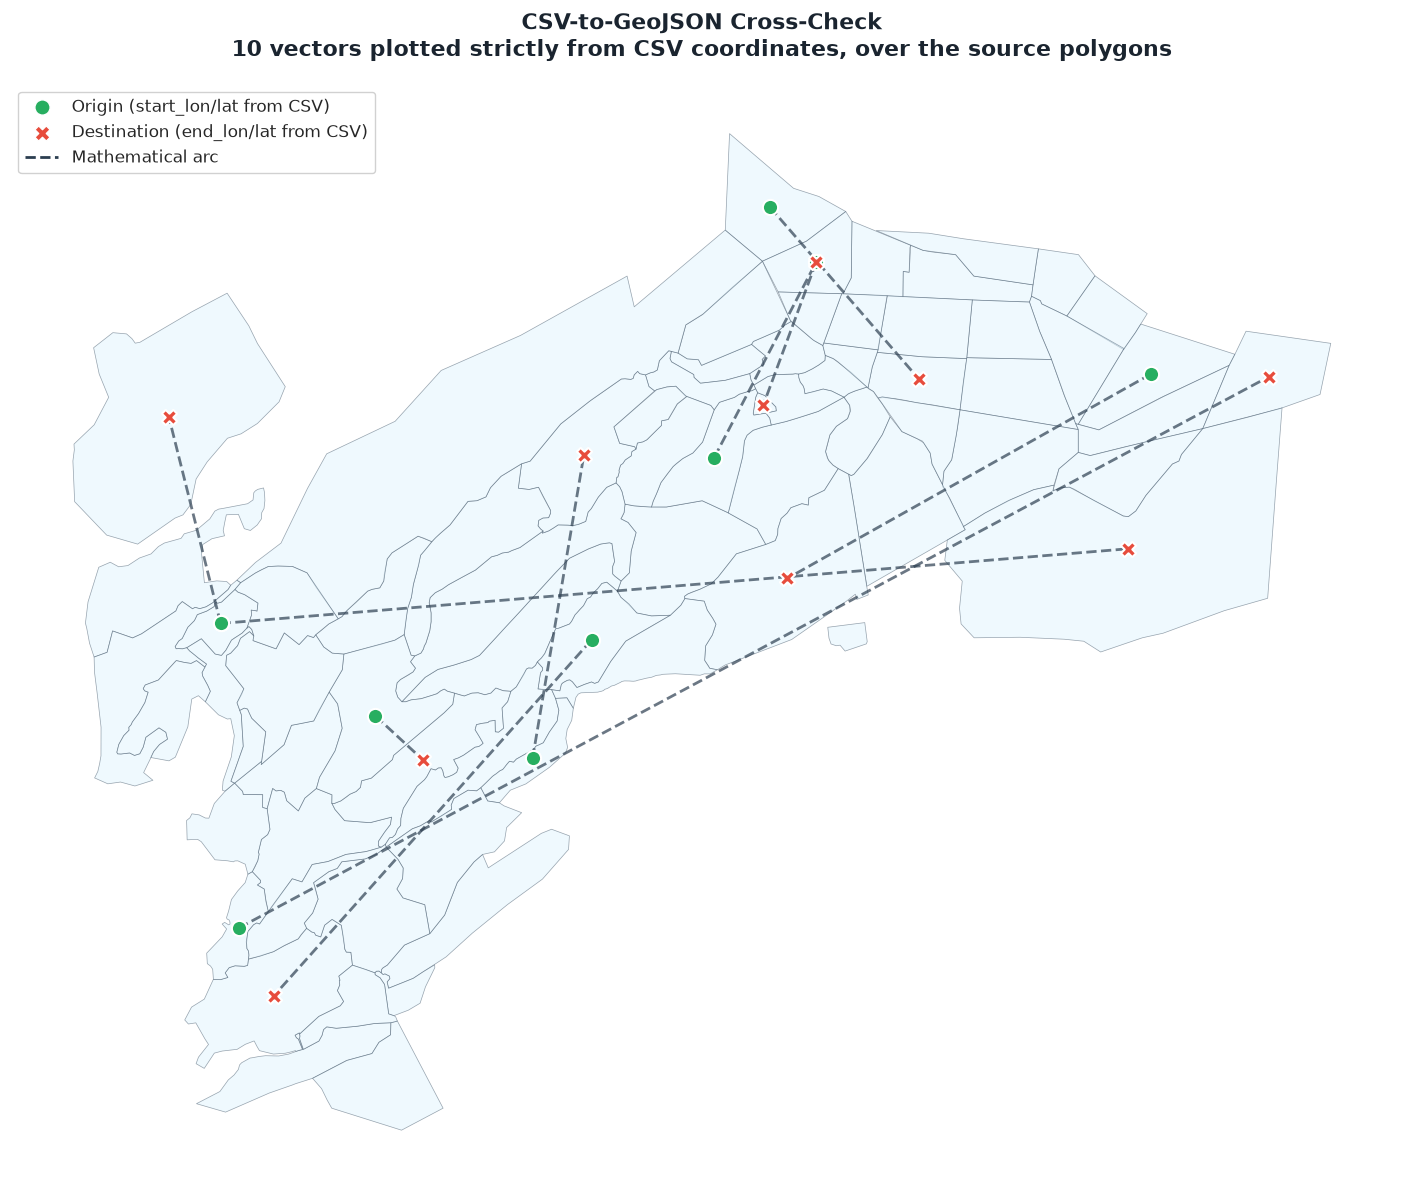

Check complete. Green circles and red X markers should sit inside their respective polygons.


In [41]:
print("Running a strict cross-check: CSV -> GeoJSON")

# 1. Load inputs (straight from disk, no shortcuts)
csv_path = os.path.join(DUMP_DIR, '0608_260512_tensor_arcos_mvp.csv')

df_csv = pd.read_csv(csv_path)
gdf_poly = gpd.read_file(GEOJSON_PATH)

# 2. Sample 10 random trips
df_sample = df_csv.sample(n=10, random_state=42).reset_index(drop=True)

# 3. Show the sample table
print("\nTABLE: 10 random trips (raw from the CSV):")
display(df_sample[['origen_id', 'destino_id', 'peso_maestro_eph', 'start_lon', 'start_lat', 'end_lon', 'end_lat']])

# 4. Plot the map
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_facecolor('#F8F9F9')

# A. Draw polygons (base layer from the original GeoJSON)
gdf_poly.plot(ax=ax, facecolor='#E1F5FE', edgecolor='#34495E', linewidth=0.5, alpha=0.5)

# B. Draw the 10 vectors using strictly the CSV's coordinates
for idx, row in df_sample.iterrows():
    slon, slat = row['start_lon'], row['start_lat']
    elon, elat = row['end_lon'], row['end_lat']

    ax.plot([slon, elon], [slat, elat], color='#2C3E50', linewidth=2, linestyle='--', alpha=0.7, zorder=2)
    ax.scatter(slon, slat, color='#27AE60', s=120, edgecolor='white', linewidth=1.5, zorder=3)
    ax.scatter(elon, elat, color='#E74C3C', s=120, edgecolor='white', linewidth=1.5, marker='X', zorder=3)

ax.scatter([], [], color='#27AE60', s=120, edgecolor='white', label='Origin (start_lon/lat from CSV)')
ax.scatter([], [], color='#E74C3C', s=120, edgecolor='white', marker='X', label='Destination (end_lon/lat from CSV)')
ax.plot([], [], color='#2C3E50', linewidth=2, linestyle='--', label='Mathematical arc')

plt.title("CSV-to-GeoJSON Cross-Check\n10 vectors plotted strictly from CSV coordinates, over the source polygons",
          fontsize=16, fontweight='black', pad=20, color='#1A242F')
plt.legend(loc='upper left', fontsize=12, framealpha=0.9)
plt.axis('off')
plt.tight_layout()
plt.show()

print("Check complete. Green circles and red X markers should sit inside their respective polygons.")

#### 6.4 — Enrich the CSV with edge centrality metrics

Adds `edge_betweenness`, `edge_closeness`, and `edge_pagerank` to the exported arcs CSV via a left merge, without altering the original rows.

In [42]:
print("Injecting edge-level centrality metrics into the CSV...")

# 1. Load the base CSV (untouched)
input_path = os.path.join(DUMP_DIR, "0608_260512_tensor_arcos_mvp.csv")
output_path = os.path.join(DUMP_DIR, "0608_260513_tensor_arcos_w_edge_centrality.csv")

df_base = pd.read_csv(input_path)
print(f"Base CSV loaded with {len(df_base)} arcs.")

# 2. Rebuild the graph from the tensor
vol_tensor = mobility_tensor[:, :, :, :, :, 0]
eph_tensor = mobility_tensor[:, :, :, :, :, 1]

num = np.sum(vol_tensor * eph_tensor, axis=(2, 3, 4))
den = np.sum(vol_tensor, axis=(2, 3, 4))
W_master = np.divide(num, den, out=np.zeros_like(num), where=den!=0)

G_functional = nx.from_numpy_array(W_master, create_using=nx.DiGraph)
mapping = {i: name for i, name in enumerate(ordered_zones)}
G_functional = nx.relabel_nodes(G_functional, mapping)

for u, v, data in G_functional.edges(data=True):
    data['distance'] = 1.0 / data['weight'] if data['weight'] > 0 else float('inf')

# 3. Build the line graph (dual of the network)
edge_graph = nx.line_graph(G_functional)

for edge_node in edge_graph.nodes():
    u, v = edge_node
    edge_graph.nodes[edge_node]['weight'] = G_functional[u][v]['weight']
    edge_graph.nodes[edge_node]['distance'] = G_functional[u][v]['distance']

print(f"Line graph built: {edge_graph.number_of_nodes()} operational routes analyzed.")

# 4. Compute the 3 master metrics
edge_betweenness = nx.edge_betweenness_centrality(G_functional, weight='distance', normalized=True)
edge_closeness = nx.closeness_centrality(edge_graph, distance='distance')
edge_pagerank = nx.pagerank(edge_graph, weight='weight', alpha=0.85)

df_metrics = pd.DataFrame([
    {
        'origen_id': u,
        'destino_id': v,
        'edge_betweenness': edge_betweenness.get((u, v), 0),
        'edge_closeness': edge_closeness.get((u, v), 0),
        'edge_pagerank': edge_pagerank.get((u, v), 0)
    }
    for u, v in G_functional.edges()
])

# Normalize for display (0-1 scale)
cols_norm = ['edge_betweenness', 'edge_closeness', 'edge_pagerank']
for col in cols_norm:
    if df_metrics[col].max() > 0:
        df_metrics[col] = df_metrics[col] / df_metrics[col].max()

# 5. Incremental merge (keeps the base file's row count exactly, just adds columns)
df_final = pd.merge(df_base, df_metrics, on=['origen_id', 'destino_id'], how='left')
df_final[cols_norm] = df_final[cols_norm].fillna(0)

# 6. Export the enriched CSV
df_final.to_csv(output_path, index=False)
print("\n" + "="*80)
print("New CSV version exported at:")
print(f"   -> {output_path}")
print("="*80)
print(f"Columns now available: {list(df_final.columns)}")

Injecting edge-level centrality metrics into the CSV...
Base CSV loaded with 2437 arcs.
Line graph built: 2437 operational routes analyzed.



New CSV version exported at:
   -> /workspaces/pienza/data/dumped_files/0608_260513_tensor_arcos_w_edge_centrality.csv
Columns now available: ['origen_id', 'destino_id', 'rank_ruta', 'volumen_historico', 'peso_maestro_eph', 'start_lon', 'start_lat', 'end_lon', 'end_lat', 'edge_betweenness', 'edge_closeness', 'edge_pagerank']


#### 6.5 — Enrich the CSV with economic mass and EPH master

Adds `masa_economica` (total economic mass) and `eph_maestro` (weighted-average EPH) per route to the CSV from 7.4, via another left merge.

In [43]:
print("Injecting economic variables (EPH and mass) into the CSV...")

# 1. Load the base CSV from the previous step (untouched)
input_path = os.path.join(DUMP_DIR, "0608_260513_tensor_arcos_w_edge_centrality.csv")
output_path = os.path.join(DUMP_DIR, "0608_260513_tensor_arcos_w_eph_maestro.csv")

df_base = pd.read_csv(input_path)
print(f"Base CSV loaded with {len(df_base)} arcs.")

# 2. Extract the economic physics from the tensor
vol_tensor = mobility_tensor[:, :, :, :, :, 0]
eph_tensor = mobility_tensor[:, :, :, :, :, 1]

# Economic mass (numerator) and total historical volume (denominator)
num = np.sum(vol_tensor * eph_tensor, axis=(2, 3, 4))
den = np.sum(vol_tensor, axis=(2, 3, 4))

# Weighted-average master EPH
W_master = np.divide(num, den, out=np.zeros_like(num), where=den!=0)

# 3. Package into an intermediate DataFrame
econ_data = []
for i, origin in enumerate(ordered_zones):
    for j, dest in enumerate(ordered_zones):
        mass_val = float(num[i, j])
        eph_val = float(W_master[i, j])

        # Only keep active routes to avoid inflating memory
        if mass_val > 0 or den[i, j] > 0:
            econ_data.append({
                'origen_id': origin,
                'destino_id': dest,
                'masa_economica': mass_val,
                'eph_maestro': eph_val
            })

df_econ = pd.DataFrame(econ_data)
print(f"Economic dictionary built with {len(df_econ)} active routes.")

# 4. Incremental merge (keeps the base file's structure exactly)
df_final = pd.merge(df_base, df_econ, on=['origen_id', 'destino_id'], how='left')

df_final['masa_economica'] = df_final['masa_economica'].fillna(0)
df_final['eph_maestro'] = df_final['eph_maestro'].fillna(0)

# 5. Export the master CSV
df_final.to_csv(output_path, index=False)
print("\n" + "="*80)
print("Enriched CSV version exported at:")
print(f"   -> {output_path}")
print("="*80)
print(f"Columns now available: {list(df_final.columns)}")

Injecting economic variables (EPH and mass) into the CSV...
Base CSV loaded with 2437 arcs.
Economic dictionary built with 2437 active routes.

Enriched CSV version exported at:
   -> /workspaces/pienza/data/dumped_files/0608_260513_tensor_arcos_w_eph_maestro.csv
Columns now available: ['origen_id', 'destino_id', 'rank_ruta', 'volumen_historico', 'peso_maestro_eph', 'start_lon', 'start_lat', 'end_lon', 'end_lat', 'edge_betweenness', 'edge_closeness', 'edge_pagerank', 'masa_economica', 'eph_maestro']


---

## Appendix — variable journey

<div align="center">
<img alt="flowchart" src="../assets/0608_Bridge_to_Markov_Network_Graph_B.png" width="1400">
</div>


<div style="border-left: 4px solid #D4AF37; padding: 4px 20px; background: rgba(212,175,55,0.06); border-radius: 0 6px 6px 0;">

## _Conclusion_

_Project Pienza formally ends here. A full-scale Markov Decision Process study with reinforcement learning (proper policy training, exploration/exploitation, convergence guarantees, etc.) is out of scope for this project and belongs to a potential Pienza 2.0. What's built here — the transition/reward matrices, Bellman value iteration, and the heuristic policy/fleet-deployment simulator — is intentionally left in place to trace the path forward if the project continues._

_Note on Deployment: The exports referenced at the end of this notebook power experimental dashboard views. These elements are currently in a staging phase and are not yet integrated into the live Streamlit Observatory. They will be pushed to the live production dashboard progressively as the UI is optimized._

---

_Thank you for reading this far — if you made it through the end of this notebook, I appreciate the time and attention. I am always open to discussing ML engineering, system architecture, or the nuances of this project. Feel free to reach out:_

- _LinkedIn: [linkedin.com/in/bernardolw](https://www.linkedin.com/in/bernardolw/)_
- _Email: bernardolw@gmail.com_

_Sull'ali dorate, pensiero._

</div>